# 024. テキスト埋め込みと retriever / Text Embedding and Retriever

## 1. 概要 / Overview

**テキスト埋め込み(text embedding)** は、文章を固定次元のベクトルに写し、ベクトルの近さで文章の意味的な近さを測る仕組みである。
query(検索の質問)と passage(検索される文章)を同じ空間に埋め込み、内積の大きい passage を順位づけして返す検索器を
**dense retriever** と呼ぶ。本トピックでは、008 の小型 GPT を encoder として、同じ記事から切り出した 2 つの区間を正例の組にする
教師なしの対照学習(Contriever の independent cropping に相当)で dense retriever を学習し、dual encoder 構造・プーリング・
InfoNCE・Matryoshka Representation Learning・BM25 をスクラッチ実装する。

検証するのは次の 5 つである(いずれも判定つき)。(A)因果マスクのもとで、終端位置のプーリングが平均プールより Recall@10 が高いか、
(B)平均プールで、注意マスクを双方向にすると因果マスクより Recall@10 が高いか、(C)008 の重みから始めると、ランダム初期化から
始めるより Recall@10 が高いか、(C′)(C)と同じ問いを、008 が事前学習で見ていない記事の query だけで調べたときにも成り立つか
(008 が見た記事の記憶による有利さを除くため)、(D)Matryoshka Representation Learning で学習すると、先頭 16 次元に切り詰めた埋め込みの
Recall@10 が、通常の InfoNCE で学習した埋め込みより高いか。あわせて、判定を設けない観察として、(E)BM25 との比較、(F)対照学習の前後での
異方性(anisotropy)・alignment・uniformity の変化を示す。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
**実行計画**(6.1 節。学習ステップ数 $T$・学習率の較正の方式・**削る段階** の組)のそれぞれについて残りの実行時間を見積もり、予算に収まる
計画のうち優先順位の最も高いものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。**選ばれた計画は 6.4 節の
出力に印字される。** 事前の計測のための実行やセッションの分割はしない。

**見積もりが最も下位の計画でも予算を超える場合は、学習の前に停止する。**

学習したモデルのうち、後続のトピック(025)の入力にする **Matryoshka Representation Learning で学習した条件(C5)のシード 0** だけを
Hugging Face Hub(`kojikojiprg/ai-theories-text-embedding-en`)にアップロードする(6.14 節。`UPLOAD_ARTIFACTS`が`True`のときだけ。
既定は`False`)。他のモデルは条件間の比較のためのものであり、保存もアップロードもしない。

### 1.2 本番実行の結果の要約

(本番実行の後に、第 3 段階で記述する。次の内容を書く。)

- 選ばれた実行計画($T$・較正の方式・段階)と、全体の実行時間、実行環境(5.1 節の出力を出典とする)
- 実験 A・B・C・C′・D の最終判定、対比量、閾値($2\sigma$)、前提条件の成否の表
- 観察(BM25 との比較、異方性・alignment・uniformity の前後)の要点
- 想定と異なる結果があれば、事前宣言した基準による結論と、事後的な解釈を分けて記す

## 2. 参考論文 / References

1. Karpukhin, V., Oğuz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen, D., Yih, W.,
   "Dense Passage Retrieval for Open-Domain Question Answering", EMNLP 2020. https://arxiv.org/abs/2004.04906
   (DPR(Dense Passage Retrieval)。dual encoder、in-batch negatives、BM25 による困難な負例。3.2・3.4・3.6 節)
2. Izacard, G., Caron, M., Hosseini, L., Riedel, S., Bojanowski, P., Joulin, A., Grave, E.,
   "Unsupervised Dense Information Retrieval with Contrastive Learning", TMLR 2022. https://arxiv.org/abs/2112.09118
   (Contriever。independent cropping による教師なしの対照学習。本トピックの学習データの作り方の原型。3.6 節)
3. Gao, T., Yao, X., Chen, D.,
   "SimCSE: Simple Contrastive Learning of Sentence Embeddings", EMNLP 2021. https://arxiv.org/abs/2104.08821
   (同じ文を dropout だけ変えて 2 回符号化したものを正例にする。温度 0.05。3.4・3.6 節)
4. Wang, L., Yang, N., Huang, X., Jiao, B., Yang, L., Jiang, D., Majumder, R., Wei, F.,
   "Text Embeddings by Weakly-Supervised Contrastive Pre-training", arXiv:2212.03533, 2022. https://arxiv.org/abs/2212.03533
   (E5。大規模な弱教師の文章の組での対照学習。3.6 節)
5. Wang, L., Yang, N., Huang, X., Yang, L., Majumder, R., Wei, F.,
   "Improving Text Embeddings with Large Language Models", ACL 2024. https://arxiv.org/abs/2401.00368
   (E5-mistral。decoder 型の大規模言語モデルを、終端のトークンの位置の出力で埋め込みモデルに転用する。3.3 節)
6. BehnamGhader, P., Adlakha, V., Mosbach, M., Bahdanau, D., Chapados, N., Reddy, S.,
   "LLM2Vec: Large Language Models Are Secretly Powerful Text Encoders", COLM 2024. https://arxiv.org/abs/2404.05961
   (decoder 型の言語モデルの注意を双方向にして埋め込みモデルに転用する。3.3 節、実験 B)
7. Muennighoff, N.,
   "SGPT: GPT Sentence Embeddings for Semantic Search", arXiv:2202.08904, 2022. https://arxiv.org/abs/2202.08904
   (GPT 型のモデルでの、位置に比例した重みの平均プール。3.3 節、位置づけのみ)
8. Neelakantan, A., Xu, T., Puri, R., Radford, A., et al.,
   "Text and Code Embeddings by Contrastive Pre-Training", arXiv:2201.10005, 2022. https://arxiv.org/abs/2201.10005
   (GPT 型のモデルの終端のトークンの位置の出力を埋め込みにする対照学習。3.3 節)
9. Kusupati, A., Bhatt, G., Rege, A., Wallingford, M., Sinha, A., Ramanujan, V., Howard-Snyder, W., Chen, K.,
   Kakade, S., Jain, P., Farhadi, A.,
   "Matryoshka Representation Learning", NeurIPS 2022. https://arxiv.org/abs/2205.13147
   (入れ子の次元の損失の和。3.7 節、実験 D)
10. Wang, T., Isola, P.,
    "Understanding Contrastive Representation Learning through Alignment and Uniformity on the Hypersphere", ICML 2020.
    https://arxiv.org/abs/2005.10242(alignment と uniformity。3.5 節、観察 F)
11. Ethayarajh, K.,
    "How Contextual are Contextualized Word Representations? Comparing the Geometry of BERT, ELMo, and GPT-2 Embeddings",
    EMNLP 2019. https://arxiv.org/abs/1909.00512(GPT-2 の表現の異方性。3.1 節、観察 F)
12. van den Oord, A., Li, Y., Vinyals, O.,
    "Representation Learning with Contrastive Predictive Coding", arXiv:1807.03748, 2018. https://arxiv.org/abs/1807.03748
    (InfoNCE 損失。020 の 3.4 節で導出済み)
13. Reimers, N., Gurevych, I.,
    "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks", EMNLP-IJCNLP 2019. https://arxiv.org/abs/1908.10084
    (言語モデルの出力の平均や [CLS] をそのまま文埋め込みにすると性能が低いという観察。3.1 節)
14. Robertson, S., Zaragoza, H.,
    "The Probabilistic Relevance Framework: BM25 and Beyond", Foundations and Trends in Information Retrieval 3(4), 2009.
    https://doi.org/10.1561/1500000019(BM25。3.8 節、観察 E)
15. Thakur, N., Reimers, N., Rücklé, A., Srivastava, A., Gurevych, I.,
    "BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models", NeurIPS 2021
    (Datasets and Benchmarks Track). https://arxiv.org/abs/2104.08663(語彙の一致に頼る検索と dense retriever の比較。3.8 節、位置づけのみ)
16. Khattab, O., Zaharia, M.,
    "ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT", SIGIR 2020.
    https://arxiv.org/abs/2004.12832(late interaction。3.2 節、位置づけのみ)
17. Nogueira, R., Cho, K.,
    "Passage Re-ranking with BERT", arXiv:1901.04085, 2019. https://arxiv.org/abs/1901.04085
    (cross-encoder による再順位づけ。3.2 節。実装は 025)

本文で用いる既存トピックの部品: 小型 GPT と bits-per-byte は [006](../02_pretraining/006_pretraining_small_gpt.ipynb)、AdamW・warmup + cosine・
gradient clipping は [007](../02_pretraining/007_training_stabilization.ipynb)、本トピックが起点にする学習済みの小型 GPT は
[008](../02_pretraining/008_decoding_strategies.ipynb)、FP16 の autocast と動的損失スケーリングは
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、記事を単位とするクラスタブートストラップは
[015](../03_efficient_training/015_long_context_extension.ipynb)、二重 encoder と InfoNCE 損失・InfoNCE が相互情報量の下界であること・温度は
[020](../05_vision_language/020_clip_contrastive_learning.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 検索を「同じ空間に埋め込んで内積で順位をつける」問題として定式化する

**検索(retrieval)の設定**: passage の集合 $\mathcal{C} = \{p_1, \dots, p_P\}$ と query $q$ が与えられ、$q$ に関連する passage を上位に並べて返す。
各 query について関連する passage の集合(正解)$G_q \subseteq \mathcal{C}$ が決まっているとし、上位 $k$ 件に正解が入っているかなどで評価する(3.9 節)。

**語彙の一致による検索**: BM25(3.8 節)は、query と passage が共有する語の重みつきの和でスコアをつける。passage ごとの転置索引から高速に
計算でき、強力な基準である一方、同じ意味を別の語で表した query と passage は一致しない(語彙の不一致、vocabulary mismatch)。

**dense retriever**: encoder $f_\theta$ が文章を $d$ 次元のベクトルに写し、query $q$ と passage $p$ の類似度を内積(またはコサイン類似度)で定義する。

$$
s(q, p) = f_\theta(q)^\top f_\theta(p), \qquad \lVert f_\theta(\cdot) \rVert_2 = 1
$$

($\lVert f_\theta(\cdot) \rVert_2 = 1$ は L2 正規化で、そのとき内積はコサイン類似度に一致する。)passage の埋め込みは事前に計算して索引にしておけるので、
query が来たときには query を 1 回符号化して全 passage との内積をとるだけでよい。本トピックは全 passage との内積を厳密に計算する(近似最近傍探索は 025)。

**言語モデルの隠れ状態をそのまま文埋め込みにしない理由**: 008 の小型 GPT の隠れ状態は、次のトークンの予測のために学習されたもので、
文章どうしの類似度を測る目的では学習されていない。次の 2 つの問題が文献で指摘されている。

1. **異方性(anisotropy)**: Ethayarajh [11] は、GPT-2 の文脈つきの表現が、層が深くなるほど狭い錐に偏り、最終層ではランダムな 2 つの
   単語の表現のコサイン類似度の平均が 1 に近いことを報告した。コサイン類似度の平均が大きいと、近さの差が小さな範囲に押し込められる。
   ただし、定数の偏りだけでは順位は変わらないので、異方性そのものが検索の失敗を意味するわけではない。
2. **目的の不一致**: Reimers & Gurevych [13] は、BERT の出力の平均や [CLS] をそのまま文埋め込みにすると、意味的な類似度の課題で GloVe の
   単語ベクトルの平均より低い性能になる場合があることを報告した。

本トピックでは、008 の重みのまま埋め込みとして使った場合の値(Recall@10・異方性・alignment・uniformity)を、対照学習の後と並べて測る(観察 F)。
008 の重みのままの値が低いかどうかは事前には断定せず、測った値を出力する。

### 3.2 dual encoder と cross-encoder

検索の類似度を計算する構造は、query と passage をどの段階で結合するかで 2 つに分かれる。

```mermaid
flowchart LR
    subgraph D["dual encoder(本トピック、DPR・Contriever)"]
        direction LR
        q1["query q"] --> e1["encoder f(重みは共有)"]
        p1["passage p"] --> e2["encoder f(同じ重み)"]
        e1 --> v1["u = f(q)"]
        e2 --> v2["v = f(p)"]
        v1 --> s1["内積 u・v"]
        v2 --> s1
    end
    subgraph X["cross-encoder(025)"]
        direction LR
        q2["query q"] --> c["q と p を連結して 1 本の入力にする"]
        p2["passage p"] --> c
        c --> e3["encoder g"]
        e3 --> s2["スコア g(q, p)"]
    end
```

| | dual encoder | cross-encoder |
|---|---|---|
| 結合の段階 | 出力のベクトルの内積(結合は最後) | 入力の連結(注意機構が query と passage の語どうしを直接参照) |
| passage の事前計算 | **できる**(索引にする) | できない(query ごとに組を符号化する) |
| 1 つの query の計算量 | encoder 1 回 + 内積 $P$ 回 | encoder $P$ 回(全 passage との組) |
| 精度 | 相互作用がないので低くなりうる | 相互作用があり高い |

dual encoder は上位の候補を絞り込むのに、cross-encoder(Nogueira & Cho [17])は絞り込んだ候補の再順位づけ(reranking)に向く。cross-encoder の
実装と、絞り込みと再順位づけの組み合わせは 025 で扱う。**late interaction**(ColBERT、Khattab & Zaharia [16])は、passage をトークンごとの
ベクトルの集合として事前に索引にし、query のトークンごとに最も近い passage のトークンとの内積(MaxSim)を足し合わせる中間の方式で、
位置づけのみとする(本トピックでは実装しない)。

dual encoder では、query と passage で **同じ重みの encoder** を使う(重みの共有。Contriever [2])場合と、別々の encoder を使う場合(DPR [1])がある。
本トピックは重みを共有する。

### 3.3 プーリング: 系列の隠れ状態から 1 本のベクトルを作る

encoder の最終正規化層の後の隠れ状態を $H = (h_0, \dots, h_{S-1}) \in \mathbb{R}^{S \times d}$ とする($S$ は系列長、$d = 256$ は隠れ次元)。
文埋め込みは、$H$ から 1 本のベクトル $z \in \mathbb{R}^d$ を作り(プーリング、pooling)、L2 正規化したもの $u = z / \lVert z \rVert_2$ である。
本トピックは射影層を置かず、次元は $d = 256$ のままとする。

| 方式 | $z$ | 備考 |
|---|---|---|
| 平均プール(mean pooling) | $\frac{1}{S} \sum_{t=0}^{S-1} h_t$ | E5 [4]・Contriever [2]・Sentence-BERT [13] |
| 終端位置(last-token pooling) | $h_{S-1}$ | E5-mistral [5]・cpt-text [8] |
| [CLS] | 先頭に置いた特別なトークンの出力 $h_0$ | encoder 型(双方向の注意)の BERT など |

**因果マスクのもとでの位置 $t$ の出力が見ているもの**: 008 の小型 GPT は因果マスク(causal mask)を使うので、位置 $t$ の隠れ状態 $h_t$ は
位置 $t$ までのトークン $x_0, \dots, x_t$ にだけ依存し、$t$ より後のトークンを見ていない(001)。したがって、

- 入力の **全体** を見ているのは、最後の位置の出力 $h_{S-1}$ だけである。
- 先頭の位置の出力 $h_0$ は、第 1 トークンだけに依存する。そのため、[CLS] のように先頭の位置を使う方式は、因果マスクのもとでは入力全体の要約にならない。
  encoder 型の [CLS] は、双方向の注意で全体を見られることを前提にした方式である。
- 平均プールは、前半の位置の出力(文脈が短い)と後半の位置の出力(文脈が長い)を等しい重みで平均する。SGPT [7] は、後ろの位置ほど多くの文脈を見ているので、
  位置 $t$ に比例した重み $w_t \propto t + 1$ の平均が良いことを報告した(位置づけのみ。本トピックでは実装しない)。

**decoder 型の言語モデルを埋め込みモデルに転用する流れ**: cpt-text [8] と E5-mistral [5] は、入力の末尾に終端のトークンを加え、その位置の出力を埋め込みにする。
因果マスクのもとで入力全体を見ている位置が末尾だけだからである。LLM2Vec [6] は、因果マスクを外して注意を **双方向** にし、さらに追加の学習(マスクされたトークンの
次トークン予測と、教師なしの対照学習)を行うことで、decoder 型の言語モデルを強い埋め込みモデルに転用した。双方向の注意は、事前学習で見ていない入力になる
(位置 $t$ の出力が、$t$ より後のトークンにも依存する)ので、追加の学習なしに注意を双方向にしたときの性能はモデルによって異なると報告されている [6]。

**008 のトークナイザには終端の特殊トークンがない**(語彙は 256 個のバイトと 7,936 個のマージで 8,192 個、特殊トークンなし。5.4 節で確かめる)。そのため終端位置のプーリングは、
**入力の最後の位置の出力** を使う。query と passage は固定長でパディングを使わないので、最後の位置は常に最後のトークンの位置である。

本トピックの実験 A・B は、この整理を検証する。(A)因果マスクのもとで、入力全体を見ている終端位置のプーリングが、平均プールより良いか。
(B)平均プールで、注意を双方向にして全位置が入力全体を見られるようにすると、因果マスクより良いか。

### 3.4 対照学習の損失: InfoNCE、in-batch negatives、温度

正例の組 $(q_i, p_i^+)$ が $N$ 組あるバッチを考える。$u_i = f_\theta(q_i)$、$v_j = f_\theta(p_j^+)$ を L2 正規化した埋め込み、
$s_{ij} = u_i^\top v_j$ をコサイン類似度、$\tau > 0$ を温度とする。**in-batch negatives**(バッチ内負例)は、i 番目の query にとって、同じバッチの
他の $N - 1$ 個の passage $p_j^+$($j \neq i$)を負例とする方法で、負例のための追加の符号化が要らない(DPR [1])。損失は

$$
\mathcal{L}_{\mathrm{NCE}} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(s_{ii} / \tau)}{\sum_{j=1}^{N} \exp(s_{ij} / \tau)}
$$

である($\mathcal{L}_{\mathrm{NCE}}$ の添字は InfoNCE の NCE。query から passage への方向。passage から query への方向も足して対称にする流儀(CLIP、020)もある)。この形は 020 の 3.3 節の対称な InfoNCE 損失の片方の
向きと同じで、InfoNCE が相互情報量の下界になること($I(X; Y) \ge \log N - \mathcal{L}_{\mathrm{NCE}}$)と、下界が $\log N$ で頭打ちになるので
負例の数 $N$ が効くことは、020 の 3.4 節で導出済みである(ここでは再導出しない)。

**温度 $\tau$**: $\tau$ が小さいほど softmax が鋭くなり、類似度の高い負例(困難な負例)の勾配への寄与が大きくなる。SimCSE [3] は $\tau = 0.05$、E5 [4] は $\tau = 0.01$ を使う。
020 では $\log(1/\tau)$ を学習したが、本トピックは $\tau = 0.05$ に **固定** する(条件間で揃える量)。

**バッチの作り方の注意(偽の負例)**: in-batch negatives は、同じバッチの他の組の passage を「負例」とみなす。同じ記事から切り出した別の組が同じバッチに入ると、
その passage は query にとって実際には関連があり(同じ記事の区間)、負例として押しのけると意味的に近いものを遠ざけてしまう(偽の負例、false negative)。
本トピックは **1 つのバッチに同じ記事の組を 2 つ以上入れない**(5.4 節で確かめる)。

### 3.5 alignment と uniformity、異方性

Wang & Isola [10] は、単位球面上の埋め込みを学ぶ対照学習の損失が、次の 2 つの性質を同時に最適化することを示した。

$$
\mathcal{L}_{\mathrm{align}} = \mathbb{E}_{(x, y) \sim p_{\mathrm{pos}}} \left[ \lVert f(x) - f(y) \rVert_2^{\alpha} \right], \qquad
\mathcal{L}_{\mathrm{uniform}} = \log \mathbb{E}_{x, y \sim p_{\mathrm{data}}} \left[ e^{-t \lVert f(x) - f(y) \rVert_2^{2}} \right]
$$

- $p_{\mathrm{pos}}$: 正例の組の分布、$p_{\mathrm{data}}$: データの分布(独立に 2 つ引く)。$\alpha = 2$、$t = 2$ が原論文の既定値である。
- **alignment**: 正例の組の埋め込みの距離。小さいほど正例が近い。
- **uniformity**: 埋め込みが単位球面にどれだけ一様に広がっているか。小さい(より負の)ほど一様で、全部が 1 点に潰れると 0 になる。

異方性の指標は、ランダムな 2 つの埋め込みのコサイン類似度の平均 $\mathbb{E}_{x \neq y}[f(x)^\top f(y)]$ である [11]。1 に近いほど、埋め込みが狭い錐に偏っている。
uniformity と同様に、偏りの度合いを測るが、uniformity は距離の分布全体に、異方性は平均に注目する。
5.2 節以降で、対照学習の前後でこれらを測る(観察 F)。

### 3.6 正例の作り方の系譜

対照学習の正例の組をどう作るかが、手法の違いの中心である。

```mermaid
flowchart TD
    A["正例の組の作り方"] --> B["同じ入力の変換"]
    A --> C["同じ文書の別の区間"]
    A --> D["人手のラベル"]
    A --> E["弱教師(自然に対応づく文章の組)"]
    B --> B1["SimCSE: 同じ文を dropout だけ変えて 2 回符号化"]
    C --> C1["Contriever: independent cropping(同じ文書から 2 つの区間、重なりを許す)"]
    C1 --> C2["本トピック: 同じ記事から重ならない 2 つの区間"]
    D --> D1["DPR: 質問と答えを含む passage + BM25 による困難な負例"]
    E --> E1["E5: 大規模な弱教師の組で事前学習し、ラベルつきデータで微調整"]
```

- **SimCSE** [3]: 同じ文を、dropout の乱数だけ変えて 2 回 encoder に通し、2 つの出力を正例にする。データの拡張が要らず、教師なし。
- **Contriever** [2]: 同じ文書から 2 つの区間を独立に切り出して正例にする(independent cropping)。2 つの区間は **重なってもよい**。重なると語の一致だけで正例を当てられるので、
  語彙の一致に頼らない表現を学ぶ目的には不利になりうる。本トピックは **重ならないように** 切り出す(`src/data/retrieval.py`の`sample_pair_schedule()`)。
- **DPR** [1]: 質問と、答えを含む passage のラベルつきの組を使う。**困難な負例(hard negative)** として、BM25 で上位に来たが答えを含まない passage を各質問に 1 個加える。
  in-batch negatives が「簡単な負例」(無関係な passage)であるのに対し、BM25 の上位は語彙が似ているので、区別が難しい。
- **E5** [4]: ウェブから集めた、自然に対応する文章の組(質問と回答、見出しと本文など)で事前学習し、ラベルつきのデータで微調整する。

**偽の負例(false negative)**: 困難な負例は、語彙や意味が正例に近い passage を負例として使うので、実際には正解である passage を負例にしてしまう危険が大きくなる。
**困難な負例は本トピックでは理論のみとし、実験には使わない。** 本トピックの負例は in-batch negatives だけで、バッチ内に同じ記事の組を入れないことで偽の負例を避ける。

### 3.7 Matryoshka Representation Learning

通常の埋め込みは $d$ 次元すべてを使って初めて意味を持つ。次元を減らして索引のメモリや内積の計算量を減らしたいときは、あとから主成分分析で圧縮するなどが必要になる。
Matryoshka Representation Learning(Kusupati et al. [9])は、**先頭の $m$ 次元だけを取り出しても使える** ように、入れ子の次元の集合
$\mathcal{M} = \{m_1 < m_2 < \dots < m_K = d\}$ のそれぞれについて損失を計算して足し合わせる。

$$
\mathcal{L}_{\mathrm{Matryoshka}} = \sum_{m \in \mathcal{M}} c_m \, \mathcal{L}_{\mathrm{NCE}}^{(m)}
$$

$\mathcal{L}_{\mathrm{NCE}}^{(m)}$ は、プーリングで得た正規化前のベクトル $z$ の **先頭 $m$ 次元を取り出して、L2 正規化し直した** 埋め込み
$u^{(m)} = z_{1:m} / \lVert z_{1:m} \rVert_2$ で計算した 3.4 節の InfoNCE 損失、$c_m \ge 0$ は次元ごとの重みである。

**切り詰めた後の再正規化**: 切り詰めたベクトルのノルムは 1 より小さくなるので、そのままでは内積がコサイン類似度にならない。切り詰めた後に L2 正規化し直す。
$m = d$ のときは通常の埋め込みと一致する。

**重み $c_m$**: 原論文は $c_m = 1$ を使う。本トピックは $c_m = 1 / \lvert \mathcal{M} \rvert$(平均)にする。全体が $\lvert \mathcal{M} \rvert$ 倍になるだけで最適解は変わらず、
AdamW の更新は損失の尺度に依らない。違いが出るのは gradient clipping が発動しないステップの勾配のノルムだけで、平均にすると通常の InfoNCE と尺度が揃う。

**原論文との違い**: 原論文は ImageNet の分類で、各次元の先頭 $m$ 個を入力とする線形分類器を持つ。検索への適用では、各次元の埋め込みの InfoNCE 損失を足し合わせる形が使われる。
本トピックはこの形(各 $m$ について再正規化した埋め込みの InfoNCE)を使う。入れ子の次元は等比の $\mathcal{M} = \{16, 32, 64, 128, 256\}$ とする。

**索引のメモリとの関係**: $P$ 個の passage を FP32 の $m$ 次元の埋め込みで持つ索引のメモリは $4 P m$ バイトで、$m$ に比例する。$m = 256 \to 16$ で 16 分の 1 になる。
この利得を実際の索引で扱うのは 025 である。

### 3.8 BM25 と、語彙の一致に頼る検索

BM25(Robertson & Zaragoza [14])は、query $q$ の語 $t$ の集合について、passage $D$ のスコアを次の和で与える。

$$
\mathrm{BM25}(D, q) = \sum_{t \in q} \mathrm{IDF}(t) \cdot \frac{f(t, D) \, (k_1 + 1)}{f(t, D) + k_1 \left( 1 - b + b \, \dfrac{\lvert D \rvert}{\mathrm{avgdl}} \right)}, \qquad
\mathrm{IDF}(t) = \ln \left( 1 + \frac{P - n(t) + 0.5}{n(t) + 0.5} \right)
$$

- $f(t, D)$: 語 $t$ の passage $D$ での出現回数。$\lvert D \rvert$: passage の長さ(トークン数)。$\mathrm{avgdl}$: 全 passage の平均の長さ。
- $P$: passage の数。$n(t)$: 語 $t$ を含む passage の数。$\mathrm{IDF}(t)$: 逆文書頻度(inverse document frequency)で、多くの passage に現れる語ほど小さい。
  上の式は Lucene と同じ、常に正になる形である。
- $k_1$: 語の出現回数の飽和の強さ(既定値 1.2)。$b$: passage の長さの正規化の強さ(既定値 0.75)。query の語は重複を除いた集合として足す。

本トピックの BM25 は **BPE(Byte Pair Encoding)のトークン ID の列** を入力にする(`src/retrieval/bm25.py`)。passage が固定長なので $\lvert D \rvert = \mathrm{avgdl}$ で、長さの正規化の項は定数 1 になり、$b$ は結果に影響しない。

**語彙の一致に頼る検索と dense retriever の得意・不得意**(BEIR、Thakur et al. [15] の知見の紹介のみ。本トピックでは検証しない): 18 のデータセットでの
ゼロショットの評価で、BM25 は頑健な基準で、特定のデータセットで学習した dense retriever は、学習した領域と異なる領域の多くで BM25 を下回った。語の一致が強い手がかりになる
課題(固有名詞、専門用語)では BM25 が強く、語が違っても意味が近い query と passage の対応(言い換え)では dense retriever が強い。両者は補い合うので、組み合わせて使われる。
本トピックの観察 E は、同じ索引と query で BM25 と各条件の値を並べるだけで、優劣は判定しない。

### 3.9 評価指標: Recall@k、MRR、nDCG

query $i$ について、正解の集合を $G_i$(同じ記事の他の passage)、候補を類似度の降順に並べたときの最も上位の正解の順位を $r_i$ とする。
**query を含む passage は候補から除く。**

- **Recall@k**: 上位 $k$ 件に正解が 1 つ以上あれば 1、なければ 0 を、query について平均した値。

$$
\mathrm{Recall@}k = \frac{1}{Q} \sum_{i=1}^{Q} \mathbb{1}[r_i \le k]
$$

- **MRR**(Mean Reciprocal Rank): 最も上位の正解の順位の逆数の平均。

$$
\mathrm{MRR} = \frac{1}{Q} \sum_{i=1}^{Q} \frac{1}{r_i}
$$

- **nDCG@k**(normalized Discounted Cumulative Gain): 順位 $j$ の候補が正解かどうかを $\mathrm{rel}_j \in \{0, 1\}$ として

$$
\mathrm{DCG@}k = \sum_{j=1}^{k} \frac{\mathrm{rel}_j}{\log_2 (j + 1)}, \qquad
\mathrm{nDCG@}k = \frac{\mathrm{DCG@}k}{\mathrm{IDCG@}k}, \qquad
\mathrm{IDCG@}k = \sum_{j=1}^{\min(\lvert G_i \rvert, k)} \frac{1}{\log_2 (j + 1)}
$$

($Q$ は query の数。$\mathrm{IDCG@}k$ は正解が上位から並んだ理想の順序での $\mathrm{DCG@}k$。)

本トピックの主指標は Recall@10 で、MRR と nDCG@10 を診断量として印字する。Recall@k は上位 $k$ 件の中の順序を見ず、MRR は最上位の正解だけを見る。
同点は、最も上位の正解と同じ以上のスコアを持つ正解でない候補の数に 1 を加えた値を順位とする(正解に不利な向き)。

**ランダムな順位の期待値**: 候補が $M$ 個で正解が $g$ 個のとき、ランダムに並べて上位 $k$ 件に正解が 1 つもない確率は $\binom{M - g}{k} / \binom{M}{k}$ なので、
Recall@k の期待値は $1 - \binom{M - g}{k} / \binom{M}{k}$ である(query について平均する)。前提条件(6.1 節)で使う。

### 3.10 データの流れとアルゴリズム(擬似コード)

```
学習:
  入力: 学習用の記事、query の長さ L_q、passage の長さ L_p、バッチサイズ N、温度 tau、学習ステップ数 T
  前処理(学習の前に全ステップぶんを作る):
    各ステップで N 個の記事を、重みに比例する確率で非復元抽出する         # 1 つのバッチに同じ記事の組は 2 つ入らない
    各記事から、重ならない長さ L_q と長さ L_p の区間を切り出す(query 側と passage 側)
  各ステップ:
    z_q = pool(encoder(query))、z_p = pool(encoder(passage))              # 同じ重みの encoder。pool は平均または終端位置
    通常の InfoNCE:   u = normalize(z_q)、v = normalize(z_p)、 L = InfoNCE(u, v, tau)
    Matryoshka Representation Learning:  L = sum_m c_m InfoNCE(normalize(z_q[:m]), normalize(z_p[:m]), tau)
    勾配 -> gradient clipping -> AdamW の更新(学習率は warmup + cosine)

評価:
  索引: 評価用の記事を重ならない長さ L_p の passage に分け、埋め込みにする(記事ごとに passage 数の上限あり)
  query: 索引の passage の一部(長さ L_q)。その query を含む passage は、その query の候補から除く
  全件の内積で順位をつけ、Recall@10 (主指標)・MRR・nDCG@10 を求める
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/models/text_embedding.py`: 小型 GPT を包む埋め込みモデル`TextEmbeddingModel`(プーリング(平均・終端位置)、注意マスクの切り替え(因果・双方向)、
  L2 正規化)。最終正規化層の後の隠れ状態`compute_hidden_states()`、次元の切り詰めと再正規化`truncate_and_normalize()`、固定長のトークン列を FP32 で符号化する
  `encode_tokens()`(切り詰める次元の一覧と、指定した位置の出力の埋め込みも一度に返す)。既存の`GPTLanguageModel`は変更しない。
- `src/data/retrieval.py`: 記事を単位とする学習用・検証用・評価用の分割`split_articles()`(決定的)、記事ごとの符号化、評価用の索引と query の構成
  `build_retrieval_set()`(記事ごとの passage 数の上限つき、決定的)、学習の組の切り出し`sample_pair_schedule()`(重ならない 2 つの区間、1 つのバッチに同じ記事を入れない)。
  025 から同じ評価用の passage の集合を再構成できる。
- `src/training/contrastive_text.py`: in-batch negatives の InfoNCE`info_nce_loss()`、Matryoshka Representation Learning の損失`matryoshka_representation_loss()`、
  学習ループ`train_text_embedding()`。020 の`src/training/contrastive.py`の`softmax_contrastive_loss()`は参照実装として単体テストで使い(温度を固定した対称な損失と一致する)、
  学習の部品(007 の`AdamW`・warmup + cosine・gradient clipping、011 の`DynamicLossScaler`、019 の`split_weight_decay_parameters()`・
  `unscale_gradients_and_compute_norm()`)は再利用する。
- `src/retrieval/bm25.py`: BM25 のスクラッチ実装`BM25Index`(転置索引、トークン ID の列を入力とする)。
- `src/retrieval/evaluation.py`: 全件の内積による厳密な探索での Recall@k・MRR・nDCG@10`rank_candidates()`・`evaluate_embeddings()`、ランダムな順位の期待値
  `expected_random_recall()`、異方性`mean_pairwise_cosine()`・`alignment()`・`uniformity()`。近似最近傍探索は使わない。

**既存モジュールの扱い**: 既存のファイルは変更していない(新しいファイルの追加のみ)。したがって既存の挙動が変わらないことは、変更前のコミットとの差分が空であることで確かめる
(5.5 節)。因果マスクを外す経路は、`GPTLanguageModel.forward()`を変更せず、`TextEmbeddingModel`が各層の`DecoderBlock`を直接呼んで実現する
(`attention="causal"`のとき`src/models/reward_model.py`の`compute_final_hidden_states()`と bit 単位で一致する)。

**ノートブック内に直接書く(024 固有)**: 条件の定義、データの分割の確認、単体テストと不変条件の確認、学習率の較正、実行計画の選択、判定、可視化、スケーリングの計測、Hub へのアップロード。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| コーパス(Hub から取得できなかった場合の Wikipedia API からの取得結果) | `.cache/wikipedia_en/`(データ源で命名。決定的に再取得できる) |
| Hugging Face Hub から取得したコーパス・トークナイザ・008 の学習済みモデル | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 符号化したトークン列・評価用の索引と query | メモリ上のみ(符号化は全体で数秒なので、`.cache/`にも置かない) |
| 学習したモデル(C5 のシード 0 を除く) | メモリ上のみ(評価の直後に破棄する) |
| C5 のシード 0 の学習後の重み | メモリ上に保持し、6.14 節でアップロードの対象にする(`.cache/`には置かない) |
| 学習の履歴・query ごとの順位 | メモリ上のみ(判定と図に使う) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.7〜6.10・6.13 節) |
| アップロードしたモデル | Hugging Face Hub の`kojikojiprg/ai-theories-text-embedding-en`(新規、public。`UPLOAD_ARTIFACTS`が`True`のときのみ) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| コーパス(`corpus.txt`・`metadata.json`) | `kojikojiprg/ai-theories-corpus-en-pretraining`(Dataset、356 記事) | 学習・評価の英語 Wikipedia のコーパスと、記事の境界(`article_offsets`) |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 008 の英語の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192) |
| 008 の学習済みモデル(`config.json`・`model_state.pt`、`main`) | `kojikojiprg/ai-theories-small-gpt-en` | 条件 C1・C2・C3・C5 の初期値 |

**コーパスについて**: `kojikojiprg/ai-theories-corpus-en`(9,826 記事)の`metadata.json`には記事の境界`article_offsets`がない。本トピックは、記事を単位として分割するために
記事の境界が必要なので、`article_offsets`を持つ`kojikojiprg/ai-theories-corpus-en-pretraining`(356 記事、008 の事前学習と同じ記事集合)を使う。

**アップロード方針**: アップロードするのは C5(Matryoshka Representation Learning)のシード 0 のモデルだけで、結果を見て選ばない(後続の 025 の入力になるため)。
トークナイザは同梱せず、モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照する。モデルカードの指標は、アップロードする重みそのものを読み込み直して評価した値とする。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**本番のコミットの確認**: `SMOKE_TEST = False`のときだけ、(1)追跡しているファイルに未コミットの変更がないこと、(2)`REQUIRED_ANCESTOR_COMMIT`が指定されていれば、
それが HEAD の祖先であることを確かめ、満たさなければ学習の前に停止する。追跡外のファイルは停止の条件にせず、あれば一覧を参考として印字する。

**精度と決定性**: 学習は、CUDA のときは FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行い、それ以外のデバイス(ローカルの MPS(Metal Performance Shaders、Apple Silicon の GPU 用のバックエンド)・CPU)では FP32 で行う。
埋め込みの正規化・類似度・損失・評価は常に FP32 で行う。`torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても結果が bit 単位では
一致しないことがあるが、条件間の対応付け(同じシードの条件どうしで学習の組と順序を揃えること)は乱数の生成器によって決まり、演算の決定性には依存しない(5.5・6.12 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
USE_FP16_AUTOCAST = device.type == "cuda"  # FP16 の autocast と動的損失スケーリングは CUDA のときのみ
execution_environment = print_execution_environment(device)

# 本番(SMOKE_TEST = False)は、追跡しているファイルに未コミットの変更がない状態で実行する。第 1 段階の完了の後に修正を行った場合は、
# その修正を含むコミットを REQUIRED_ANCESTOR_COMMIT に指定する(HEAD がその子孫であることを確かめる)
REQUIRED_ANCESTOR_COMMIT = None
if not SMOKE_TEST:
    import subprocess

    _head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True).stdout.strip()
    _status = subprocess.run(
        ["git", "status", "--porcelain", "--untracked-files=no"], capture_output=True, text=True, check=True
    ).stdout.strip()
    _untracked = subprocess.run(
        ["git", "ls-files", "--others", "--exclude-standard"], capture_output=True, text=True, check=True
    ).stdout.split()
    _is_descendant = REQUIRED_ANCESTOR_COMMIT is None or (
        subprocess.run(["git", "merge-base", "--is-ancestor", REQUIRED_ANCESTOR_COMMIT, "HEAD"]).returncode == 0
    )
    if not _is_descendant or _status:
        raise RuntimeError(
            f"本番の実行条件を満たさないため、学習の前に停止する(結果の情報は何も得ていない)。HEAD {_head[:7]}、"
            f"{REQUIRED_ANCESTOR_COMMIT} の子孫か: {_is_descendant}、追跡しているファイルの未コミットの変更: {_status or 'なし'}。"
            "リポジトリを最新の main に更新し、変更をなくして再実行すること。"
        )
    print(
        f"本番の実行条件: HEAD {_head[:7]}、追跡しているファイルに未コミットの変更がない"
        f"、必要な祖先のコミット {REQUIRED_ANCESTOR_COMMIT}: OK(参考: 追跡外のファイル {_untracked or 'なし'})"
    )
print(
    f"SMOKE_TEST={SMOKE_TEST}、学習の精度 {'FP16 の autocast + 動的損失スケーリング' if USE_FP16_AUTOCAST else 'FP32'}"
    f"(埋め込みの正規化・損失・評価は FP32)、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 4c9eb4039cc44070e356c2a2bd24d43daa7e8821
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-10-05T22:43:13+00:00
SMOKE_TEST=True、学習の精度 FP32(埋め込みの正規化・損失・評価は FP32)、決定的な演算の強制: False


In [2]:
import functools
import hashlib
import itertools
import json
import math
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.data.retrieval import (
    build_retrieval_set,
    compute_article_sampling_weights,
    concatenate_articles,
    encode_articles,
    find_articles_starting_at_or_after,
    sample_pair_schedule,
    select_evenly,
    split_articles,
)
from src.data.text import (
    load_wikipedia_corpus_with_fallback,
    locate_wikipedia_article_spans,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.models.reward_model import compute_final_hidden_states
from src.models.text_embedding import (
    TextEmbeddingModel,
    compute_hidden_states,
    encode_tokens,
    truncate_and_normalize,
)
from src.retrieval.bm25 import BM25Index
from src.retrieval.evaluation import (
    alignment,
    evaluate_embeddings,
    expected_random_recall,
    mean_pairwise_cosine,
    rank_candidates,
    uniformity,
)
from src.training.contrastive import softmax_contrastive_loss
from src.training.contrastive_text import (
    info_nce_loss,
    matryoshka_representation_loss,
    train_text_embedding,
)
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import fit_power_law_exponent, paired_cluster_bootstrap_ratio_of_sums

ROOT = Path.cwd()
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # 外部から取得したコーパス(データ源で命名)
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
REFERENCE_MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"  # 008 の学習済みモデル(条件 C1・C2・C3・C5 の初期値)
UPLOAD_REPO_ID = "kojikojiprg/ai-theories-text-embedding-en"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
RUN_TAG = "[スモークテスト] " if SMOKE_TEST else ""
PLOT_TAG = "[smoke test] " if SMOKE_TEST else ""


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(function) -> float:
    sync_device()
    start = time.time()
    function()
    sync_device()
    return time.time() - start


def rounded(values, digits: int = 4):
    # 印字用: 入れ子のリスト・配列を丸めたリストにする
    return np.round(np.asarray(values, dtype=np.float64), digits).tolist()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**: スモークテストは、本番と **同じモデル・同じデータ・同じ条件・同じ実行計画の構造** で、次の量だけを縮小する。

- **学習ステップ数 $T$ の候補**: 本番 $(1024, 512, 256)$、スモークテスト $(16, 8, 4)$。どちらも大きい順で、隣どうしの比が 2 の等比という構造を保つ。
- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(削った段階で 2)。「削る前 > 削った後 $\ge 2$」の順序関係を保つ。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

評価用の索引・query・検証用の集合は縮小しない(評価は数秒で終わるため、本番と同じ集合でコードの経路を確かめる)。スモークテストはステップ数が極端に少ないので、
学習は進まず、前提条件は成立しない見込みである(コードの経路の確認が目的)。**較正・前提条件・検出力の確認は、6.2 節のパイロットで本番と同じステップ数で行った。**

**縮小しないもの**: モデルの構成、データの分割、バッチサイズ、query と passage の長さ、条件の対応表、学習率の較正の格子と拡張の規則、学習率のスケジュールの形、
途中の評価の位置の決め方($T$ に対する割合)、実行計画の表の構造と優先順位、前提条件と判定の閾値、スケーリングの計測点。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりにその計画を使う(スモークテストで下位の計画の経路を
確かめるため)。本番では受け付けず、このセルで停止する。コミットする出力は上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(ステップ数・シード数・計画の表)が、実際の学習で使われた値と一致することを 6.12 節のアサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# モデル(008 と同じ小型 GPT。構成は Hub の config.json から読む)
EMBEDDING_DIMENSION = 256
MATRYOSHKA_DIMENSIONS = (16, 32, 64, 128, 256)  # 入れ子の次元の集合 M(等比、公比 2)
# データ(5.3 節)
QUERY_LENGTH, PASSAGE_LENGTH = 32, 128  # L_q、L_p(固定長、パディングなし)
MAX_PASSAGES_PER_ARTICLE = 12  # 記事ごとの索引の passage 数の上限(学習で記事を選ぶ重みにも同じ上限を使う)
MAX_QUERIES_PER_ARTICLE = 12
NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES, NUM_TRAIN_PROBE_ARTICLES = 64, 120, 120
SPLIT_SEED, EVALUATION_SET_SEED, VALIDATION_SET_SEED, TRAIN_PROBE_SEED = 24_001, 24_002, 24_003, 24_004
REFERENCE_VALIDATION_RATIO = 0.05  # 008 の事前学習はコーパスの末尾 5% を使っていない
EVAL_ENCODE_BATCH = 256  # 評価の 1 回の順伝播の系列の数(結果には影響しない)
# 学習(008 のレシピに準じる)
BATCH_SIZE = 64  # N
TEMPERATURE = 0.05  # tau(固定)
WEIGHT_DECAY = 0.1
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
INIT_LOSS_SCALE = 2.0**16  # 動的損失スケーリング(019〜022 と同じ)
LOSS_SCALE_GROWTH_INTERVAL = 2000
# 条件の対応表(6.1 節)
CONDITIONS = {
    "C1": {"init": "pretrained", "attention": "causal", "pooling": "last", "loss": "infonce", "track": False},
    "C2": {"init": "pretrained", "attention": "causal", "pooling": "mean", "loss": "infonce", "track": True},
    "C3": {"init": "pretrained", "attention": "bidirectional", "pooling": "mean", "loss": "infonce", "track": True},
    "C4": {"init": "random", "attention": "causal", "pooling": "mean", "loss": "infonce", "track": True},
    "C5": {"init": "pretrained", "attention": "causal", "pooling": "mean", "loss": "matryoshka", "track": False},
}
RUN_ORDER = ("C2", "C1", "C3", "C5", "C4")  # 本番の学習の順
# 学習率の較正(6.1 節)。中心は 6.2 節のパイロットで決めた
LEARNING_RATE_CENTER = {"C1": 1e-4, "C2": 1e-4, "C3": 1e-4, "C4": 1e-3, "C5": 1e-4}
LEARNING_RATE_GRID_MULTIPLIERS = (0.25, 1.0, 4.0)  # 格子 = 中心 x {1/4, 1, 4}(公比 4。6.1 節)
LEARNING_RATE_GRID_RATIO = 4.0
REPRESENTATIVE_CALIBRATED = ("C2", "C4")  # 較正の方式 "representative" で較正する条件
REPRESENTATIVE_RULE = {"C1": "C2", "C3": "C2", "C5": "C2"}  # 規則で決める条件 -> 値を借りる条件
# 途中の評価の位置(T に対する割合、初期に密な等比の間隔)。検証用の集合の Recall@10 を測る(C2・C3・C4 のみ)
EVAL_FRACTIONS = (1 / 64, 1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
# 位置ごとの診断量(実験 A): 系列の長さに対する割合。位置 = ceil(割合 x 長さ) - 1
POSITION_FRACTIONS = (1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
# 前提条件と判定(6.1 節)
P1_LOSS_DECREASE_RATIO = 0.8  # P1: 008 の重みから始める条件の最後の区間の訓練損失 <= 最初の区間の訓練損失 x この値
FINAL_LOSS_FRACTION = 0.05  # 「最初の区間」「最後の区間」= 最初・最後の 5% のステップ
P1_RECALL_MARGIN = 0.3  # P1: C2 の Recall@10 >= ランダムな順位の期待値 + この値
P2_RECALL_CEILING = 0.95  # P2(改善の余地): 基準となる条件の Recall@10 <= この値
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
# 乱数シード(学習のシード s: 学習の組 24100 + s、ランダム初期化 24200 + s)
PAIR_SEED_BASE, INIT_SEED_BASE = 24_100, 24_200
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
BOOTSTRAP_SEED = 24_600
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
OBSERVATION_RUN = ("C2", 0)  # 観察 F の「後」に使う学習(C2、シード 0)
UPLOAD_RUN = ("C5", 0)  # Hub にアップロードする学習(結果を見て選ばない)
UPLOAD_ARTIFACTS = False  # 6.14 節。既定は False(Colab Secrets の HF_TOKEN を使ってアップロードするときだけ True)

# --- 水準(SMOKE_TEST で変わるもの) ---
LEVELS = {
    "smoke": {"STEP_CANDIDATES": (16, 8, 4), "BOOTSTRAP_RESAMPLES": 1_000},
    "prod": {"STEP_CANDIDATES": (1024, 512, 256), "BOOTSTRAP_RESAMPLES": 10_000},
}
# 削る段階(6.1 節)。順序: 較正の方式 -> C5 のシード数 -> C4 のシード数(T を下げるのは最後)
STAGES = {
    "prod": {
        0: {"mode": "all", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 5}},
        1: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 5}},
        2: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 3}},
        3: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 3, "C5": 3}},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"mode": "all", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 3}},
        1: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 3}},
        2: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 2}},
        3: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 2, "C5": 2}},
    },
}
NUM_STAGES = 4
# スケーリングの計測点(6.3 節)。水準によらず同じ
SCALING_STEP_COUNTS = (8, 16, 32)
SCALING_WARMUP_STEPS = 8
SCALING_ENCODE_CHARACTERS = (1_000_000, 2_000_000, 4_000_000)

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
LEVEL_SETTINGS = LEVELS[CURRENT_LEVEL_NAME]
STEP_CANDIDATES = LEVEL_SETTINGS["STEP_CANDIDATES"]
BOOTSTRAP_RESAMPLES = LEVEL_SETTINGS["BOOTSTRAP_RESAMPLES"]


def build_plans(step_candidates) -> list[dict]:
    # 実行計画(6.1 節): 学習ステップ数 T(大きい順)-> 削る段階(0 -> 3。段階が較正の方式とシード数を決める)
    plans = [{"num_steps": t, "stage": k} for t in step_candidates for k in range(NUM_STAGES)]
    return [{"plan": i} | p for i, p in enumerate(plans)]


PLANS = build_plans(STEP_CANDIDATES)
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# T・較正の方式・段階・シード数は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def eval_steps_for(num_steps: int) -> tuple[int, ...]:
    # 途中の評価のステップ(重複は除く。最後は必ず T)
    return tuple(sorted({max(1, round(f * num_steps)) for f in EVAL_FRACTIONS}))


def final_loss_window(num_steps: int) -> int:
    return max(1, round(FINAL_LOSS_FRACTION * num_steps))


def learning_rate_grid_for(condition: str) -> tuple[float, ...]:
    return tuple(LEARNING_RATE_CENTER[condition] * m for m in LEARNING_RATE_GRID_MULTIPLIERS)


def calibration_targets(mode: str, seeds: dict) -> list[str]:
    # 較正する条件。"all" は学習する全条件、"representative" は C2 と C4 のみ(6.1 節)
    if mode == "all":
        return [c for c in RUN_ORDER if seeds[c] > 0]
    return [c for c in REPRESENTATIVE_CALIBRATED if seeds[c] > 0]


def position_for(fraction: float, length: int) -> int:
    return math.ceil(fraction * length) - 1


# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name in LEVELS:
    _candidates = LEVELS[_name]["STEP_CANDIDATES"]
    assert len(_candidates) == 3 and list(_candidates) == sorted(_candidates, reverse=True)
    assert all(b == round(_candidates[0] / 2**j) for j, b in enumerate(_candidates))  # 等比(公比 1/2)
    for _t in _candidates:
        assert eval_steps_for(_t)[-1] == _t and warmup_steps_for(_t) < _t
assert LEVELS["smoke"]["BOOTSTRAP_RESAMPLES"] < LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
for _name, _stages in STAGES.items():
    assert set(_stages) == set(range(NUM_STAGES))
    for _k in range(NUM_STAGES):
        assert set(_stages[_k]["seeds"]) == set(CONDITIONS) and all(v >= 2 for v in _stages[_k]["seeds"].values())
        assert _stages[_k]["seeds"]["C2"] == _stages[0]["seeds"]["C2"]  # 基準の条件は削らない
        assert _stages[_k]["mode"] == ("all" if _k == 0 else "representative")
        if _k > 0:  # 段階が上がるほど、較正の方式かシード数が 1 つだけ削られる
            _changes = int(_stages[_k]["mode"] != _stages[_k - 1]["mode"]) + sum(
                _stages[_k]["seeds"][c] != _stages[_k - 1]["seeds"][c] for c in CONDITIONS
            )
            assert _changes == 1 and all(_stages[_k]["seeds"][c] <= _stages[_k - 1]["seeds"][c] for c in CONDITIONS)
for _k in range(1, NUM_STAGES):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _c in CONDITIONS:
        assert (STAGES["prod"][_k]["seeds"][_c] == STAGES["prod"][_k - 1]["seeds"][_c]) == (
            STAGES["smoke"][_k]["seeds"][_c] == STAGES["smoke"][_k - 1]["seeds"][_c]
        )
assert len(PLANS) == 3 * NUM_STAGES and [p["plan"] for p in PLANS] == list(range(len(PLANS)))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_STEP_COUNTS))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_ENCODE_CHARACTERS))
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(EVAL_FRACTIONS))  # 途中の評価の位置は等比
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(POSITION_FRACTIONS))  # 位置の診断量の水準は等比
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(MATRYOSHKA_DIMENSIONS))  # 入れ子の次元は等比
assert MATRYOSHKA_DIMENSIONS[-1] == EMBEDDING_DIMENSION
for _c in CONDITIONS:
    assert all(math.isclose(b / a, LEARNING_RATE_GRID_RATIO) for a, b in itertools.pairwise(learning_rate_grid_for(_c)))
assert set(REPRESENTATIVE_RULE) | set(REPRESENTATIVE_CALIBRATED) == set(CONDITIONS)
assert set(RUN_ORDER) == set(CONDITIONS)
assert QUERY_LENGTH <= PASSAGE_LENGTH <= 256  # passage は 008 の学習長(256)以内

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(LEVEL_SETTINGS)}")
print(
    f"データ: query {QUERY_LENGTH} トークン、passage {PASSAGE_LENGTH} トークン(固定長、パディングなし)、記事ごとの passage 数の上限 {MAX_PASSAGES_PER_ARTICLE}、"
    f"検証用 {NUM_VALIDATION_ARTICLES} 記事・評価用 {NUM_EVALUATION_ARTICLES} 記事"
)
print(
    f"学習: バッチ {BATCH_SIZE} 組(in-batch negatives)、温度 {TEMPERATURE}(固定)、AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、"
    f"warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、gradient clipping {GRADIENT_CLIP_THRESHOLD}。"
    f"入れ子の次元 {MATRYOSHKA_DIMENSIONS}"
)
print(f"条件: {dumps_compact_json(CONDITIONS)}")
print("学習率の格子: " + "、".join(f"{c} {tuple(float(f'{x:.3g}') for x in learning_rate_grid_for(c))}" for c in CONDITIONS))
for _t in STEP_CANDIDATES:
    print(f"  T = {_t}: warmup {warmup_steps_for(_t)}、途中の評価のステップ {eval_steps_for(_t)}、最後の区間 {final_loss_window(_t)} ステップ")
print(f"削る段階({CURRENT_LEVEL_NAME!r}): {dumps_compact_json(STAGES[CURRENT_LEVEL_NAME])}")
print(
    f"実行計画: {len(PLANS)} 通り(番号の小さいほど優先)。計画番号 = {NUM_STAGES} x(T の番号)+ 段階。"
    f"T の候補 {STEP_CANDIDATES}、段階 0〜{NUM_STAGES - 1}"
)
print(f"スケーリングの計測点: ステップ数 {SCALING_STEP_COUNTS}(ウォームアップ {SCALING_WARMUP_STEPS})")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'smoke': {"STEP_CANDIDATES": [16, 8, 4], "BOOTSTRAP_RESAMPLES": 1000}
データ: query 32 トークン、passage 128 トークン(固定長、パディングなし)、記事ごとの passage 数の上限 12、検証用 64 記事・評価用 120 記事
学習: バッチ 64 組(in-batch negatives)、温度 0.05(固定)、AdamW(重み減衰 0.1、foreach)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0。入れ子の次元 (16, 32, 64, 128, 256)
条件: {
  "C1": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "last",
    "loss": "infonce",
    "track": false
  },
  "C2": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C3": {
    "init": "pretrained",
    "attention": "bidirectional",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C4": {
    "init": "random",
    "attention": "causal",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C5": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "mean",
    "loss": "matryoshka",
    "track": false
  }
}
学習率の格子: C

### 5.3 データ: 記事の分割・符号化・評価用の索引と query

**コーパスとトークナイザ**: 008 と同じ英語 Wikipedia のコーパス(356 記事、`kojikojiprg/ai-theories-corpus-en-pretraining`)と、008 の BPE(Byte Pair Encoding)トークナイザ
(語彙サイズ 8192、`kojikojiprg/ai-theories-tokenizer-en`)を使う。記事の境界は`metadata.json`の`article_offsets`から得る。記事ごとに別々に符号化する(記事の境界をまたぐトークンを作らない)。
トークナイザに特殊トークンがないこと(終端トークンの有無)を確かめて印字する。

**記事を単位とする分割**(`src/data/retrieval.py`の`split_articles()`、決定的):

| 部分 | 記事の数 | 用途 |
|---|---|---|
| 学習用 | 残り(検索に使えない短い記事を含む) | 対照学習の組の切り出し(組を作れない短い記事は使われない) |
| 検証用 | 64 | 学習率の較正と、学習の途中の評価(実験 B・C の診断量)にのみ使う |
| 評価用 | 120 | 判定と診断量に使う |

検証用・評価用の記事は、passage を 2 個以上持つ記事(トークン数が $2 L_p$ 以上)から選ぶ。**評価用には、008 が事前学習で一度も見ていない記事(コーパスの末尾 5% 以降に始まる 17 記事、
008 の検証の部分)のうち検索に使えるものを必ず入れ**、残りを固定したシードの並べ替えで補う。008 が見た記事を評価用に含めると、条件 C2(008 の重みから始める)が事前学習で
記事の内容を記憶していることによる有利さが、実験 C の対比量に混ざりうる。そこで、評価用の記事を「008 が見ていない記事」と「見た記事」に分け、実験 C ではそれぞれでの対比量を診断量として印字する(6.9 節)。

**評価用の索引と query**: 評価用の記事を、重ならない長さ $L_p = 128$ の passage に分けて索引にする(記事の全体から等間隔に選び、記事ごとに最大 12 個)。
query は、索引の passage のうち記事ごとに等間隔に選んだ最大 12 個の一部(長さ $L_q = 32$、passage の中の位置はシード付きの乱数で決める)で、**その query を含む passage は、
その query の候補から除く**。正解は同じ記事の他の passage である。記事ごとの passage 数に上限を設けるのは、記事の長さが極端に偏る(中央値 約 9 千トークン、最長 約 16 万トークン)ので、
上限がないと最長の記事 1 本が索引の多くを占め、正解が大量にあって検索が易しくなるためである。検証用の集合も同じ構成で作る。

**学習の組**: 学習用の記事から、長さ $L_q = 32$ の query 側の区間と長さ $L_p = 128$ の passage 側の区間を、**重ならないように** 切り出す。Contriever(independent cropping)は
2 つの区間が重なることを許すが、重なると語の一致だけで正例を当てられるので、本トピックは重ならないようにする。1 つのバッチ(64 組)には同じ記事の組を 2 つ以上入れない。
記事は、長さ $L_p$ の窓の数(最大 12 で頭打ち)に比例する確率で非復元抽出する。

**学習用の部分の組と評価の関係(汎化の差の診断量)**: 学習用の記事のうち固定した 120 本で、評価用と同じ構成の索引と query(`train_probe`)を作り、各学習の最終ステップで Recall@10 を測る。
学習用の記事は学習で見ているので、評価用との差は汎化の差と分布の違いの両方を含む。そのため差の絶対値ではなく、**条件間での差の違い** を読む。

In [4]:
_t0_data = time.time()
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
assert tokenizer.vocab_size == 8192

# 終端の特殊トークンの有無: 語彙は 256 個のバイトの記号と、マージで作った記号だけである(特殊トークンの記号を持たない)
_bpe = tokenizer.bpe_tokenizer
HAS_SPECIAL_TOKENS = len(_bpe.vocab) != 256 + len(_bpe.merges) or any(
    s.startswith("<") and s.endswith(">") and len(s) > 2 for s in tokenizer.symbol_to_id
)
assert not HAS_SPECIAL_TOKENS and tokenizer.vocab_size == 256 + len(_bpe.merges)

corpus_text, corpus_metadata = load_wikipedia_corpus_with_fallback(
    "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
)
assert len(corpus_text.encode("utf-8")) == corpus_metadata["raw_bytes"], "コーパスの取得が破損している"
_non_validation_text, _ = split_train_val_text(corpus_text, REFERENCE_VALIDATION_RATIO)
REFERENCE_VALIDATION_START = len(_non_validation_text)  # 008 が事前学習で使った範囲の終わり(これ以降に始まる記事は未見)
del _non_validation_text
article_spans, ARTICLE_SPANS_SOURCE = locate_wikipedia_article_spans(
    corpus_text, "en", WIKIPEDIA_CACHE_DIR, MANIFEST_PATH, repo_id=CORPUS_REPO_ID, start_position=0
)
assert ARTICLE_SPANS_SOURCE == "metadata", "article_offsets を metadata.json から取得できなかった"
NUM_ARTICLES = len(article_spans)

# --- 記事ごとの符号化(時間のスケーリングを 3 点で計測してから、全体を符号化する) ---
_encode_times = []
for _n in SCALING_ENCODE_CHARACTERS:
    _start = time.time()
    tokenizer.encode(corpus_text[:_n])
    _encode_times.append(time.time() - _start)
_encode_fit = fit_power_law_exponent(SCALING_ENCODE_CHARACTERS, _encode_times)
_encode_extrapolated = _encode_times[-1] * (len(corpus_text) / SCALING_ENCODE_CHARACTERS[-1]) ** _encode_fit.exponent
_encode_proportional = _encode_times[-1] * len(corpus_text) / SCALING_ENCODE_CHARACTERS[-1]
_start = time.time()
ARTICLE_TOKENS = encode_articles(tokenizer, corpus_text, article_spans)
ENCODE_SECONDS = time.time() - _start
ARTICLE_TOKEN_COUNTS = np.array([len(t) for t in ARTICLE_TOKENS])
TOTAL_TOKENS = int(ARTICLE_TOKEN_COUNTS.sum())
TOKEN_BYTE_LENGTHS = np.array([len(tokenizer.id_to_symbol[i]) for i in range(tokenizer.vocab_size)], dtype=np.int64)
for _tokens, _span in zip(ARTICLE_TOKENS, article_spans, strict=True):  # 可逆性とバイト数の整合
    assert int(_tokens.max()) < tokenizer.vocab_size and _tokens.dtype == np.int64
    assert int(TOKEN_BYTE_LENGTHS[_tokens].sum()) == len(corpus_text[_span["start"] : _span["end"]].encode("utf-8"))
assert tokenizer.decode(ARTICLE_TOKENS[0].tolist()) == corpus_text[article_spans[0]["start"] : article_spans[0]["end"]]
_sample = corpus_text[:50_000]
assert tokenizer.decode(tokenizer.encode(_sample)) == _sample, "トークナイザのラウンドトリップが一致しない"

# --- 記事を単位とする分割(決定的) ---
UNSEEN_ARTICLES = find_articles_starting_at_or_after(article_spans, REFERENCE_VALIDATION_START)  # 008 が見ていない記事
MIN_TOKENS_FOR_RETRIEVAL = 2 * PASSAGE_LENGTH  # passage を 2 個以上持つ記事


def make_split():
    return split_articles(
        ARTICLE_TOKEN_COUNTS, MIN_TOKENS_FOR_RETRIEVAL, UNSEEN_ARTICLES, NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES, SPLIT_SEED
    )


SPLIT = make_split()
_parts = [set(SPLIT.train.tolist()), set(SPLIT.validation.tolist()), set(SPLIT.evaluation.tolist())]
assert not (_parts[0] & _parts[1]) and not (_parts[0] & _parts[2]) and not (_parts[1] & _parts[2]), "分割が重なっている"
assert _parts[0] | _parts[1] | _parts[2] == set(range(NUM_ARTICLES)) and sum(len(p) for p in _parts) == NUM_ARTICLES
assert make_split().digest() == SPLIT.digest(), "分割が決定的でない"
_unseen_usable = [a for a in UNSEEN_ARTICLES if ARTICLE_TOKEN_COUNTS[a] >= MIN_TOKENS_FOR_RETRIEVAL]
assert set(_unseen_usable) <= set(SPLIT.evaluation.tolist()), "008 が見ていない記事が評価用に入っていない"
assert not (set(UNSEEN_ARTICLES) & (set(SPLIT.train.tolist()) | set(SPLIT.validation.tolist())) - set(
    a for a in UNSEEN_ARTICLES if ARTICLE_TOKEN_COUNTS[a] < MIN_TOKENS_FOR_RETRIEVAL
)), "008 が見ていない記事が学習用・検証用に入っている"
UNSEEN_EVALUATION_ARTICLES = frozenset(_unseen_usable)

# --- 評価用・検証用の索引と query、学習用の部分の索引と query(汎化の差の診断量) ---
def make_sets():
    evaluation = build_retrieval_set(
        ARTICLE_TOKENS, SPLIT.evaluation, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, EVALUATION_SET_SEED
    )
    validation = build_retrieval_set(
        ARTICLE_TOKENS, SPLIT.validation, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, VALIDATION_SET_SEED
    )
    _probe_pool = [a for a in SPLIT.train if ARTICLE_TOKEN_COUNTS[a] >= MIN_TOKENS_FOR_RETRIEVAL]
    _probe_articles = [_probe_pool[i] for i in select_evenly(len(_probe_pool), NUM_TRAIN_PROBE_ARTICLES)]
    probe = build_retrieval_set(
        ARTICLE_TOKENS, _probe_articles, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, TRAIN_PROBE_SEED
    )
    return evaluation, validation, probe


EVALUATION_SET, VALIDATION_SET, TRAIN_PROBE_SET = make_sets()
_again = make_sets()
assert [s.digest() for s in _again] == [s.digest() for s in (EVALUATION_SET, VALIDATION_SET, TRAIN_PROBE_SET)], "索引と query が決定的でない"
del _again
RETRIEVAL_SETS = {"evaluation": EVALUATION_SET, "validation": VALIDATION_SET, "train_probe": TRAIN_PROBE_SET}
for _name, _retrieval_set in RETRIEVAL_SETS.items():
    _offsets = _retrieval_set.query_offsets[:, None] + np.arange(QUERY_LENGTH)[None, :]
    assert np.array_equal(_retrieval_set.queries, np.take_along_axis(_retrieval_set.passages[_retrieval_set.query_sources], _offsets, axis=1)), "query が元の passage の一部でない"
    assert np.array_equal(_retrieval_set.passage_articles[_retrieval_set.query_sources], _retrieval_set.query_articles)
    assert (_retrieval_set.num_positives() >= 1).all() and _retrieval_set.passages.shape[1] == PASSAGE_LENGTH and _retrieval_set.queries.shape[1] == QUERY_LENGTH
    _per_article = np.bincount(_retrieval_set.passage_articles)
    assert _per_article.max() <= MAX_PASSAGES_PER_ARTICLE and (_per_article[_per_article > 0] >= 1).all()
# 3 つの集合の記事は互いに素(学習用の部分の索引は学習用の記事だけ)
_sets_articles = {n: set(s.passage_articles.tolist()) for n, s in RETRIEVAL_SETS.items()}
assert not (_sets_articles["evaluation"] & _sets_articles["validation"]) and not (_sets_articles["evaluation"] & _sets_articles["train_probe"])
assert _sets_articles["train_probe"] <= set(SPLIT.train.tolist()) and _sets_articles["evaluation"] <= set(SPLIT.evaluation.tolist())
EVALUATION_QUERY_SEEN_BY_REFERENCE = ~np.isin(EVALUATION_SET.query_articles, sorted(UNSEEN_EVALUATION_ARTICLES))  # 008 が見た記事の query
RANDOM_RECALL = {n: expected_random_recall(s.num_positives(), s.num_passages - 1, 10) for n, s in RETRIEVAL_SETS.items()}

# --- 学習用の記事(組の切り出し) ---
TRAIN_ARTICLES = SPLIT.train
TRAIN_TOKEN_COUNTS = ARTICLE_TOKEN_COUNTS[TRAIN_ARTICLES]
SAMPLING_WEIGHTS = compute_article_sampling_weights(TRAIN_TOKEN_COUNTS, QUERY_LENGTH, PASSAGE_LENGTH, MAX_PASSAGES_PER_ARTICLE)
_flat, TRAIN_STARTS = concatenate_articles(ARTICLE_TOKENS, TRAIN_ARTICLES)
TRAIN_STREAM = torch.from_numpy(_flat).to(device)
del _flat
NUM_PAIRABLE_TRAIN_ARTICLES = int((SAMPLING_WEIGHTS > 0).sum())
assert NUM_PAIRABLE_TRAIN_ARTICLES >= BATCH_SIZE
TRAIN_TOKENS_PAIRABLE = int(TRAIN_TOKEN_COUNTS[SAMPLING_WEIGHTS > 0].sum())
UNIFORM_LOSS = math.log(BATCH_SIZE)  # ln(N): 類似度が一様なときの in-batch negatives の InfoNCE 損失
DATA_SECONDS = time.time() - _t0_data

print(
    f"コーパス: {len(corpus_text):,} 文字(取得元 {corpus_metadata['source']})、記事 {NUM_ARTICLES} 件(境界の取得元 {ARTICLE_SPANS_SOURCE})、"
    f"{TOTAL_TOKENS:,} トークン(記事の長さ: 中央値 {int(np.median(ARTICLE_TOKEN_COUNTS)):,}、最長 {int(ARTICLE_TOKEN_COUNTS.max()):,})"
)
print(
    f"符号化の時間: {dict(zip(SCALING_ENCODE_CHARACTERS, rounded(_encode_times, 3), strict=True))} 秒、べき指数 b = {_encode_fit.exponent:.3f}、"
    f"全体({len(corpus_text):,} 文字)への外挿: べき乗則 {_encode_extrapolated:.1f} 秒・比例 {_encode_proportional:.1f} 秒、実測 {ENCODE_SECONDS:.1f} 秒"
)
print(
    f"トークナイザ: 語彙サイズ {tokenizer.vocab_size} = 256 個のバイト + {len(_bpe.merges)} 個のマージ。特殊トークン(終端トークンを含む)の有無: "
    f"{'あり' if HAS_SPECIAL_TOKENS else 'なし'}。終端位置のプーリングは入力の最後の位置の出力を使う"
)
print(
    f"008 の事前学習の範囲: 文字位置 {REFERENCE_VALIDATION_START:,} の手前まで。それ以降に始まる記事(008 が見ていない記事)は {len(UNSEEN_ARTICLES)} 件、"
    f"うち検索に使えるもの(passage 2 個以上)は {len(_unseen_usable)} 件(すべて評価用)"
)
print(
    f"分割(ダイジェスト {SPLIT.digest()}): 学習用 {len(SPLIT.train)} 記事({int(TRAIN_TOKEN_COUNTS.sum()):,} トークン、うち組を作れる記事 {NUM_PAIRABLE_TRAIN_ARTICLES} 件・"
    f"{TRAIN_TOKENS_PAIRABLE:,} トークン)、検証用 {len(SPLIT.validation)} 記事({int(ARTICLE_TOKEN_COUNTS[SPLIT.validation].sum()):,} トークン)、"
    f"評価用 {len(SPLIT.evaluation)} 記事({int(ARTICLE_TOKEN_COUNTS[SPLIT.evaluation].sum()):,} トークン。うち 008 が見ていない記事 {len(UNSEEN_EVALUATION_ARTICLES)} 件)"
)
for _name, _retrieval_set in RETRIEVAL_SETS.items():
    print(
        f"  {_name}: 索引 {_retrieval_set.num_passages} passage・記事 {len(set(_retrieval_set.passage_articles.tolist()))} 本、query {_retrieval_set.num_queries} 個、正解の数の中央値 "
        f"{int(np.median(_retrieval_set.num_positives()))}、ランダムな順位の Recall@10 の期待値 {RANDOM_RECALL[_name]:.4f}、ダイジェスト {_retrieval_set.digest()}"
    )
print(
    f"  評価用の query のうち 008 が見ていない記事のもの: {int((~EVALUATION_QUERY_SEEN_BY_REFERENCE).sum())} 個"
    f"(記事 {len(UNSEEN_EVALUATION_ARTICLES)} 本)、見た記事のもの: {int(EVALUATION_QUERY_SEEN_BY_REFERENCE.sum())} 個"
)
print(
    f"学習: 1 ステップ {BATCH_SIZE} 組 x(query {QUERY_LENGTH} + passage {PASSAGE_LENGTH})= {BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH):,} トークン。"
    f"組を作れる学習用の記事のトークン数に対するエポック数: " + "、".join(
        f"T = {_t}: {_t * BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH) / TRAIN_TOKENS_PAIRABLE:.2f}" for _t in STEP_CANDIDATES
    ) + f"。ln(N) = {UNIFORM_LOSS:.4f}"
)
print(f"データの準備 {DATA_SECONDS:.1f} 秒")

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)


コーパス: 24,214,546 文字(取得元 hub)、記事 356 件(境界の取得元 metadata)、6,273,894 トークン(記事の長さ: 中央値 9,180、最長 158,695)
符号化の時間: {1000000: 0.296, 2000000: 0.272, 4000000: 0.386} 秒、べき指数 b = 0.192、全体(24,214,546 文字)への外挿: べき乗則 0.5 秒・比例 2.3 秒、実測 4.7 秒
トークナイザ: 語彙サイズ 8192 = 256 個のバイト + 7936 個のマージ。特殊トークン(終端トークンを含む)の有無: なし。終端位置のプーリングは入力の最後の位置の出力を使う
008 の事前学習の範囲: 文字位置 23,003,819 の手前まで。それ以降に始まる記事(008 が見ていない記事)は 17 件、うち検索に使えるもの(passage 2 個以上)は 16 件(すべて評価用)
分割(ダイジェスト 4e3c4403cd441ada): 学習用 172 記事(2,666,114 トークン、うち組を作れる記事 163 件・2,664,792 トークン)、検証用 64 記事(1,317,317 トークン)、評価用 120 記事(2,290,463 トークン。うち 008 が見ていない記事 16 件)
  evaluation: 索引 1172 passage・記事 120 本、query 1172 個、正解の数の中央値 11、ランダムな順位の Recall@10 の期待値 0.0831、ダイジェスト 101762bbb35fc2ba
  validation: 索引 650 passage・記事 64 本、query 650 個、正解の数の中央値 11、ランダムな順位の Recall@10 の期待値 0.1476、ダイジェスト 0ed0c1668c14c82a
  train_probe: 索引 1122 passage・記事 120 本、query 1122 個、正解の数の中央値 11、ランダムな順位の Recall@10 の期待値 0.0851、ダイジェスト 71d4380b27e7d11d
  評価用の query のうち 008 が見ていない記事のもの: 158 個(記事 16 本)、見た記事のもの:

### 5.4 モデルの構築・単体テスト・不変条件の確認

**モデルの構築**: 条件 $c$・シード $s$ のモデルは、次の手順で作る。

1. `torch.manual_seed(24200 + s)`の後に、008 と同じ構成の小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU、正規化前置、埋め込みと出力層の重み共有、系列長 256、
   語彙サイズ 8192。構成は Hub の`config.json`から読む)をランダム初期化する。
2. 初期値が`"pretrained"`の条件(C1・C2・C3・C5)は、008 の学習済みの重み(`kojikojiprg/ai-theories-small-gpt-en`の`main`)を読み込む。`"random"`の条件(C4)はそのまま使う。
3. 条件のプーリングと注意マスクで`TextEmbeddingModel`に包む。

したがって、008 の重みから始める条件の初期値はシードによらず同じで(シードが動かすのは学習の組と順序だけ)、C4 の初期値だけがシードに依存する。

**単体テスト**(CPU、小さな次元。許容の誤差は、実際に計算される型の丸めの単位 × 値の大きさ から導き、固定の絶対値は使わない。比べる値がその型で計算されていることもアサーションで確かめる):

- BM25: 素朴な二重ループの参照実装と一致する。passage が固定長のとき、$b$ を変えても結果が変わらない。
- 評価指標: 手で計算できる小さな例で Recall@k・順位・nDCG@10 が一致する。ランダムな順位の期待値がモンテカルロ法と一致する。
- 隠れ状態: `attention="causal"`のとき、既存の`compute_final_hidden_states()`と bit 単位で一致し、`lm_head`を通すと`GPTLanguageModel.forward()`の logits と一致する。
  因果マスクのもとで位置 $t$ の出力が後ろのトークンに依存しない。双方向では依存する。
- プーリング・切り詰め: 平均・終端位置が定義どおり。切り詰めた埋め込みが先頭 $m$ 次元を再正規化したものと一致する。
- 損失: InfoNCE が閉形式の値と一致する。020 の`softmax_contrastive_loss()`(温度を固定した対称な損失)と一致する。Matryoshka Representation Learning の損失が、1 つの次元のとき InfoNCE と一致し、
  各次元の項の勾配が先頭 $m$ 次元にだけ流れる。
- 幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致する。
- 学習の組: 1 つのバッチに同じ記事が入らない、区間が記事に収まり重ならない、シードで決定的、query 側が先の割合が約 0.5。
- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する。

**不変条件**: 検証用・評価用・学習用の記事が互いに素(5.3 節)、評価用の索引と query が決定的(5.3 節)、評価の値が符号化のバッチの大きさに依らない。

**既存モジュールの後方互換性**: 本トピックは既存のファイルを変更していない。変更前のコミット(`c88c43d`)と比べて、`src/`・`scripts/`の既存のファイルに変更も削除もないことを`git diff`で確かめる。

In [5]:
_t0_checks = time.time()


def max_abs_difference(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.detach().cpu().double() - b.detach().cpu().double()).abs().max())  # MPS は FP64 を扱えないので CPU で計算する


EPSILON_FP32, EPSILON_FP64 = float(torch.finfo(torch.float32).eps), float(torch.finfo(torch.float64).eps)

# --- 008 の構成と重み(Hub の main) ---
from huggingface_hub import hf_hub_download  # noqa: E402

REFERENCE_CONFIG = json.loads(Path(hf_hub_download(REFERENCE_MODEL_REPO_ID, "config.json")).read_text(encoding="utf-8"))
REFERENCE_STATE_PATH = hf_hub_download(REFERENCE_MODEL_REPO_ID, "model_state.pt")
assert REFERENCE_CONFIG["vocabulary_size"] == tokenizer.vocab_size == 8192 and REFERENCE_CONFIG["d_model"] == EMBEDDING_DIMENSION
assert REFERENCE_CONFIG["sequence_length"] >= PASSAGE_LENGTH and REFERENCE_CONFIG["tie_embeddings"]
REFERENCE_STATE = {k: v.clone() for k, v in torch.load(REFERENCE_STATE_PATH, map_location="cpu").items()}


def build_gpt(config: dict) -> GPTLanguageModel:
    # 006・008 と同じ構成(RoPE・RMSNorm・SwiGLU・正規化前置・重み共有)
    return GPTLanguageModel(
        vocabulary_size=config["vocabulary_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        d_ff=config["d_ff"],
        max_sequence_length=config["sequence_length"],
        positional_transform=RotaryPositionEmbedding(config["d_model"] // config["num_heads"], max_position=config["sequence_length"]),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, config["d_model"], config["swiglu_d_ff"]),
        tie_embeddings=config["tie_embeddings"],
        dropout=config["dropout"],
    )


def build_model(condition: str, seed_index: int) -> TextEmbeddingModel:
    spec = CONDITIONS[condition]
    torch.manual_seed(INIT_SEED_BASE + seed_index)
    backbone = build_gpt(REFERENCE_CONFIG)
    if spec["init"] == "pretrained":
        backbone.load_state_dict(REFERENCE_STATE)
    return TextEmbeddingModel(backbone, pooling=spec["pooling"], attention=spec["attention"])


def state_hash(model: torch.nn.Module) -> str:
    digest = hashlib.sha256()
    for _, value in sorted(model.state_dict().items()):
        digest.update(value.detach().contiguous().cpu().numpy().tobytes())
    return digest.hexdigest()[:16]


# --- BM25: 素朴な参照実装との一致 ---
_rng = np.random.default_rng(0)
_documents = [_rng.integers(0, 12, size=int(_rng.integers(5, 20))).tolist() for _ in range(30)]
_bm25 = BM25Index(_documents, 12, k1=1.2, b=0.75)
_average_length = float(np.mean([len(d) for d in _documents]))


def naive_bm25(query: list[int]) -> np.ndarray:
    scores = np.zeros(len(_documents))
    for term in set(query):
        n_t = sum(1 for d in _documents if term in d)
        idf = math.log(1 + (len(_documents) - n_t + 0.5) / (n_t + 0.5))
        for i, d in enumerate(_documents):
            f = d.count(term)
            if f:
                scores[i] += idf * f * (1.2 + 1) / (f + 1.2 * (1 - 0.75 + 0.75 * len(d) / _average_length))
    return scores


for _query in ([1, 2, 2, 3], [11], [0, 5, 7, 7, 7]):
    _a, _b = _bm25.score(_query), naive_bm25(_query)
    assert _a.dtype == np.float64
    # 許容の誤差 = 和の項数(query の語数 x 転置リストの長さの上限)x FP64 の丸めの単位 x 値の大きさ
    _tolerance = len(set(_query)) * EPSILON_FP64 * float(np.abs(_b).max()) * 16
    assert float(np.abs(_a - _b).max()) <= _tolerance, (_query, float(np.abs(_a - _b).max()), _tolerance)
_fixed = _rng.integers(0, 50, size=(40, 16))
_s0 = BM25Index(_fixed, 50, b=0.0).score_batch(_fixed[:5])
_s1 = BM25Index(_fixed, 50, b=1.0).score_batch(_fixed[:5])
assert _s0.dtype == np.float32 and float(np.abs(_s0 - _s1).max()) <= 16 * EPSILON_FP32 * float(np.abs(_s0).max())
print("BM25: 素朴な二重ループの参照実装と一致(FP64、許容は和の項数 x 丸めの単位 x 値の大きさの 16 倍)、固定長の passage では b を変えても結果が同じ: OK")

# --- 評価指標: 手で計算できる例 ---
_scores = torch.tensor([[0.9, 0.1, 0.5, 0.3, 0.8], [0.2, 0.7, 0.6, 0.9, 0.1]])
_article_of_passage = np.array([0, 0, 1, 1, 0])
_result = rank_candidates(_scores, np.array([0, 1]), _article_of_passage, np.array([0, 2]))
assert _result.rank.tolist() == [1, 1]  # query 0: 候補 1〜4、正解 {1, 4}、最上位の正解は 4(0.8)。query 1: 正解 {3}(0.9)
_result2 = rank_candidates(torch.tensor([[0.9, 0.1, 0.5, 0.3, 0.2]]), np.array([0]), _article_of_passage, np.array([0]))
assert _result2.rank.tolist() == [3] and _result2.hits(2).tolist() == [False] and _result2.hits(3).tolist() == [True]
_expected_ndcg = (1 / math.log2(4) + 1 / math.log2(5)) / (1 + 1 / math.log2(3))  # 正解が順位 3 と 4、正解の数 2
assert abs(float(_result2.ndcg_at_10[0]) - _expected_ndcg) <= 16 * EPSILON_FP64 * _expected_ndcg
assert abs(_result2.mean_reciprocal_rank() - 1 / 3) <= 16 * EPSILON_FP64
_tie = rank_candidates(torch.tensor([[0.0, 0.5, 0.5, 0.5, 0.1]]), np.array([0]), np.array([0, 0, 1, 1, 0]), np.array([0]))
assert _tie.rank.tolist() == [3]  # 正解 {1, 4}: 最上位の正解は 1(0.5)。同点の正解でない候補 2・3 は、正解に不利に数える
# 積の形で計算するので、許容の誤差は項数(10)x FP64 の丸めの単位 x 値の大きさ(1 以下)
assert abs(expected_random_recall(np.array([1]), 20, 10) - 0.5) <= 10 * EPSILON_FP64 and expected_random_recall(np.array([2]), 5, 10) == 1.0
_g, _m, _k = 3, 40, 10
_monte_carlo = float(np.mean([(np.random.default_rng(i).permutation(_m)[:_k] < _g).any() for i in range(20000)]))
assert abs(_monte_carlo - expected_random_recall(np.array([_g]), _m, _k)) < 4 * math.sqrt(0.25 / 20000)  # 二項分布の標準誤差(最大 0.5 / 試行回数の平方根)の 4 倍以内
print("評価指標: 手計算の順位・nDCG@10・MRR・同点の扱い(正解に不利)が一致、ランダムな順位の期待値がモンテカルロ法と一致: OK")

# --- 隠れ状態・プーリング・切り詰め(008 の重み、CPU、FP32) ---
_backbone = build_gpt(REFERENCE_CONFIG)
_backbone.load_state_dict(REFERENCE_STATE)
_tokens = torch.randint(0, 8192, (3, 40), generator=torch.Generator().manual_seed(1))
with torch.no_grad():
    _causal = compute_hidden_states(_backbone, _tokens, "causal")
    assert _causal.dtype == torch.float32
    assert torch.equal(_causal, compute_final_hidden_states(_backbone, _tokens)), "既存の compute_final_hidden_states() と bit 単位で一致しない"
    assert torch.equal(_backbone.lm_head(_causal), _backbone(_tokens)), "lm_head を通した logits が forward() と一致しない"
    _changed = _tokens.clone()
    _changed[:, 30:] = torch.randint(0, 8192, (3, 10), generator=torch.Generator().manual_seed(2))
    _c1, _c2 = _causal, compute_hidden_states(_backbone, _changed, "causal")
    _d1, _d2 = compute_hidden_states(_backbone, _tokens, "bidirectional"), compute_hidden_states(_backbone, _changed, "bidirectional")
    assert torch.equal(_c1[:, :30], _c2[:, :30]) and not torch.equal(_c1[:, 30:], _c2[:, 30:]), "因果マスクで未来に依存している"
    assert not torch.equal(_d1[:, :30], _d2[:, :30]), "双方向なのに後ろのトークンに依存しない"
    _model = TextEmbeddingModel(_backbone, "mean", "causal")
    _model_last = TextEmbeddingModel(_backbone, "last", "causal")
    assert torch.equal(_model.pooled(_tokens), _causal.mean(dim=1)) and torch.equal(_model_last.pooled(_tokens), _causal[:, -1, :])
    _embedding = _model(_tokens)
    _norm_tolerance = 16 * EPSILON_FP32
    assert _embedding.dtype == torch.float32 and float((_embedding.norm(dim=-1) - 1).abs().max()) <= _norm_tolerance
    assert torch.equal(_model(_tokens, dimension=EMBEDDING_DIMENSION), _embedding)
    _pooled = _model.pooled(_tokens)
    _truncated = _model(_tokens, dimension=16)
    _expected = _pooled[:, :16] / _pooled[:, :16].norm(dim=-1, keepdim=True)
    assert float((_truncated - _expected).abs().max()) <= 16 * EPSILON_FP32 * float(_expected.abs().max())
    assert float((_truncated.norm(dim=-1) - 1).abs().max()) <= _norm_tolerance
print(
    "隠れ状態: causal は既存の compute_final_hidden_states() と bit 単位で一致、lm_head を通すと forward() と一致、因果マスクで位置 0〜29 の出力は後ろのトークンに依存しない、"
    f"双方向では依存する(最大差 {max_abs_difference(_d1, _c1):.2f})。平均・終端位置のプーリング、切り詰め後の再正規化(ノルムの誤差 <= {_norm_tolerance:.1e}): OK"
)

# --- 損失 ---
_u = torch.nn.functional.normalize(torch.randn(8, 16, generator=torch.Generator().manual_seed(3)), dim=-1)
_v = torch.nn.functional.normalize(torch.randn(8, 16, generator=torch.Generator().manual_seed(4)), dim=-1)
_symmetric = info_nce_loss(_u, _v, TEMPERATURE, symmetric=True)
_reference_loss = softmax_contrastive_loss(_u, _v, torch.tensor(math.log(1 / TEMPERATURE)))
assert _symmetric.dtype == _reference_loss.dtype == torch.float32
assert abs(float(_symmetric - _reference_loss)) <= 16 * EPSILON_FP32 * float(_reference_loss), (float(_symmetric), float(_reference_loss))
_u64, _v64 = _u[:2].double(), _v[:2].double()
_logits = (_u64 @ _v64.t()) / TEMPERATURE
_closed_form = -0.5 * (
    math.log(math.exp(float(_logits[0, 0])) / (math.exp(float(_logits[0, 0])) + math.exp(float(_logits[0, 1]))))
    + math.log(math.exp(float(_logits[1, 1])) / (math.exp(float(_logits[1, 0])) + math.exp(float(_logits[1, 1]))))
)
_loss64 = info_nce_loss(_u64, _v64, TEMPERATURE)
assert _loss64.dtype == torch.float64 and abs(float(_loss64) - _closed_form) <= 16 * EPSILON_FP64 * abs(_closed_form) * 20  # exp・log の合成(約 20 個の演算)
assert float(info_nce_loss(_u, _u, 0.01)) < 1e-6
_pooled_queries = torch.randn(8, 20, generator=torch.Generator().manual_seed(5), dtype=torch.float64, requires_grad=True)
_pooled_passages = torch.randn(8, 20, generator=torch.Generator().manual_seed(6), dtype=torch.float64)
_single, _ = matryoshka_representation_loss(_pooled_queries, _pooled_passages, (20,), TEMPERATURE)
assert torch.equal(_single, info_nce_loss(truncate_and_normalize(_pooled_queries), truncate_and_normalize(_pooled_passages), TEMPERATURE))
_total, _per_dimension = matryoshka_representation_loss(_pooled_queries, _pooled_passages, (4, 8, 16), TEMPERATURE)
assert abs(float(_total.detach()) - float(_per_dimension.mean())) <= 16 * EPSILON_FP64 * float(_total.detach())
for _index, _dimension in enumerate((4, 8, 16)):  # 各次元の項の勾配は、先頭 _dimension 次元にだけ流れる
    _term = info_nce_loss(truncate_and_normalize(_pooled_queries, _dimension), truncate_and_normalize(_pooled_passages, _dimension), TEMPERATURE)
    (_gradient,) = torch.autograd.grad(_term, _pooled_queries)
    assert float(_gradient[:, _dimension:].abs().max()) == 0.0 and float(_gradient[:, :_dimension].abs().max()) > 0.0
    assert abs(float(_term.detach()) - float(_per_dimension[_index])) <= 16 * EPSILON_FP64 * float(_term.detach())
print(
    "損失: InfoNCE が閉形式の値と一致(FP64)、020 の softmax_contrastive_loss()(温度を固定した対称な損失)と一致(FP32、許容は丸めの単位 x 値の 16 倍)、"
    "Matryoshka Representation Learning の損失は 1 つの次元のとき InfoNCE と bit 単位で一致、次元の項の平均に一致し、各項の勾配は先頭 m 次元にだけ流れる: OK"
)

# --- 幾何 ---
_e = torch.nn.functional.normalize(torch.randn(50, 8, generator=torch.Generator().manual_seed(7)), dim=-1).double()
_pairs = [(i, j) for i in range(50) for j in range(50) if i != j]
_manual_cosine = float(np.mean([float(_e[i] @ _e[j]) for i, j in _pairs]))
assert abs(_manual_cosine - mean_pairwise_cosine(_e)) <= len(_pairs) * EPSILON_FP64
assert abs(alignment(_e, _e)) == 0.0
_manual_uniformity = math.log(np.mean([math.exp(-2 * float((_e[i] - _e[j]).pow(2).sum())) for i in range(50) for j in range(i + 1, 50)]))
assert abs(_manual_uniformity - uniformity(_e)) <= len(_pairs) * EPSILON_FP64
print("幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致(FP64、許容は和の項数 x 丸めの単位): OK")

# --- 学習の組 ---
_schedule = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=5)
_articles, _query_starts, _passage_starts = _schedule["article"], _schedule["query_start"], _schedule["passage_start"]
_lengths = TRAIN_TOKEN_COUNTS[_articles]
assert all(len(set(row.tolist())) == BATCH_SIZE for row in _articles), "1 つのバッチに同じ記事が入っている"
assert (SAMPLING_WEIGHTS[_articles] > 0).all()
assert (_query_starts >= 0).all() and (_passage_starts >= 0).all() and (_query_starts + QUERY_LENGTH <= _lengths).all() and (_passage_starts + PASSAGE_LENGTH <= _lengths).all(), "区間が記事に収まっていない"
assert ((_query_starts + QUERY_LENGTH <= _passage_starts) | (_passage_starts + PASSAGE_LENGTH <= _query_starts)).all(), "query 側と passage 側の区間が重なっている"
_again = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=5)
assert all(np.array_equal(_schedule[k], _again[k]) for k in _schedule), "学習の組がシードで決定的でない"
_other = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=6)
assert not np.array_equal(_schedule["article"], _other["article"]), "異なるシードで同じ組(確認の検出力がない)"
_query_first = float(np.mean(_query_starts < _passage_starts))
assert abs(_query_first - 0.5) < 4 * math.sqrt(0.25 / _query_starts.size), _query_first  # 二項分布の標準誤差の 4 倍以内
print(
    f"学習の組: 200 ステップ x {BATCH_SIZE} 組で、1 つのバッチに同じ記事なし、区間は記事に収まり重ならない、シードで決定的、query 側が先の割合 {_query_first:.3f}: OK"
)

# --- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する(CPU、FP32) ---
_small_schedule = {k: v[:2, :16] for k, v in _schedule.items()}
_stream_cpu = TRAIN_STREAM.cpu()
for _loss_kind in ("infonce", "matryoshka"):
    torch.manual_seed(11)
    _tiny = TextEmbeddingModel(build_gpt(REFERENCE_CONFIG), "mean", "causal")
    _tiny.backbone.load_state_dict(REFERENCE_STATE)
    _dimensions = MATRYOSHKA_DIMENSIONS if _loss_kind == "matryoshka" else None
    _starts = np.asarray(TRAIN_STARTS)[_small_schedule["article"][0]]
    _q = torch.stack([_stream_cpu[s + _small_schedule["query_start"][0][i] : s + _small_schedule["query_start"][0][i] + QUERY_LENGTH] for i, s in enumerate(_starts)])
    _p = torch.stack([_stream_cpu[s + _small_schedule["passage_start"][0][i] : s + _small_schedule["passage_start"][0][i] + PASSAGE_LENGTH] for i, s in enumerate(_starts)])
    with torch.no_grad():
        _pooled_queries, _pooled_passages = _tiny.pooled(_q), _tiny.pooled(_p)
        if _dimensions:
            _manual, _ = matryoshka_representation_loss(_pooled_queries, _pooled_passages, _dimensions, TEMPERATURE)
        else:
            _manual = info_nce_loss(truncate_and_normalize(_pooled_queries), truncate_and_normalize(_pooled_passages), TEMPERATURE)
    _history = train_text_embedding(
        _tiny, _stream_cpu, TRAIN_STARTS, _small_schedule, QUERY_LENGTH, PASSAGE_LENGTH, 1e-4, 1, 1e-6, WEIGHT_DECAY,
        GRADIENT_CLIP_THRESHOLD, TEMPERATURE, matryoshka_dimensions=_dimensions,
    )
    assert math.isfinite(_history["loss"][1]) and abs(_history["loss"][0] - float(_manual)) <= 16 * EPSILON_FP32 * float(_manual), (_loss_kind, _history["loss"][0], float(_manual))
    assert ("dimension_losses" in _history) == (_loss_kind == "matryoshka")
print("学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致(通常の InfoNCE と Matryoshka Representation Learning の両方): OK")

# --- 符号化が、バッチの大きさに依らない(実行するデバイス、FP32) ---
_check_tokens = torch.from_numpy(EVALUATION_SET.passages[:300])
_model_device = build_model("C2", 0).to(device)
_wide = encode_tokens(_model_device, _check_tokens, 256)["by_dimension"][EMBEDDING_DIMENSION]
_repeat = max_abs_difference(_wide, encode_tokens(_model_device, _check_tokens, 256)["by_dimension"][EMBEDDING_DIMENSION])
_narrow = max_abs_difference(_wide, encode_tokens(_model_device, _check_tokens, 7)["by_dimension"][EMBEDDING_DIMENSION])
_unit = EPSILON_FP32 * float(_wide.abs().max())
assert _wide.dtype == torch.float32
BATCH_INDEPENDENCE_TOLERANCE = 16 * max(_repeat, _unit)
assert _narrow <= BATCH_INDEPENDENCE_TOLERANCE, (_narrow, BATCH_INDEPENDENCE_TOLERANCE)
print(
    f"符号化のバッチの大きさへの依存: 256 個ずつと 7 個ずつの最大差 {_narrow:.2e}(同じ経路の 2 回の差 {_repeat:.2e}、丸めの単位 x 値の大きさ {_unit:.2e}、"
    f"許容 {BATCH_INDEPENDENCE_TOLERANCE:.2e}): OK"
)
del _model_device, _wide

# --- 同じシードの条件どうしの対応: 学習の組は条件によらない / 008 の重みから始める条件の初期値は同じ ---
_models = {c: build_model(c, 0) for c in CONDITIONS}
_hashes = {c: state_hash(m) for c, m in _models.items()}
assert len({_hashes[c] for c in ("C1", "C2", "C3", "C5")}) == 1, "008 の重みから始める条件の初期値が一致しない"
assert _hashes["C4"] != _hashes["C2"] and state_hash(build_model("C4", 1)) != _hashes["C4"] and state_hash(build_model("C4", 0)) == _hashes["C4"]
assert state_hash(build_model("C2", 1)) == _hashes["C2"], "008 の重みから始める条件の初期値がシードに依存している"
_parameters = {c: sum(p.numel() for p in m.parameters()) for c, m in _models.items()}
assert len(set(_parameters.values())) == 1, "条件間でパラメータ数が異なる"
TOTAL_PARAMETERS = _parameters["C2"]
print(
    f"初期値: C1・C2・C3・C5 は 008 の重みで同一(ハッシュ {_hashes['C2']})、C4 はシードに依存するランダム初期化(シード 0 のハッシュ {_hashes['C4']})。"
    f"総パラメータ数は全条件で同じ({TOTAL_PARAMETERS:,}): OK"
)
del _models

# --- 既存モジュールの後方互換性: 変更前のコミットと比べて、src/・scripts/ の既存のファイルに変更も削除もない ---
_REFERENCE_COMMIT = "c88c43d"  # 024 の変更を始める前の最後のコミット
_diff = subprocess.run(
    ["git", "diff", "--name-only", "--diff-filter=MD", _REFERENCE_COMMIT, "--", "src", "scripts"], capture_output=True, text=True
)
assert _diff.returncode == 0, _diff.stderr
assert _diff.stdout.strip() == "", f"既存のファイルが変更されている: {_diff.stdout}"
_existing = subprocess.run(["git", "ls-tree", "-r", "--name-only", _REFERENCE_COMMIT, "src", "scripts"], capture_output=True, text=True).stdout.split()
print(f"既存モジュールの後方互換性: 参照コミット {_REFERENCE_COMMIT} の src/・scripts/ の既存のファイル {len(_existing)} 個に、変更も削除もない: OK")
CHECK_SECONDS = time.time() - _t0_checks
print(f"単体テストと不変条件の確認 {CHECK_SECONDS:.1f} 秒")

BM25: 素朴な二重ループの参照実装と一致(FP64、許容は和の項数 x 丸めの単位 x 値の大きさの 16 倍)、固定長の passage では b を変えても結果が同じ: OK
評価指標: 手計算の順位・nDCG@10・MRR・同点の扱い(正解に不利)が一致、ランダムな順位の期待値がモンテカルロ法と一致: OK


隠れ状態: causal は既存の compute_final_hidden_states() と bit 単位で一致、lm_head を通すと forward() と一致、因果マスクで位置 0〜29 の出力は後ろのトークンに依存しない、双方向では依存する(最大差 5.79)。平均・終端位置のプーリング、切り詰め後の再正規化(ノルムの誤差 <= 1.9e-06): OK
損失: InfoNCE が閉形式の値と一致(FP64)、020 の softmax_contrastive_loss()(温度を固定した対称な損失)と一致(FP32、許容は丸めの単位 x 値の 16 倍)、Matryoshka Representation Learning の損失は 1 つの次元のとき InfoNCE と bit 単位で一致、次元の項の平均に一致し、各項の勾配は先頭 m 次元にだけ流れる: OK
幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致(FP64、許容は和の項数 x 丸めの単位): OK
学習の組: 200 ステップ x 64 組で、1 つのバッチに同じ記事なし、区間は記事に収まり重ならない、シードで決定的、query 側が先の割合 0.504: OK


学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致(通常の InfoNCE と Matryoshka Representation Learning の両方): OK


符号化のバッチの大きさへの依存: 256 個ずつと 7 個ずつの最大差 0.00e+00(同じ経路の 2 回の差 0.00e+00、丸めの単位 x 値の大きさ 3.35e-08、許容 5.36e-07): OK


初期値: C1・C2・C3・C5 は 008 の重みで同一(ハッシュ 9e2cba765a2ae1e2)、C4 はシードに依存するランダム初期化(シード 0 のハッシュ be03ec2e3338b7a4)。総パラメータ数は全条件で同じ(5,246,208): OK
既存モジュールの後方互換性: 参照コミット c88c43d の src/・scripts/ の既存のファイル 65 個に、変更も削除もない: OK
単体テストと不変条件の確認 3.2 秒


### 5.5 学習と評価のヘルパー

- `evaluate_set()`: 評価用(または検証用・学習用の部分)の索引と query を FP32 で符号化し、全件の内積で順位をつける。切り詰める次元ごとの結果(`RankingResult`)を返す。
  指定すれば、プーリング方式の代わりに **指定した位置の出力** を埋め込みにした結果(実験 A の診断量)も返す。query と passage は長さが違うので、位置は系列の長さに対する割合
  (`POSITION_FRACTIONS`)で決める。
- `train_run()`: 条件・シード・学習率・ステップ数を受け取って学習し、検証用の集合の Recall@10(最終ステップ。追跡する条件では 5.2 節の途中の評価の位置ごと)を記録する。
  本番の学習(`main=True`)では、評価用の集合の query ごとの順位(切り詰める次元ごと)、学習用の部分の Recall@10(汎化の差の診断量)、C2 では位置ごとの結果、
  観察 F 用に C2 のシード 0 の passage の埋め込み、アップロード用に C5 のシード 0 の学習後の重みも記録する。モデルは評価の直後に破棄する。

In [6]:
SET_TENSORS = {n: (torch.from_numpy(s.queries), torch.from_numpy(s.passages)) for n, s in RETRIEVAL_SETS.items()}
POSITIONS_QUERY = [position_for(f, QUERY_LENGTH) for f in POSITION_FRACTIONS]
POSITIONS_PASSAGE = [position_for(f, PASSAGE_LENGTH) for f in POSITION_FRACTIONS]
assert len(set(POSITIONS_QUERY)) == len(POSITIONS_QUERY) and len(set(POSITIONS_PASSAGE)) == len(POSITIONS_PASSAGE)
assert POSITIONS_QUERY[-1] == QUERY_LENGTH - 1 and POSITIONS_PASSAGE[-1] == PASSAGE_LENGTH - 1  # 割合 1 は最後の位置


def evaluate_set(
    model: TextEmbeddingModel,
    set_name: str,
    dimensions: tuple[int, ...] = (EMBEDDING_DIMENSION,),
    by_position: bool = False,
    keep_embeddings: bool = False,
) -> dict:
    retrieval_set = RETRIEVAL_SETS[set_name]
    queries, passages = SET_TENSORS[set_name]
    q = encode_tokens(model, queries, EVAL_ENCODE_BATCH, dimensions, positions=POSITIONS_QUERY if by_position else None)
    p = encode_tokens(model, passages, EVAL_ENCODE_BATCH, dimensions, positions=POSITIONS_PASSAGE if by_position else None)
    result = {"by_dimension": {m: evaluate_embeddings(q["by_dimension"][m], p["by_dimension"][m], retrieval_set) for m in dimensions}}
    if by_position:
        result["by_position"] = {
            f: evaluate_embeddings(q["by_position"][tq], p["by_position"][tp], retrieval_set)
            for f, tq, tp in zip(POSITION_FRACTIONS, POSITIONS_QUERY, POSITIONS_PASSAGE, strict=True)
        }
    if keep_embeddings:
        result["passage_embeddings"] = p["by_dimension"][EMBEDDING_DIMENSION].cpu()
        result["query_embeddings"] = q["by_dimension"][EMBEDDING_DIMENSION].cpu()
    return result


SCHEDULES: dict[tuple[int, int], dict] = {}


def get_schedule(seed_index: int, num_steps: int) -> dict:
    # 学習の組は条件によらずシードとステップ数だけで決まる(同じシードの条件どうしで揃う)。同じものを使い回す
    key = (seed_index, num_steps)
    if key not in SCHEDULES:
        SCHEDULES[key] = sample_pair_schedule(
            TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, num_steps, BATCH_SIZE, seed=PAIR_SEED_BASE + seed_index
        )
    return SCHEDULES[key]


SAVED_STATES: dict[tuple[str, int], dict] = {}  # アップロード用(C5 のシード 0)
OBSERVATION_EMBEDDINGS: dict = {}  # 観察 F 用(C2 のシード 0)


def train_run(condition: str, seed_index: int, learning_rate: float, num_steps: int, main: bool) -> dict:
    spec = CONDITIONS[condition]
    start = time.time()
    model = build_model(condition, seed_index).to(device)
    schedule = get_schedule(seed_index, num_steps)
    tracked = main and spec["track"]
    eval_steps = eval_steps_for(num_steps) if tracked else ()

    def evaluation_fn(m) -> dict:
        return {"validation_recall": evaluate_set(m, "validation")["by_dimension"][EMBEDDING_DIMENSION].recall_at(10)}

    history = train_text_embedding(
        model, TRAIN_STREAM, TRAIN_STARTS, schedule, QUERY_LENGTH, PASSAGE_LENGTH,
        peak_learning_rate=learning_rate,
        warmup_steps=warmup_steps_for(num_steps),
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
        weight_decay=WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        temperature=TEMPERATURE,
        matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if spec["loss"] == "matryoshka" else None,
        use_fp16_autocast=USE_FP16_AUTOCAST,
        init_loss_scale=INIT_LOSS_SCALE,
        loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        evaluation_steps=eval_steps,
        evaluation_fn=evaluation_fn,
    )
    assert len(history["loss"]) == num_steps
    window = final_loss_window(num_steps)
    train_loss = np.array(history["loss"], dtype=np.float64)
    record = {
        "condition": condition, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps,
        "schedule_hash": history["data_stream_hash"],
        "train_loss": train_loss.astype(np.float32),
        "initial_train_loss": float(train_loss[:window].mean()),
        "final_train_loss": float(train_loss[-window:].mean()),
        "finite": bool(np.isfinite(train_loss).all()),
        "skipped_steps": int(sum(history["step_skipped"])),
        "clip_rate": float(np.mean(history["gradient_clip_triggered"])),
        "final_loss_scale": float(history["loss_scale"][-1]),
        "eval_step": list(eval_steps),
        "eval_validation_recall": [history["evaluations"][s]["validation_recall"] for s in eval_steps],
    }
    if "dimension_losses" in history:
        record["final_dimension_losses"] = history["dimension_losses"][-window:].mean(axis=0)
    validation = evaluate_set(model, "validation")["by_dimension"][EMBEDDING_DIMENSION]
    record["validation_recall"] = validation.recall_at(10)
    if main:
        keep = (condition, seed_index) == OBSERVATION_RUN
        final = evaluate_set(model, "evaluation", MATRYOSHKA_DIMENSIONS, by_position=condition == "C2", keep_embeddings=keep)
        record["hits"] = {m: r.hits(10) for m, r in final["by_dimension"].items()}
        record["rank"] = {m: r.rank for m, r in final["by_dimension"].items()}
        record["ndcg_at_10"] = final["by_dimension"][EMBEDDING_DIMENSION].ndcg_at_10
        if "by_position" in final:
            record["position_hits"] = {f: r.hits(10) for f, r in final["by_position"].items()}
        record["train_probe_recall"] = evaluate_set(model, "train_probe")["by_dimension"][EMBEDDING_DIMENSION].recall_at(10)
        if keep:
            OBSERVATION_EMBEDDINGS.update(passages=final["passage_embeddings"], queries=final["query_embeddings"])
        if (condition, seed_index) == UPLOAD_RUN:
            SAVED_STATES[UPLOAD_RUN] = {k: v.detach().cpu().clone() for k, v in model.backbone.state_dict().items()}
    record["seconds"] = time.time() - start
    del model
    empty_device_cache()
    return record


def learning_precondition(record: dict, strict: bool) -> bool:
    # P1(a)(6.1 節): 訓練損失がすべてのステップで有限。strict(008 の重みから始める条件)なら、最後の区間の訓練損失が最初の区間の P1_LOSS_DECREASE_RATIO 倍以下
    ok = record["finite"]
    if strict:
        ok = ok and record["final_train_loss"] <= P1_LOSS_DECREASE_RATIO * record["initial_train_loss"]
    return ok


def judge(delta: float, sigma: float) -> str:
    threshold = SIGMA_MULTIPLIER * sigma
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed)
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {
        "sigma": math.sqrt(seed_variance + bootstrap_variance),
        "seed_term": math.sqrt(seed_variance),
        "bootstrap_term": math.sqrt(bootstrap_variance),
    }

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、本番実行の前に決めたものであり、6.2 節に経緯を記録した。

#### 共通の設定

- **モデル**: 008 と同じ小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU の順伝播ネットワーク(中間次元 683)、正規化前置、埋め込みと出力層の重み共有、
  系列長 256、語彙サイズ 8192)。encoder として使い、query と passage で重みを共有する。最終正規化層の後の隠れ状態をプーリングして L2 正規化したものを埋め込みとする
  (射影層なし、次元 $d = 256$)。**全パラメータを更新する。** 総パラメータ数は全条件で同じ(5.4 節で確かめる)。
- **データ**: 5.3 節のとおり。記事を単位に学習用(172 記事)・検証用(64 記事)・評価用(120 記事、うち 008 が見ていない 16 記事)に分ける。query は $L_q = 32$ トークン、
  passage は $L_p = 128$ トークンの固定長(パディングなし)。評価用の索引は 1,172 passage、query は 1,172 個、検証用の索引は 650 passage、query は 650 個。
- **学習**: 損失は in-batch negatives の InfoNCE(query から passage への方向、温度 $\tau = 0.05$ で固定)。C5 のみ Matryoshka Representation Learning の損失
  ($\mathcal{M} = \{16, 32, 64, 128, 256\}$、重み $c_m = 1 / \lvert \mathcal{M} \rvert$)。AdamW(重み減衰 0.1、行列形の重みにのみ掛ける)、バッチ 64 組、最初の 10% のステップで線形 warmup の後
  cosine で最大値の 0.01 倍まで減衰、gradient clipping の閾値 1.0。CUDA では FP16 の autocast と動的損失スケーリング。埋め込みの正規化・類似度・損失・評価は FP32。
- **学習ステップ数 $T$**: 候補は $(1024, 512, 256)$(隣どうしの比が 2 の等比)。実行計画の一部として、本番の冒頭の見積もりから自動で選ぶ(下の「実行計画」)。**全条件で同じ $T$ を使う。**
- **シード**: シード $s$ が動かすのは、学習の組(どの記事から、記事のどの位置で query 側と passage 側の区間を切り出すか)とバッチの順序(`sample_pair_schedule()`、シード $24100 + s$)で、
  C4 ではこれに加えてランダム初期化(`torch.manual_seed(24200 + s)`)。008 の重みから始める条件(C1・C2・C3・C5)の初期値はシードによらず同じである(5.4 節で確かめる)。
  同じシードの条件どうしは同じ組を同じ順序で見る(対応のある比較。6.12 節で確かめる)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる(基本は 5)。
- **評価**: 評価用の集合の Recall@10(3.9 節)。学習の最終ステップの重みで、FP32、全件の内積で順位をつける。query を含む passage は候補から除く。$R(c)$ を条件 $c$ の Recall@10 とする。
  $R_m(c)$ は、埋め込みの先頭 $m$ 次元を取り出して L2 正規化し直した埋め込みでの Recall@10(全次元 $m = 256$ では $R_{256}(c) = R(c)$)。
- **008 の重みは 1 つのチェックポイントである。** 実験 A・B・D の結論は、その 1 つのチェックポイント(`kojikojiprg/ai-theories-small-gpt-en`の`main`)から始めた場合に限る。

#### 条件の対応表

| 記号 | 初期値 | 注意マスク | プーリング | 損失 | 使う実験 |
|---|---|---|---|---|---|
| C1 | 008 の重み | 因果 | 終端位置 | InfoNCE | 実験 A の条件 1 |
| C2 | 008 の重み | 因果 | 平均 | InfoNCE | 実験 A の条件 2、実験 B の条件 2、実験 C の条件 1、実験 D の条件 2。基準の条件 |
| C3 | 008 の重み | 双方向 | 平均 | InfoNCE | 実験 B の条件 1 |
| C4 | ランダム | 因果 | 平均 | InfoNCE | 実験 C の条件 2 |
| C5 | 008 の重み | 因果 | 平均 | Matryoshka Representation Learning | 実験 D の条件 1。シード 0 を Hub にアップロード |

数式の添字の C1〜C5 はこの表の記号である。

#### 揃えた量と揃えなかった量

| 量 | 扱い |
|---|---|
| 学習ステップ数 $T$・バッチサイズ・query と passage の長さ・温度 $\tau$・重み減衰・学習率スケジュールの形・gradient clipping の閾値 | **揃える**(全条件で同じ) |
| 学習の組とバッチの順序 | **揃える**(同じシードの条件どうしで同じ) |
| 評価用の索引と query・評価の手順 | **揃える** |
| 総パラメータ数・1 トークンあたりの計算量 | **揃える**(全条件で同じ構造。C3 は注意のマスクを外すだけで計算量は同じ) |
| 学習率 | **揃えない**(C2 と C4 は較正する。他の条件は較正するか、C2 の値を借りる。下の「学習率の較正」) |
| 初期値 | **揃えない**(C4 だけがランダム初期化。これが実験 C の介入) |
| プーリング・注意マスク・損失 | **揃えない**(条件の対応表のとおり。それぞれが実験 A・B・D の介入) |

#### 学習量についての注意

1. **エポック数**: 組を作れる学習用の記事は 163 本(2,664,792 トークン)で、1 ステップは $64 \times (32 + 128) = 10{,}240$ トークンを見る。$T = 1024$ は **約 3.93 エポック分**、
   $T = 512$ は **約 1.97 エポック分**、$T = 256$ は **約 0.98 エポック分** にあたる(5.3 節の出力。ミニバッチはランダムな位置から切り出すので厳密なエポックではない)。
2. **学習が飽和していない状態での比較になりうる**: 実行計画で小さい $T$ が選ばれた場合、学習が飽和していない状態での比較になる。6.2 節のパイロットでは、C2 に近い設定の検証用の集合の Recall@10 は
   $T = 500$ から $T = 1024$ で 0.8508 から 0.8585 へ、検証用の集合の標準誤差(約 0.014)以内の差しか増えなかったが、C4 の設定は $T = 1024$ の最後まで上がり続けた(6.2 節)。
   小さい $T$ では、特に C4 が飽和していない状態になる。その場合、各実験の結果は「この学習量での比較」であり、学習を続けた場合の順位や差の大きさを示すものではない。
3. **学習データの反復による過学習**: 学習用の記事は 172 本と少ない。学習は「同じ記事の別の区間を当てる」課題で、記事の同一性を記憶することでも損失が下がる。6.2 節のパイロットでは、
   C2 の学習率を大きくすると訓練損失は下がり続けたが、検証用の集合の Recall@10 は下がった。反復による過学習が条件の評価を下げる向きに働くなら、**C4(ランダム初期化)の評価が下がり、
   $\Delta_C$ は正の向き(仮説の向き)に偏りうる**。他の実験の条件は同じ初期値から始まるので、偏りは相殺されやすいが、断定できない。
   学習用の部分の索引(`train_probe`)の Recall@10 と評価用の Recall@10 の差(汎化の差)を診断量として印字し、条件間での差の違いを読む。

#### 学習率の較正(本番の冒頭、6.5 節)

- **格子**: 条件 $c$ の中心 $\eta_c$(6.2 節のパイロットで決めた。C2 とそれを借りる条件は $1 \times 10^{-4}$、C4 は $1 \times 10^{-3}$)の $\{1/4, 1, 4\}$ 倍(公比 4 の 3 点)。
  公比を 4 にした理由: パイロットで、C2 の検証用の集合の Recall@10 は学習率に対してほぼ平坦で(公比 2 の隣どうしの差が、検証用の集合の標準誤差(約 0.014)より小さい)、公比 2 の格子では最良が観測のノイズで端になり、
  前提条件 P0 が偶然に不成立になりやすい。観測の結果の向きに依らない、格子の刻みについての一般論による選択である。
- **指標**: 選ばれた $T$(本番と同じステップ数)・全学習データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードで各格子点を学習し、**検証用の集合** の Recall@10
  (最終ステップの重み)が最大の学習率を選ぶ(同点なら小さい方。損失が有限でない学習は選ばない)。**評価用の集合は較正に使わない。**
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 4 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- **較正の方式**`CALIBRATION_MODE`(選ばれた実行計画から決まる):
  - `"all"`: 学習する全条件(C1〜C5)をそれぞれ較正する。C1・C3・C5 の格子の中心は C2 と同じ値。
  - `"representative"`: **C2 と C4 だけを較正** し、他の条件は規則で決める(C1・C3・C5 は C2 の値を借りる)。
- **規則で決めた学習率の扱い**: 規則で決めた条件は、較正に関する前提条件(P0)の **対象外** になる。その値が最適からずれていたときの対比量への偏りは、各実験の節に記す。
  いずれの実験でも、規則で決めた条件は **仮説で優位とされる側**(実験 A の C1、実験 B の C3、実験 D の C5)なので、最適からのずれはその条件の値を下げ、対比量を **仮説に不利な向き(負)** に偏らせる
  (偽の支持は作らない)。実験 C の 2 条件はどちらも自分自身を較正するので、該当しない。
- **指標が平坦な場合**: パイロットの指標は学習率に対してほぼ平坦だった。値を規則で固定することはせず、最大の学習率を選ぶ。最後の区間の訓練損失は、格子点ごとに印字する(6.5 節)。

#### 共通の前提条件

前提条件は、検証したい仮説(対比量の向き)とは独立な量で定義する。成立しなかった実験は、支持・反証・判定不能のいずれとも判定せず「前提不成立」として記録する。

- **P0(較正)**: その実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立)。対象は、実験 A: C1・C2、実験 B: C2・C3、
  実験 C: C2・C4、実験 D: C2・C5。`"representative"`で規則で決めた条件は対象外。
- **P1(学習の成立)**: (a)その実験の対比量に入る全条件・全シードの訓練損失がすべてのステップで有限であり、008 の重みから始める条件(C1・C2・C3・C5)では、最後の 5% のステップの訓練損失の平均が、
  最初の 5% のステップの平均の **0.8 倍** 以下であること(C4 には損失の低下を要求しない。学習が進まない場合が仮説の一部になりうるため)。(b)基準の条件 C2 の Recall@10 が、
  ランダムな順位の期待値(評価用の集合で 0.0831)を **0.3 以上** 上回ること(全シード)。閾値の根拠は 6.2 節。
- **P2(改善の余地)**: 基準となる条件の Recall@10 が **0.95 以下**(上限 1 から 0.05 以上離れている)こと。差ではなく基準となる条件の値で定義する。基準となる条件は、実験 A・B: C2、
  実験 C: C4、実験 D: $R_{16}(\mathrm{C2})$。

#### 判定の形と標準偏差の単位

すべての実験で、対比量 $\Delta$ は **同じシードどうしで対応をとった差 $d_s$ のシード平均** である。標準偏差は

$$
\sigma = \sqrt{\frac{\mathrm{Var}_s(d_s)}{n} + \sigma_{\mathrm{boot}}^2}
$$

とする($n$ はシード数、$\mathrm{Var}_s$ はシード間の不偏分散)。**導出**: $d_s = \delta + a_s + e$ と書く。$\delta$ は真の効果、$a_s$ は学習の乱数(学習の組と順序、C4 では初期値)による変動、$e$ は評価用の query が
有限であることによる変動である。評価用の集合は全シードで共通なので、$e$ はシードによらず同じ値をとり、シード間の分散 $\mathrm{Var}_s(d_s)$ には現れない。したがってシード平均の分散は
$\mathrm{Var}(a_s)/n + \mathrm{Var}(e)$ で、第 1 項をシード間の分散から、第 2 項を評価用の query の再標本化から見積もる。$\sigma_{\mathrm{boot}}$ は、
**記事を単位とする対応付きのクラスタブートストラップ**(015 と同じ方式。同じ記事から作った query どうしは独立でないので、記事を復元抽出する。比べる全条件・全シードに同じ再標本を使う。反復 10,000 回)で、
対比量(シード平均)を反復ごとに作り直したときの標準偏差である。Recall@10 は query ごとの 0 か 1 なので、各反復の値は選ばれた記事の query の hit の割合である。

判定は 3 値で行う(閾値は $2\sigma$): **支持** は $\Delta > 2\sigma$、**反証** は $\Delta < -2\sigma$(期待と逆の向きの差が閾値を超えて現れた)、**判定不能** は $\lvert \Delta \rvert \le 2\sigma$。

#### 実行計画(学習ステップ数と削る段階の組)と、その自動選択

本番は Colab の 1 セッション(T4 で 120 分)で完結させる。本番の冒頭(6.3 節)で測った 1 ステップの時間と評価の時間だけから、次の 12 通りの計画の残りの実行時間を見積もり(6.4 節)、
**予算に収まる計画のうち番号の最も小さいもの** を選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。最も下位の計画でも収まらなければ、学習の前に停止する。

**削る段階**(番号が大きいほど多く削る。各段階は前の段階に 1 つだけ変更を加える):

| 段階 | 変更 | 較正の方式 | C1 | C2 | C3 | C4 | C5 |
|---|---|---|---|---|---|---|---|
| 0 | (削らない) | all | 5 | 5 | 5 | 5 | 5 |
| 1 | 較正の方式を代表の条件だけにする | representative | 5 | 5 | 5 | 5 | 5 |
| 2 | C5 のシード数を 3 に | representative | 5 | 5 | 5 | 5 | 3 |
| 3 | C4 のシード数を 3 に | representative | 5 | 5 | 5 | 3 | 3 |

(表の C1〜C5 の列はシード数。)シード数を減らした条件が入る対比量は、共通するシード(番号の小さい方から)だけで計算する。

**計画の番号**: 計画番号 $= 4 \times$($T$ の番号)$+$ 段階。$T$ の番号は $1024 \to 0$、$512 \to 1$、$256 \to 2$。すなわち優先順位は「**$T$ を保つ > 段階を保つ**」である。

**この順にした理由**:

1. **較正の方式を最初に削る**: 較正は学習を条件ごとに 4 回(格子 3 点 + 拡張 1 点)行うので、全条件の較正は本番の学習とほぼ同じ時間がかかる。規則で決めた学習率は、実験 A・B・D の対比量を
   **仮説に不利な向き(負)にのみ** 偏らせ(上の「学習率の較正」)、偽の支持を作らない。検出力が下がるだけで、結論の向きを誤らせる偏りは持ち込まない。
2. **C5 のシード数を次に削る**: C5 は 008 の重みから始まる(初期値がシードによらず同じ)ので、シード間のばらつきが C4(初期値もシードで変わる)より小さい見込みで、シード数を減らしたときの標準偏差の増え方が小さい。
   なお C5 のシード 0 は Hub にアップロードするので、シード数が減っても 0 は残る。
3. **C4 のシード数をその次に削る**: C4 はランダム初期化のばらつきがあり、シード数を減らしたときの標準偏差の増え方が大きい見込みなので、後に回す。
4. **$T$ を最後に落とす**: $T$ を下げると、学習が飽和していない状態での比較になり(上の「学習量についての注意」)、比べているものの意味が変わる。シード数や較正の方式を削っても $T$ を保てるなら、そちらを優先する。

C2 は全実験の基準なので、どの段階でも削らない。C1・C3 は実験 A・B の片方の条件で、削らない。

#### 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

**検証すること**: 因果マスクのもとで、入力全体を見ている終端位置のプーリング(C1)が、平均プール(C2)より評価用の Recall@10 が高いか。

**条件**: C1(終端位置)と C2(平均)。どちらも 008 の重みから始め、因果マスク・InfoNCE で、プーリングだけが違う。

**対比量**:

$$
\Delta_A = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C1}) - R_s(\mathrm{C2}) \right)
$$

(正を期待。$n$ は実験 A のシード数、$R_s(c)$ はシード $s$ の条件 $c$ の Recall@10。)標準偏差 $\sigma_A$ は「判定の形」のとおり、$d_s = R_s(\mathrm{C1}) - R_s(\mathrm{C2})$ のシード間の分散と、
記事を単位とするクラスタブートストラップの分散を合成する。

**判定基準**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(プーリング方式)が直接作用するのは、**埋め込みベクトルに集約される位置の出力の集合** である。Recall@10 は、そのベクトルの内積による順位づけと、
上位 10 件での二値化という 2 段階だけ下流の量で、作用点から近い。作用点に近い量として、C2 のモデルで **位置 $t$ の出力だけを埋め込みにしたときの Recall@10** を $t$ の関数として診断量に併記する
(学習を伴わない評価。query と passage は長さが違うので、位置は系列の長さに対する割合 $1/32, 1/16, \dots, 1$ で決める)。Recall@10 は順位の閾値 10 で二値化した量なので、閾値を使わない順位の量として MRR も併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_A > 2\sigma_A$ となりうる状態は次のとおり。(i)終端位置の埋め込みが平均プールより良く検索できる(仮説どおり)。(ii)C2 が学習できていない
(P1 で検出して前提不成立にする)。(iii)C1 が C2 より有利な学習率になっている(`"representative"`では C1 の学習率は C2 の値なので、C1 に有利にならない。`"all"`では両方を同じ方式で較正する)。
(iv)C2 の値が上限に近く差が出ない(P2 で検出する。これは支持ではなく判定不能・前提不成立の側)。いずれも、仮説(「C1 の Recall@10 が C2 より高い」という対比量の向き)と矛盾する状態で支持になる経路ではない。
なお、仮説の背景にある機構(終端位置だけが入力全体を見ていること)が成り立っていなくても $\Delta_A > 0$ にはなりうる。判定が確かめるのは対比量の向きだけで、機構は位置ごとの診断量で別に読む。

**前提条件**: P0(C1・C2)、P1(C1・C2)、P2(C2)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C1 の学習率は C2 の値になり、C1 は P0 の対象外になる。C1 の最適な学習率からずれると R(C1) が下がり、$\Delta_A$ は **負の向き** に偏る。

**検出力の事前確認**(6.2 節): パイロットで測った $R(\mathrm{C2})$ のシード間の標準偏差は 0.0045($T = 1024$、5 シード)。C1 のばらつきが C2 と同じで、条件間が独立であると仮定すると、
5 シードの $\sigma_A$ のシード間の項は $\sqrt{2 \cdot 0.0045^2 / 5} = 0.0028$。ブートストラップの項は、同じ条件(C2)の 2 回の学習の差(効果がない場合に対応する)の、記事を単位とする
対応付きブートストラップの標準偏差(0.0066)を $\sqrt{5}$ で割った値(0.0029)で見積もる。合わせた $\sigma_A \approx 0.0041$ で、5 シードで検出できる最小の効果量
(閾値 $2\sigma_A$ の見込み)は **約 0.008** である。条件間の効果が query ごとに不均一なら、ブートストラップの項はこれより大きくなる(2 条件の評価の変動が独立で打ち消しがまったく起きない最悪の場合には、閾値の見込みは約 0.040)。

**診断量(判定なし)**: 位置ごとの Recall@10、C1・C2 の MRR・nDCG@10、最後の区間の訓練損失、学習率と clipping の発動。

#### 実験 B: 平均プールでの注意マスク(双方向 と 因果)

**検証すること**: 平均プールで、注意を双方向にして全位置が入力全体を見られるようにする(C3)と、因果マスク(C2)より評価用の Recall@10 が高いか。

**条件**: C3(双方向)と C2(因果)。どちらも 008 の重みから始め、平均プール・InfoNCE で、注意マスクだけが違う。

**対比量**:

$$
\Delta_B = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C3}) - R_s(\mathrm{C2}) \right)
$$

(正を期待。)標準偏差 $\sigma_B$ は実験 A と同じ構成。

**判定基準**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(注意マスク)が直接作用するのは、**各位置の出力が依存するトークンの範囲**(構造的に決まる量)である。Recall@10 はその下流の量だが、実験 A と同様に近い。
作用点に近い診断量として、**学習の初期に密な位置**(学習ステップ数の $1/64, 1/32, \dots, 1$ の位置)での検証用の集合の Recall@10 の推移を併記する(双方向の注意への適応の速さを見る)。

**解釈の注意**: 双方向の注意は、008 の事前学習で見ていない入力になる(位置 $t$ の出力が、$t$ より後のトークンにも依存する)。そのため、学習の初期は C3 が C2 より低く、学習量が少ないと適応が間に合わず、
$\Delta_B$ が **負の向き** に偏りうる。$T$ が小さい計画が選ばれた場合は、その偏りが大きくなる。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_B > 2\sigma_B$ となりうるのは、(i)双方向の注意で全位置が入力全体を見られることが効く(仮説どおり)、(ii)C2 の学習が崩れている(P1 で検出)、
(iii)C2 の値が上限に近い(P2 で検出)。C3 の学習率は`"representative"`では C2 の値なので C3 に有利にならない。仮説と矛盾する状態で支持になる経路はない。

**前提条件**: P0(C2・C3)、P1(C2・C3)、P2(C2)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C3 の学習率は C2 の値になり、C3 は P0 の対象外になる。最適からずれると R(C3) が下がり、$\Delta_B$ は **負の向き** に偏る。

**検出力の事前確認**(6.2 節): 実験 A と同じ見積もりで、5 シードで検出できる最小の効果量は **約 0.008**(最悪の場合は約 0.040)である。

**診断量(判定なし)**: 学習の初期に密な位置での検証用の集合の Recall@10 の推移(C2・C3)、C2・C3 の MRR と最後の区間の訓練損失。

#### 実験 C: 事前学習の効果(008 の重み と ランダム初期化)

**検証すること**: 008 の重みから始めた学習(C2)が、ランダム初期化から始めた学習(C4)より評価用の Recall@10 が高いか。

**条件**: C2(008 の重み)と C4(ランダム初期化)。どちらも因果マスク・平均プール・InfoNCE で、初期値だけが違う。C4 の学習率は C2 とは別に較正する。

**対比量**:

$$
\Delta_C = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C2}) - R_s(\mathrm{C4}) \right)
$$

(正を期待。)標準偏差 $\sigma_C$ は実験 A と同じ構成。

**判定基準**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(初期値)が直接作用するのは、**学習開始時の encoder の表現(言語の知識)** である。Recall@10 は、その後の学習を経た下流の量で、学習で初期値の差が薄れる経路がある。
作用点に近い診断量として、**学習の初期に密な位置**(学習ステップ数の $1/64, 1/32, \dots, 1$ の位置)での検証用の集合の Recall@10 の推移を併記する(差がいつ現れ、いつ縮むかを見る)。

**008 が見た記事の混入(実験 C に固有の注意)**: 008 はコーパスの先頭 95% で事前学習している(356 記事のうち、339 番目以降の 17 記事は見ていない。338 番目の記事は途中まで見ている)。評価用の記事のうち 008 が見ていない記事は 16 本(query 158 個)だけで、残りの 104 本は 008 が事前学習で見た記事である。
C2 は 008 が見た記事の内容を記憶している可能性があり、**事前学習一般の効果ではなく、評価用の記事の記憶による有利さ** が $\Delta_C$ に混ざりうる。この場合 $\Delta_C > 2\sigma_C$ は、仮説(事前学習の効果)と
区別できない形で支持になりうる。そこで **実験 C を 2 つに分割する**:

- **実験 C**: 評価用の全 query での $\Delta_C$(上の定義)。
- **実験 C′**: 008 が見ていない記事(16 本)の query だけでの対比量 $\Delta_{C'} = \frac{1}{n} \sum_s ( R^{\mathrm{unseen}}_s(\mathrm{C2}) - R^{\mathrm{unseen}}_s(\mathrm{C4}) )$($R^{\mathrm{unseen}}$ はその query だけでの Recall@10)。
  標準偏差 $\sigma_{C'}$ は同じ構成で、ブートストラップは 16 本の記事を復元抽出する。判定基準は実験 C と同じ。query が 158 個・記事が 16 本と少ないので、検出力は実験 C より低い。

どちらも判定は 3 値で行い、前提条件は実験 C と共通(P0、P1、P2 は全 query での値で定義する)。**008 が見た記事の記憶の混入を排除した形での事前学習の効果は、実験 C′ が答える。**
実験 C が支持で実験 C′ が判定不能のときは、事前学習の効果が記憶によるものではないとは言えない、と記す。

**前提条件**: P0(C2・C4)、P1(C2・C4。C4 は損失が有限であることのみ)、P2(C4)。

**規則で決めた学習率による偏り**: 該当しない(C2・C4 とも自分自身を較正する)。

**学習量との関係**: 「学習量についての注意」のとおり、$T$ が小さいと、C4(ランダム初期化)は特に飽和していない状態になり、$\Delta_C$ は **正の向き** に大きくなる。反復による過学習も、C4 の評価を下げる向きに働きうる。
どちらも仮説の向きの偏りなので、実験 C の支持は事前学習の効果の大きさの上限を示すものとして読む。

**検出力の事前確認**(6.2 節): C4 のシード間のばらつきは測っていない(C4 の値は対比量の向きの情報を含むため)。C4 のばらつきが C2 と同じで独立と仮定すると、実験 C は実験 A と同じく 5 シードで検出できる最小の効果量は
約 0.008 で、C4 のばらつきが大きければこれは下限の見込みである。

**実験 C′ の検出力の事前確認**: C′ は query が 158 個・記事が 16 本と少ないので、検出できる最小の効果量は実験 C より大きい。パイロットで測った C2 の 5 シードを、008 が見ていない記事の query に絞って集計すると、
シード間の標準偏差は 0.0230(全 query では 0.0045)、同じ条件(C2)の 2 回の学習の差の対応付きブートストラップ(16 本の記事を復元抽出)の標準偏差は 0.0252 だった。
実験 A と同じ構成で見積もる(C4 のばらつきが C2 と同じ、条件間が独立と仮定する)と、5 シードで $\sigma_{C'} \approx 0.0184$(シード間の項 0.0145、ブートストラップの項 0.0113)で、
検出できる最小の効果量(閾値 $2\sigma_{C'}$ の見込み)は **約 0.037**、3 シードでは約 0.048 である。全 query の値を記事数 16 本に換算した見積もり(シード間の標準偏差を $\sqrt{1172 / 158}$ 倍、
ブートストラップの標準偏差を $\sqrt{120 / 16}$ 倍)では約 0.022 で、直接集計した値より小さい(5 シードの標準偏差の推定には大きな不確かさがある)。独立を仮定した見積もりであり、2 条件の評価の変動が独立で
打ち消しがまったく起きない最悪の場合は約 0.127 になる。**実験 C′ が判定不能になる場合は、この検出力の低さが原因でありうる** ので、実験 C と C′ の判定の組み合わせの読み方(上記)に従って読む。

**診断量(判定なし)**: 学習の初期に密な位置での検証用の集合の Recall@10 の推移、008 が見た記事の query だけでの対比量、汎化の差(学習用の部分の索引の Recall@10 − 評価用の Recall@10)、最後の区間の訓練損失、学習率。

#### 実験 D: Matryoshka Representation Learning(先頭 16 次元)

**検証すること**: Matryoshka Representation Learning で学習した埋め込み(C5)の先頭 16 次元が、通常の InfoNCE で学習した埋め込み(C2)の先頭 16 次元より、評価用の Recall@10 が高いか。

**条件**: C5(Matryoshka Representation Learning、$\mathcal{M} = \{16, 32, 64, 128, 256\}$)と C2(通常の InfoNCE)。どちらも 008 の重みから始め、因果マスク・平均プールで、損失だけが違う。
評価では両方とも、プーリングしたベクトルの先頭 $m$ 次元を取り出して L2 正規化し直す。

**対比量**:

$$
\Delta_D = \frac{1}{n} \sum_{s} \left( R_{16,s}(\mathrm{C5}) - R_{16,s}(\mathrm{C2}) \right)
$$

(正を期待。)標準偏差 $\sigma_D$ は実験 A と同じ構成。

**判定基準**: $\Delta_D > 2\sigma_D$ なら支持、$\Delta_D < -2\sigma_D$ なら反証、それ以外は判定不能。

**判定に含めないもの**: 「全次元($m = 256$)では劣化しない」は別の検証事項なので、判定に含めない。$R_m$ を全ての $m \in \mathcal{M}$ で両条件について印字する診断量とする(6.10 節)。

**介入の直接の作用点と、対比量までの距離**: 介入(損失)が直接作用するのは、**先頭 $m$ 次元の InfoNCE 損失**(各 $m$ の項)である。対比量 $R_{16}$ は、その中で最も小さい次元 $m = 16$ の埋め込みの Recall@10 で、作用点そのものに近い。
診断量として、C5 の次元ごとの最後の区間の訓練損失を併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_D > 2\sigma_D$ となりうるのは、(i)入れ子の損失が先頭 16 次元に情報を集める(仮説どおり)、(ii)C2 の先頭 16 次元が学習されていないだけで、その改善が容易(仮説どおり。
C2 は 16 次元の埋め込みを目的にしていない)、(iii)C5 が全ての次元で C2 より良い(全次元でも差がある)ため、先頭 16 次元でも差が出る。(iii)は、入れ子の構造が効いたのではなく、損失の複数項が正則化として効いた
可能性を含み、**仮説(入れ子の損失が小さい次元の埋め込みを良くする)と区別できない形で支持になりうる**。この区別は対比量では行えないので、全ての $m$ の差を診断量として印字し、$m = 256$ の差と
$m = 16$ の差を並べて読む。(iii)の可能性は事後的な解釈で扱い、判定は対比量の定義どおりに行う。(iv)C2 の $R_{16}$ が上限に近い(P2 で検出)。

**前提条件**: P0(C2・C5)、P1(C2・C5)、P2($R_{16}(\mathrm{C2})$)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C5 の学習率は C2 の値になり、C5 は P0 の対象外になる。最適からずれると $R_{16}(\mathrm{C5})$ が下がり、$\Delta_D$ は **負の向き** に偏る。
C5 の損失は 5 つの項の平均で、gradient clipping が毎ステップ発動する場合は(6.2 節のパイロットで C2 は毎ステップ発動した)、損失の尺度の違いは学習率の最適値に影響しない。

**検出力の事前確認**(6.2 節): パイロットで測った $R_{16}(\mathrm{C2})$ のシード間の標準偏差は 0.0054、同じ条件の 2 回の学習の差の対応付きブートストラップの標準偏差は 0.0085。
C5 のばらつきが C2 と同じで独立と仮定し、実験 A と同じ構成で見積もると、5 シードの $\sigma_D \approx 0.0051$(シード間の項 0.0034、ブートストラップの項 0.0038)で、
検出できる最小の効果量は **約 0.010**(2 条件の評価の変動が独立で打ち消しがまったく起きない最悪の場合には約 0.049)である。C5 のシード数が 3 になる段階 2 以降は、共通する 3 シードで計算するので $\sqrt{5/3} \approx 1.29$ 倍になる。

**診断量(判定なし)**: 全ての $m$ の Recall@10(両条件、シード平均 ± シード間の標準偏差)と同じシードの差、C5 の次元ごとの訓練損失。

#### 観察 E・F(判定基準を設けない)

- **観察 E(BM25 との比較)**: 評価用の同じ索引・query で BM25 の Recall@10・MRR・nDCG@10 を測り、各条件と並べる。優劣は判定しない。
- **観察 F(異方性と alignment・uniformity)**: 008 の重みのまま(平均プール・因果マスク)と、対照学習の後(C2 のシード 0)で、ランダムな組のコサイン類似度の平均、alignment、uniformity、Recall@10 を測る。

#### 仮説と判定の一覧

| 実験 | 仮説(対比量の向き) | 対比量 | 基準の条件 | 判定を除く診断量 |
|---|---|---|---|---|
| A | $\Delta_A > 0$ | $R(\mathrm{C1}) - R(\mathrm{C2})$ | C2 | 位置ごとの Recall@10 |
| B | $\Delta_B > 0$ | $R(\mathrm{C3}) - R(\mathrm{C2})$ | C2 | 学習初期の検証用の Recall@10 |
| C | $\Delta_C > 0$ | $R(\mathrm{C2}) - R(\mathrm{C4})$(全 query) | C4 | 学習初期の検証用の Recall@10、汎化の差 |
| C′ | $\Delta_{C'} > 0$ | 同(008 が見ていない記事の query のみ) | C4 | — |
| D | $\Delta_D > 0$ | $R_{16}(\mathrm{C5}) - R_{16}(\mathrm{C2})$ | C2 の $R_{16}$ | 全ての $m$ の $R_m$ |

### 6.2 パイロットの記録(本番実行の前)

本番の前に、ローカル(Apple Silicon の MPS、FP32)で、本番と同じモデル・同じデータの分割・同じ損失・同じバッチ(64 組)のパイロットを行った。パイロットのスクリプトは使い捨てのもので
リポジトリには置いていない。この節の数値は、そのスクリプトの出力を転記したものである。**時間はローカルの MPS のもので、T4 の見込みではない**(T4 の時間は 6.3 節で本番の冒頭に測る)。

#### 6.2.1 パイロットで見た量と、手順を逸脱して見てしまった量

**見た量(単一の条件の値に限る):**

1. **データと評価の構成**: 学習ステップ数 $T$、バッチサイズ $N$、query の長さ $L_q$、passage の長さ $L_p$、記事ごとの passage 数の上限、評価用・検証用の記事数と索引の大きさ。
   構成ごとに、ランダムな順位の Recall@10 の期待値、BM25 の Recall@10、学習前の 008(平均プール・因果マスク)の Recall@10 を印字し、基準の条件 C2 の値が天井・底に届かないかを確かめた。
2. **学習率の格子の範囲**: C2 に近い設定(008 の重み・平均プール・因果マスク・InfoNCE)と C4 の設定(ランダム初期化)について、学習率ごとの検証用の集合の Recall@10 を印字した。
3. **C2 のシード間のばらつき**: 5 シード(シード番号 100〜104。実験のシード 0〜4・較正のシード 90・スケーリングの計測のシード 91 と共有しない)、学習率 $1 \times 10^{-4}$、$T = 1024$ で、
   評価用の集合の Recall@10 の全次元($R$)と先頭 16 次元($R_{16}$)を測った。
4. **学習の健全性**: 最初・最後の 5% のステップの訓練損失、clipping の発動の割合。

**手順を逸脱して、条件間の比較に近い情報を見てしまった量**(判定基準・閾値・前提条件・条件の定義は、これらを見て変えていない):

- (a) **C4 の Recall@10 の絶対値を印字した。** C4 の学習率の格子の範囲を決めるためだったが、最良に対する比で足りた。C2 と C4 の値が並んで見えたため、実験 C の対比量 $\Delta_C$ の符号と
  おおよその大きさ(学習率の格子の最良の点どうしで、C2 が C4 より検証用で約 0.16、評価用で約 0.19 高い)を、本番の前に知った。**実験 C の結果は、本番の前に予想がついていた。** この情報を使って変えたものは、C4 の学習率の格子の
  中心($1 \times 10^{-3}$)だけである(これは、許可していた「学習率の格子の範囲」の決定であり、C4 の学習率ごとの値の大小から決めた)。
- (b) **学習前の 008 の 3 つの設定**(終端位置・因果、平均・因果、平均・双方向)の検証用の集合の Recall@10 を、構成の探索の中で印字した。C1・C2・C3 の学習前の値の比較にあたる。値はこの記録に残していない。構成の探索では、BM25 と学習前の 008 の Recall@10 の大小関係も見ている(観察 E は判定を設けない)。
- (c) **評価用の集合の値を、検証用の集合に加えて印字した。** 本番の較正は検証用の集合だけを使い、評価用の集合は使わない(6.1 節)が、パイロットでは評価用の集合の値(C2 に近い設定と C4)も見ている。

実験 A・B・D の対比量(学習後の C1・C3・C5 と C2 の差)は、パイロットでは測っていない。

#### 6.2.2 結果

##### 構成

| 量 | 値 |
|---|---|
| 学習ステップ数 $T$ の候補 | 1024・512・256(隣どうしの比が 2) |
| バッチサイズ $N$、$L_q$、$L_p$ | 64、32、128 |
| 記事の分割 | 学習用 172(うち組を作れるもの 163)、検証用 64、評価用 120(うち 008 が見ていない記事 16) |
| 評価用の索引 | 1,172 passage、query 1,172 個(正解は同じ記事の他の passage) |
| 検証用の索引 | 650 passage、query 650 個 |
| ランダムな順位の Recall@10 の期待値 | 評価用 0.0831、検証用 0.1476 |
| 1 ステップの時間(MPS、バッチ 64、C2) | 約 0.27 秒(500 ステップの学習 136〜138 秒) |
| clipping の発動の割合(閾値 1.0) | すべての学習で 1.00(毎ステップ発動) |

##### 学習率の格子(seed 90、検証用の集合の Recall@10)

C2 に近い設定($T = 500$):

| 学習率 | $2.5 \times 10^{-5}$ | $5 \times 10^{-5}$ | $1 \times 10^{-4}$ | $2 \times 10^{-4}$ | $4 \times 10^{-4}$ | $8 \times 10^{-4}$ |
|---|---|---|---|---|---|---|
| Recall@10 | 0.8431 | 0.8462 | 0.8508 | 0.8446 | 0.8369 | 0.8169 |

C2 に近い設定($T = 1024$): $5 \times 10^{-5}$ で 0.8569、$1 \times 10^{-4}$ で 0.8585。

C4 の設定($T = 1024$): $5 \times 10^{-4}$ で 0.6554、$1 \times 10^{-3}$ で 0.6969、$2 \times 10^{-3}$ で 0.6846。
$1 \times 10^{-3}$ の検証用の集合の Recall@10 の推移は、ステップ 128 で 0.483、256 で 0.563、512 で 0.649、1024 で 0.697(最後まで上がり続けた)。C2 に近い設定($1 \times 10^{-4}$)は、ステップ 128 で 0.837、256 で 0.849、512 で 0.857、1024 で 0.8585。

C2 に近い設定の値は、公比 2 の隣どうしで 0.001〜0.007(検証用の集合の標準誤差は約 0.014)しか違わず、学習率に対してほぼ平坦だった。

##### C2 のシード間のばらつき($T = 1024$、学習率 $1 \times 10^{-4}$、5 シード、評価用の集合)

| 量 | 平均 | シード間の標準偏差 | ブートストラップの標準偏差(シード平均、記事を単位) |
|---|---|---|---|
| $R(\mathrm{C2})$ | 0.8217 | 0.0045 | 0.0141 |
| $R_{16}(\mathrm{C2})$ | 0.7253 | 0.0054 | 0.0172 |

最初の 5% のステップの訓練損失の平均は約 3.17、最後の 5% は約 0.98(比の最大 0.32)。5 シードとも損失は有限だった。

##### 天井・底の真偽(C2、評価用の集合の Recall@10 のシード平均)

- 上限に届くか($0.95$ 以上か): **偽**($R(\mathrm{C2})$ も $R_{16}(\mathrm{C2})$ も届いていない)。
- ランダムな順位の期待値 + $0.3$ を下回るか: **偽**。

#### 6.2.3 決めたこと

1. **学習率の格子の中心**: 008 の重みから始める条件(C1・C2・C3・C5)は $1 \times 10^{-4}$、C4 は $1 \times 10^{-3}$。格子は中心の $\{1/4, 1, 4\}$ 倍(公比 4)。公比を 2 から 4 にした理由は 6.1 節に記した
   (指標が平坦で、公比 2 の格子では最良が観測のノイズで端になりやすいこと。観測の向きに依らない、刻みについての一般論)。C4 の中心は、$5 \times 10^{-4}$ から $2 \times 10^{-3}$ の 4 倍の範囲の内点($1 \times 10^{-3}$)が最良だったことから決めた。
2. **前提条件の閾値**: P1 の訓練損失の比は 0.8 以下(パイロットの比は最大 0.32。閾値は、学習が進んでいない状態を除き、進んでいる状態を落とさないための余裕で決めた)、
   P1 の Recall@10 の余裕は 0.3(ランダムな期待値 0.0831 に対して C2 は約 0.8)、P2 の上限は 0.95(C2 の $R_{16}$ も届いていない)。
3. **学習ステップ数・バッチサイズ・$L_q$・$L_p$・索引の大きさ**: 上の表のとおり。T の候補は本番の冒頭の見積もりで選ぶ(6.4 節)。

#### 6.2.4 検出力の事前確認

C2 のシード間の標準偏差は $R$ で 0.0045、$R_{16}$ で 0.0054(5 シード)。評価用の query が有限であることによる変動は、記事を単位とするブートストラップで、シード平均の $R$ の標準偏差が 0.0141、
$R_{16}$ が 0.0172 だった(単独の条件では、記事の難しさの違いが効く)。ただし、判定の対比量は **同じ query の上での差** なので、記事の難しさの大半は差で打ち消される。そこで、効果がない場合の
ブートストラップの標準偏差を、**同じ条件(C2)の 2 回の学習の差**(10 通りの組の平均)で見積もった: 1 組の差の標準偏差は $R$ で 0.0066、$R_{16}$ で 0.0085。$n$ シードの平均の差の
標準偏差は $1/\sqrt{n}$ 倍なので、5 シードでは $R$ で 0.0029、$R_{16}$ で 0.0038。

C1・C3・C5 のばらつきが C2 と同じで、条件間が独立と仮定すると、5 シードの対比量の標準偏差は

| 対比量 | シード間の項 $\sqrt{2 s^2 / 5}$ | ブートストラップの項 | 合わせた $\sigma$ | 5 シードで検出できる最小の効果量($2\sigma$) | 3 シード | 最悪の場合($2\sigma$) |
|---|---|---|---|---|---|---|
| 実験 A・B・C($R$) | 0.0028 | 0.0029 | 0.0041 | **約 0.008** | 約 0.011 | 約 0.040 |
| 実験 D($R_{16}$) | 0.0034 | 0.0038 | 0.0051 | **約 0.010** | 約 0.013 | 約 0.049 |

($s$ はシード間の標準偏差。最悪の場合は、ブートストラップの項に単独の条件の標準偏差の $\sqrt{2}$ 倍を使った値で、2 条件の評価の変動が独立で、打ち消しがまったく起きない場合にあたる。)効果がない場合の見積もりは、効果が query ごとに不均一な場合に過小になりうる。実際の値は、効果がない場合の見積もりと最悪の場合の間にある。条件ごとのばらつきは C2 でしか測っていない(他の条件のばらつきは対比量の向きの情報を含むため、測らなかった)。

**判断**: 検出できる最小の効果量の見込み(0.008・0.010)は、基準の条件の上限までの余地($R$ で 0.18、$R_{16}$ で 0.27)の 4〜5% 程度で小さい。
最悪の場合の見積もり(0.040・0.049)でも、余地の 18〜23% 程度である。想定される効果の大きさはパイロットでは測っていない(対比量の向きの情報を含むため)。
評価用の記事を増やして閾値を下げる方法は、記事が 356 本しかなく、学習用の記事(172 本)を削ることになる。**設計は見直さず本番に進む。**

#### 6.2.5 T4 の時間の見込み(根拠が弱い)

6.3 節の計測は本番の冒頭に T4 で行う。ここでは、ローカルの MPS の 1 ステップ(約 0.27 秒、バッチ 64)から T4 の時間を推定しない。別のトピックで測った環境間の速度比は流用しない(速度比は処理の性質で変わり、
1 ステップの時間がバッチサイズにほとんど依存しない処理には計算量の効く処理の比が当てはまらない)。バッチサイズ 64 と 32 での 1 ステップの時間の比(固定費が支配的かの判断材料)は、6.3 節の出力にある
(ローカルのスモークテストの値と、T4 の本番の値)。見積もりが外れた場合は、本番の冒頭で計画が自動で下がるか、最下位の計画でも超える場合は学習の前に停止する(6.4 節)。


#### 6.2.6 実験 C′ の検出力の事前確認(追記)

実験 C′ は 008 が見ていない記事の query(158 個、記事 16 本)だけで判定する。**C2 の 5 シードの評価の記録を、この query に絞って集計した**(単一の条件の値。条件間の差は見ていない)。

| 量 | 値 |
|---|---|
| $R(\mathrm{C2})$ の平均(008 が見ていない記事の query のみ) | 0.7835 |
| シード間の標準偏差 | 0.0230(全 query では 0.0045) |
| 単独の条件のブートストラップの標準偏差(シード平均、16 本の記事を復元抽出) | 0.0438 |
| 同じ条件の 2 回の学習の差のブートストラップの標準偏差(10 通りの組の平均) | 0.0252 |
| 5 シードの $\sigma_{C'}$(シード間の項 0.0145、ブートストラップの項 0.0113) | 0.0184 |
| 検出できる最小の効果量($2\sigma_{C'}$)5 シード / 3 シード | 約 0.037 / 約 0.048 |
| 全 query の値を記事数 16 本に換算した見積もり(5 シード) | 約 0.022 |
| 2 条件の評価の変動が独立で打ち消しがない最悪の場合(5 シード) | 約 0.127 |

**判断**: 実験 C′ の検出力は実験 C より低い(直接集計で約 0.037、全 query の約 0.008 の 4〜5 倍)。008 が見ていない記事は 16 本しかなく、評価用の記事を増やすには学習用の記事を削ることになる。
実験 C と C′ を分けて判定するのは、記憶による有利さを分離するためで、C′ の検出力の低さは判定不能(支持とも反証とも言えない)として記録される。設計は見直さず本番に進む。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量や回数が大きくなる処理を、実行するデバイスの上で計測する。

- **学習**(1 ステップの処理が一定の反復): 条件の種類(C1〜C5)ごとに、ウォームアップ 8 ステップの後、8・16・32 ステップの時間を測る。本番と同じ関数(`train_text_embedding()`)・
  同じ精度・同じバッチで測る。見積もりは **定常状態の 1 ステップの時間(32 ステップの計測から)をステップ数に比例させる**。べき指数 $b$ も推定し、べき乗則の外挿値と比例の値の差を印字する。
- **評価**: 検証用の集合の評価(較正の最終ステップと、追跡する条件の途中の評価で使う)と、本番の最終ステップの評価(評価用の集合を全部の次元と位置で、学習用の部分の索引、検証用の集合)の
  時間を、本番と同じ関数で測る。評価用の passage の 1/4・1/2・全部の符号化の時間も測り、べき指数を印字する(最大の計測点が本番の量そのものなので、外挿は不要)。
- **BM25**: 評価用の passage の 1/4・1/2・全部で、索引の構築と全 query のスコア計算の時間を測り、べき指数を印字する(観察 E で 1 回だけ実行する)。
- **符号化**: 5.3 節で 3 点を計測し、全体を 1 回だけ符号化した(以降は全条件・全シードで共有する)。
- **ブートストラップ・観察・図・アップロードの準備**: 規模が小さく、合計しても数十秒である。固定の余裕(150 秒)に含める。
- **参考**: バッチサイズを半分にしたときの 1 ステップの時間を C2 で測り、時間がバッチサイズに比例するか(固定費が支配的でないか)を印字する。

In [7]:
REPORTING_MARGIN_SECONDS = 150.0  # 判定・ブートストラップ・観察・図・アップロードの準備の固定の余裕
RUN_OVERHEAD_SECONDS = 2.0  # 学習 1 回あたりのモデルの構築などの固定費の余裕
_t0_scaling = time.time()


def measure_training(condition: str, step_counts, warmup_steps: int, batch_size: int = BATCH_SIZE) -> list[float]:
    # 本番と同じ学習の関数・精度で、定常状態の時間を測る(評価は行わない)
    spec = CONDITIONS[condition]
    model = build_model(condition, TIMING_SEED_INDEX).to(device)
    total = warmup_steps + sum(step_counts)
    schedule = sample_pair_schedule(
        TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, max(total, 1), batch_size, seed=PAIR_SEED_BASE + TIMING_SEED_INDEX
    )

    def run(steps: int) -> None:
        train_text_embedding(
            model, TRAIN_STREAM, TRAIN_STARTS, {k: v[:steps] for k, v in schedule.items()}, QUERY_LENGTH, PASSAGE_LENGTH,
            peak_learning_rate=LEARNING_RATE_CENTER[condition], warmup_steps=1, min_learning_rate=LEARNING_RATE_CENTER[condition] * MIN_LEARNING_RATE_RATIO,
            weight_decay=WEIGHT_DECAY, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, temperature=TEMPERATURE,
            matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if spec["loss"] == "matryoshka" else None,
            use_fp16_autocast=USE_FP16_AUTOCAST, init_loss_scale=INIT_LOSS_SCALE, loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        )

    timed_call(lambda: run(warmup_steps))
    times = [timed_call(lambda n=n: run(n)) for n in step_counts]
    del model
    empty_device_cache()
    return times


STEP_SECONDS, SCALING_ROWS = {}, {}
for _condition in CONDITIONS:
    _times = measure_training(_condition, SCALING_STEP_COUNTS, SCALING_WARMUP_STEPS)
    STEP_SECONDS[_condition] = _times[-1] / SCALING_STEP_COUNTS[-1]
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _t_max = STEP_CANDIDATES[0]
    _power = _times[-1] * (_t_max / SCALING_STEP_COUNTS[-1]) ** _fit.exponent
    SCALING_ROWS[_condition] = {"exponent": _fit.exponent, "power_minus_proportional": _power - STEP_SECONDS[_condition] * _t_max}
    print(
        f"{_condition}: {dict(zip(SCALING_STEP_COUNTS, rounded(_times, 2), strict=True))} 秒、1 ステップ {STEP_SECONDS[_condition] * 1000:.1f} ms、"
        f"べき指数 b = {_fit.exponent:.3f}、T = {_t_max} でのべき乗則の外挿 - 比例の値 = {SCALING_ROWS[_condition]['power_minus_proportional']:+.1f} 秒"
    )

# 参考: バッチサイズを半分にしたときの 1 ステップ(固定費が支配的かの判断材料)
_half = measure_training("C2", (SCALING_STEP_COUNTS[1],), SCALING_WARMUP_STEPS, batch_size=BATCH_SIZE // 2)[0] / SCALING_STEP_COUNTS[1]
print(
    f"参考 C2: バッチ {BATCH_SIZE // 2} の 1 ステップ {_half * 1000:.1f} ms、バッチ {BATCH_SIZE} は {STEP_SECONDS['C2'] * 1000:.1f} ms"
    f"(比 {STEP_SECONDS['C2'] / _half:.2f}。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)"
)

# 評価の時間(C2 のモデル、本番と同じ関数)
_probe_model = build_model("C2", TIMING_SEED_INDEX).to(device)
evaluate_set(_probe_model, "validation")  # ウォームアップ
EVAL_SECONDS = {
    "validation": timed_call(lambda: evaluate_set(_probe_model, "validation")),
    "final": timed_call(lambda: (
        evaluate_set(_probe_model, "validation"),
        evaluate_set(_probe_model, "evaluation", MATRYOSHKA_DIMENSIONS, by_position=True),
        evaluate_set(_probe_model, "train_probe"),
    )),
}
_passages = SET_TENSORS["evaluation"][1]
_sizes = [len(_passages) // 4, len(_passages) // 2, len(_passages)]
_encode_eval_times = [timed_call(lambda n=n: encode_tokens(_probe_model, _passages[:n], EVAL_ENCODE_BATCH, MATRYOSHKA_DIMENSIONS)) for n in _sizes]
_eval_fit = fit_power_law_exponent(_sizes, _encode_eval_times)
del _probe_model
empty_device_cache()
print(
    f"評価: 検証用の集合 {EVAL_SECONDS['validation']:.2f} 秒、本番の最終ステップの評価(検証用 + 評価用(全次元・位置)+ 学習用の部分)"
    f"{EVAL_SECONDS['final']:.2f} 秒。評価用の passage の符号化 {dict(zip(_sizes, rounded(_encode_eval_times, 3), strict=True))} 秒(べき指数 {_eval_fit.exponent:.3f}。"
    "最大の計測点が本番の量そのもの)"
)

# BM25(観察 E で 1 回だけ実行する)
_evaluation_passages = EVALUATION_SET.passages
_bm25_times = []
for _n in (len(_evaluation_passages) // 4, len(_evaluation_passages) // 2, len(_evaluation_passages)):
    _start = time.time()
    _index = BM25Index(_evaluation_passages[:_n], tokenizer.vocab_size)
    _index.score_batch(EVALUATION_SET.queries[:_n])
    _bm25_times.append(time.time() - _start)
_bm25_fit = fit_power_law_exponent([len(_evaluation_passages) // 4, len(_evaluation_passages) // 2, len(_evaluation_passages)], _bm25_times)
BM25_SECONDS = _bm25_times[-1]
print(f"BM25(索引の構築 + 全 query のスコア): {rounded(_bm25_times, 3)} 秒(1/4・1/2・全部)、べき指数 {_bm25_fit.exponent:.3f}。最大の計測点が本番の量そのもの")
CALIBRATION_EVAL_SECONDS = EVAL_SECONDS["validation"]
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測 {SCALING_SECONDS:.1f} 秒")

C1: {8: 2.13, 16: 4.27, 32: 8.53} 秒、1 ステップ 266.7 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


C2: {8: 2.14, 16: 4.27, 32: 8.56} 秒、1 ステップ 267.4 ms、べき指数 b = 0.998、T = 16 でのべき乗則の外挿 - 比例の値 = +0.0 秒


C3: {8: 2.08, 16: 4.17, 32: 8.34} 秒、1 ステップ 260.5 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


C4: {8: 2.14, 16: 4.28, 32: 8.57} 秒、1 ステップ 267.7 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


C5: {8: 2.16, 16: 4.32, 32: 8.63} 秒、1 ステップ 269.6 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


参考 C2: バッチ 32 の 1 ステップ 144.0 ms、バッチ 64 は 267.4 ms(比 1.86。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)


評価: 検証用の集合 0.91 秒、本番の最終ステップの評価(検証用 + 評価用(全次元・位置)+ 学習用の部分)5.89 秒。評価用の passage の符号化 {293: 0.339, 586: 0.672, 1172: 1.325} 秒(べき指数 0.984。最大の計測点が本番の量そのもの)
BM25(索引の構築 + 全 query のスコア): [0.008, 0.02, 0.038] 秒(1/4・1/2・全部)、べき指数 1.102。最大の計測点が本番の量そのもの
スケーリングの計測 99.8 秒


### 6.4 実行計画の選択

6.3 節の計測から、12 通りの計画(6.1 節)のそれぞれの残りの実行時間を見積もる。

- 学習 1 回 = 1 ステップの時間 × $T$ + 評価の時間 + 固定費の余裕 2 秒。評価の時間は、較正の学習では検証用の集合の評価 1 回、本番の学習では最終ステップの評価
  (検証用 + 評価用 + 学習用の部分)1 回に、追跡する条件(C2・C3・C4)では途中の評価の位置の数だけ検証用の集合の評価を加えたもの。
- 較正 = 較正する条件ごとに、格子 3 点 + 拡張 1 点の **最悪の場合の 4 回**。
- 本番 = 条件ごとのシード数 × 学習 1 回。
- 判定・ブートストラップ・観察・図・アップロードの準備の余裕 150 秒と、BM25 の時間。

**経過時間 + 見積もりが予算(120 分)に収まる計画のうち、番号の最も小さいものを選ぶ。** どれも収まらなければ、学習の前に停止する。

In [8]:
def run_seconds(condition: str, num_steps: int, main: bool) -> float:
    spec = CONDITIONS[condition]
    seconds = STEP_SECONDS[condition] * num_steps + RUN_OVERHEAD_SECONDS
    if not main:
        return seconds + CALIBRATION_EVAL_SECONDS
    tracked = len(eval_steps_for(num_steps)) if spec["track"] else 0
    return seconds + EVAL_SECONDS["final"] + tracked * EVAL_SECONDS["validation"]


CALIBRATION_POINTS_WORST = len(LEARNING_RATE_GRID_MULTIPLIERS) + 1  # 格子 3 点 + 拡張 1 点


def estimate_plan(plan: dict, level: str = CURRENT_LEVEL_NAME) -> dict:
    stage = STAGES[level][plan["stage"]]
    steps = plan["num_steps"]
    calibration = sum(
        CALIBRATION_POINTS_WORST * run_seconds(c, steps, main=False) for c in calibration_targets(stage["mode"], stage["seeds"])
    )
    main = sum(stage["seeds"][c] * run_seconds(c, steps, main=True) for c in CONDITIONS)
    return {"calibration": calibration, "main": main, "total": calibration + main + REPORTING_MARGIN_SECONDS + BM25_SECONDS}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _stage = STAGES[CURRENT_LEVEL_NAME][_p["stage"]]
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、段階 {_p['stage']}: 較正 {_stage['mode']!r}、シード数 {dict(_stage['seeds'])}): "
        f"較正 {_e['calibration'] / 60:.1f} 分 + 本番 {_e['main'] / 60:.1f} 分 + 余裕 -> 残り {_e['total'] / 60:.1f} 分、終了の見込み "
        f"{(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        f"最も下位の計画(計画 {len(PLANS) - 1})でも見積もりが予算を超えるため、学習の前に停止する。結果の情報は何も得ていない。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
if SMOKE_TEST:  # 参考: このデバイスの計測値で、本番水準(T = 1024/512/256、シード数 5)の 12 通りを見積もる(T4 の値ではない。本番では印字しない)
    print(f"[参考] {device.type} の計測値による本番水準の計画の見積もり(T4 の値ではない。経過時間を含まない総和):")
    for _p in build_plans(LEVELS["prod"]["STEP_CANDIDATES"]):
        _e = estimate_plan(_p, "prod")
        print(
            f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、段階 {_p['stage']}): 較正 {_e['calibration'] / 60:.1f} 分 + 本番 {_e['main'] / 60:.1f} 分 + 余裕 -> {_e['total'] / 60:.1f} 分"
            f"({'収まる' if _e['total'] <= SESSION_BUDGET_SECONDS else '超える'})"
        )
NUM_STEPS = SELECTED_PLAN["num_steps"]
STAGE = SELECTED_PLAN["stage"]
CALIBRATION_MODE = STAGES[CURRENT_LEVEL_NAME][STAGE]["mode"]
NUM_SEEDS = dict(STAGES[CURRENT_LEVEL_NAME][STAGE]["seeds"])
EVAL_STEPS = eval_steps_for(NUM_STEPS)
SEEDS_A = min(NUM_SEEDS["C1"], NUM_SEEDS["C2"])
SEEDS_B = min(NUM_SEEDS["C2"], NUM_SEEDS["C3"])
SEEDS_C = min(NUM_SEEDS["C2"], NUM_SEEDS["C4"])
SEEDS_D = min(NUM_SEEDS["C2"], NUM_SEEDS["C5"])
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})、条件ごとのシード数 {json.dumps(NUM_SEEDS)}、"
    f"実験 A・B・C・D のシード数 {SEEDS_A}・{SEEDS_B}・{SEEDS_C}・{SEEDS_D}、途中の評価のステップ {EVAL_STEPS}、見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)
print(
    f"学習のエポック数(組を作れる学習用の記事 {TRAIN_TOKENS_PAIRABLE:,} トークンに対する、1 ステップ {BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH):,} トークン): "
    f"{NUM_STEPS * BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH) / TRAIN_TOKENS_PAIRABLE:.2f}"
)

経過時間 1.8 分、予算 120 分
  計画  0(T = 16、段階 0: 較正 'all'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 3}): 較正 2.4 分 + 本番 3.7 分 + 余裕 -> 残り 8.6 分、終了の見込み 10.5 分(収まる)
  計画  1(T = 16、段階 1: 較正 'representative'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 3}): 較正 1.0 分 + 本番 3.7 分 + 余裕 -> 残り 7.2 分、終了の見込み 9.0 分(収まる)
  計画  2(T = 16、段階 2: 較正 'representative'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 2}): 較正 1.0 分 + 本番 3.5 分 + 余裕 -> 残り 7.0 分、終了の見込み 8.8 分(収まる)
  計画  3(T = 16、段階 3: 較正 'representative'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 2, 'C5': 2}): 較正 1.0 分 + 本番 3.2 分 + 余裕 -> 残り 6.7 分、終了の見込み 8.5 分(収まる)
  計画  4(T = 8、段階 0: 較正 'all'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 3}): 較正 1.7 分 + 本番 3.1 分 + 余裕 -> 残り 7.2 分、終了の見込み 9.1 分(収まる)
  計画  5(T = 8、段階 1: 較正 'representative'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 3}): 較正 0.7 分 + 本番 3.1 分 + 余裕 -> 残り 6.2 分、終了の見込み 8.1 分(収まる)
  計画  6(T = 8、段階 2: 較正 'representative'、シード数 {'C1': 3, 'C2': 3, 'C3': 3, 'C4': 3, 'C5': 2}): 較正 0.7 分 + 本番 2.

### 6.5 学習率の較正

選ばれた計画の $T$・較正の方式で、6.1 節の規則のとおりに学習率を決める。指標は **検証用の集合** の Recall@10(学習の最終ステップの重み、較正専用のシード)である。
**評価用の集合は較正に使わない。** 各格子点について、検証用の集合の Recall@10(指標)と最後の区間の訓練損失を印字する。

In [9]:
_t0_calibration = time.time()
CALIBRATION = {}  # 条件 -> {"grid", "values", "chosen", "interior", "extended"}


def calibrate(condition: str) -> dict:
    grid = list(learning_rate_grid_for(condition))
    records = {}

    def value(learning_rate: float) -> float:
        if learning_rate not in records:
            records[learning_rate] = train_run(condition, CALIBRATION_SEED_INDEX, learning_rate, NUM_STEPS, main=False)
        record = records[learning_rate]
        return record["validation_recall"] if record["finite"] else -math.inf

    def best(points: list[float]) -> int:
        values = [value(learning_rate) for learning_rate in points]
        return max(range(len(points)), key=lambda i: (values[i], -points[i]))  # 同点なら小さい学習率

    index = best(grid)
    extended = None
    if index == 0:  # 最良が端: その方向に公比 4 で 1 点だけ拡張する(1 回のみ)
        extended = "lower"
        grid = [grid[0] / LEARNING_RATE_GRID_RATIO] + grid
    elif index == len(grid) - 1:
        extended = "upper"
        grid = grid + [grid[-1] * LEARNING_RATE_GRID_RATIO]
    index = best(grid)
    return {
        "grid": grid,
        "values": [value(learning_rate) for learning_rate in grid],
        "chosen": grid[index],
        "interior": 0 < index < len(grid) - 1,
        "extended": extended,
        "final_train_loss": [records[learning_rate]["final_train_loss"] for learning_rate in grid],
    }


for _c in calibration_targets(CALIBRATION_MODE, NUM_SEEDS):
    CALIBRATION[_c] = calibrate(_c)
    _r = CALIBRATION[_c]
    print(
        f"較正 {_c}: 学習率 {[float(f'{x:.3g}') for x in _r['grid']]} -> 検証用の集合の Recall@10 {rounded(_r['values'])}、"
        f"最後の区間の訓練損失 {rounded(_r['final_train_loss'], 3)}、拡張 {_r['extended'] or 'なし'}、選んだ学習率 {_r['chosen']:.3g}"
        f"({'内点' if _r['interior'] else '端'})"
    )

# 学習率の割り当て: 較正した条件はその値、規則で決める条件は借りる条件の値(6.1 節)
LEARNING_RATE, LEARNING_RATE_SOURCE = {}, {}
for _c in CONDITIONS:
    _source = _c if _c in CALIBRATION else REPRESENTATIVE_RULE[_c]
    LEARNING_RATE[_c] = CALIBRATION[_source]["chosen"]
    LEARNING_RATE_SOURCE[_c] = _source
# P0(較正): 各実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が内点であること
P0_TARGETS = {"A": ("C1", "C2"), "B": ("C2", "C3"), "C": ("C2", "C4"), "D": ("C2", "C5")}
P0_DETAIL = {}
for _experiment, _conditions in P0_TARGETS.items():
    _calibrated = [c for c in _conditions if LEARNING_RATE_SOURCE[c] == c]
    P0_DETAIL[_experiment] = {
        "calibrated": {c: CALIBRATION[c]["interior"] for c in _calibrated},
        "by_rule": [c for c in _conditions if LEARNING_RATE_SOURCE[c] != c],  # 規則で決めた条件(P0 の対象外)
    }
    precondition_status[f"P0({_experiment})"] = all(P0_DETAIL[_experiment]["calibrated"].values())
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(f"学習率: {json.dumps({c: float(f'{v:.3g}') for c, v in LEARNING_RATE.items()})}、値の出どころ {json.dumps(LEARNING_RATE_SOURCE)}")
print(
    f"{RUN_TAG}P0(較正): "
    + "、".join(
        f"実験 {e}: {precondition_status[f'P0({e})']}(較正した条件の内点 {json.dumps(d['calibrated'])}、規則で決めた条件(対象外){d['by_rule'] or 'なし'})"
        for e, d in P0_DETAIL.items()
    )
)
print(f"較正 {CALIBRATION_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['calibration'] / 60:.1f} 分、最悪の場合)")

較正 C2: 学習率 [2.5e-05, 0.0001, 0.0004] -> 検証用の集合の Recall@10 [0.8108, 0.82, 0.82]、最後の区間の訓練損失 [2.618, 2.38, 2.075]、拡張 なし、選んだ学習率 0.0001(内点)


較正 C1: 学習率 [2.5e-05, 0.0001, 0.0004, 0.0016] -> 検証用の集合の Recall@10 [0.46, 0.5015, 0.7, 0.7415]、最後の区間の訓練損失 [4.845, 4.323, 3.002, 2.029]、拡張 upper、選んだ学習率 0.0016(端)


較正 C3: 学習率 [2.5e-05, 0.0001, 0.0004] -> 検証用の集合の Recall@10 [0.8354, 0.8385, 0.8369]、最後の区間の訓練損失 [2.563, 2.26, 1.853]、拡張 なし、選んだ学習率 0.0001(内点)


較正 C5: 学習率 [2.5e-05, 0.0001, 0.0004, 0.0016] -> 検証用の集合の Recall@10 [0.8077, 0.8154, 0.8185, 0.7846]、最後の区間の訓練損失 [3.116, 2.749, 2.398, 2.315]、拡張 upper、選んだ学習率 0.0004(内点)


較正 C4: 学習率 [6.25e-05, 0.00025, 0.001, 0.004] -> 検証用の集合の Recall@10 [0.2769, 0.2738, 0.2646, 0.2154]、最後の区間の訓練損失 [7.324, 6.434, 4.009, 3.831]、拡張 lower、選んだ学習率 6.25e-05(端)
学習率: {"C1": 0.0016, "C2": 0.0001, "C3": 0.0001, "C4": 6.25e-05, "C5": 0.0004}、値の出どころ {"C1": "C1", "C2": "C2", "C3": "C3", "C4": "C4", "C5": "C5"}
[スモークテスト] P0(較正): 実験 A: False(較正した条件の内点 {"C1": false, "C2": true}、規則で決めた条件(対象外)なし)、実験 B: True(較正した条件の内点 {"C2": true, "C3": true}、規則で決めた条件(対象外)なし)、実験 C: False(較正した条件の内点 {"C2": true, "C4": false}、規則で決めた条件(対象外)なし)、実験 D: True(較正した条件の内点 {"C2": true, "C5": true}、規則で決めた条件(対象外)なし)
較正 1.6 分(見積もり 2.4 分、最悪の場合)


### 6.6 本番の学習と評価

選ばれた計画の条件とシードをすべて学習する。C2 は実験 A・B・C・D で共有し、学習は 1 回だけ行う。評価は評価用の集合で、最終ステップの重みについて行う(切り詰める次元ごと・query ごとの順位を記録する)。
追跡する条件(C2・C3・C4)は、検証用の集合の Recall@10 を途中の評価の位置ごとに記録する。

In [10]:
_t0_main = time.time()
RUNS = {}  # (条件, シード) -> 記録
for _c in RUN_ORDER:
    for _s in range(NUM_SEEDS[_c]):
        RUNS[(_c, _s)] = train_run(_c, _s, LEARNING_RATE[_c], NUM_STEPS, main=True)
        _r = RUNS[(_c, _s)]
        print(
            f"{_c} シード {_s}(学習率 {_r['learning_rate']:.3g}): 評価用 Recall@10 {_r['hits'][EMBEDDING_DIMENSION].mean():.4f}(検証用 {_r['validation_recall']:.4f}、"
            f"学習用の部分 {_r['train_probe_recall']:.4f})、最後の区間の訓練損失 {_r['final_train_loss']:.3f}(ln N の {_r['final_train_loss'] / UNIFORM_LOSS:.3f} 倍)、"
            f"clipping の発動 {_r['clip_rate']:.2f}、更新のスキップ {_r['skipped_steps']}、{_r['seconds']:.0f} 秒"
        )
MAIN_SECONDS = time.time() - _t0_main
print(f"本番の学習と評価 {MAIN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")


def recall_of(condition: str, seeds: int, dimension: int = EMBEDDING_DIMENSION) -> np.ndarray:
    return np.array([RUNS[(condition, s)]["hits"][dimension].mean() for s in range(seeds)])


def hits_matrix(keys: list[tuple[str, int]], dimension: int = EMBEDDING_DIMENSION) -> np.ndarray:
    return np.stack([RUNS[k]["hits"][dimension] for k in keys]).astype(np.float64)


def bootstrap_recall(keys: list[tuple[str, int]], dimension: int = EMBEDDING_DIMENSION, query_mask: np.ndarray | None = None) -> np.ndarray:
    # 記事をクラスタとして復元抽出する対応付きブートストラップ(全行に同じ再標本)。形状 (反復, 行)。query_mask で query の部分集合に絞れる
    numerators = hits_matrix(keys, dimension)
    clusters = EVALUATION_SET.query_articles
    if query_mask is not None:
        numerators, clusters = numerators[:, query_mask], clusters[query_mask]
    return paired_cluster_bootstrap_ratio_of_sums(numerators, np.ones(numerators.shape[1]), clusters, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)


# ブートストラップの関数の確認: 再標本の分布が、記録した Recall@10 を中心にしていて、標準偏差が正で有限である
_key = OBSERVATION_RUN
_observed = float(RUNS[_key]["hits"][EMBEDDING_DIMENSION].mean())
_resampled = bootstrap_recall([_key])[:, 0]
assert _resampled.shape == (BOOTSTRAP_RESAMPLES,) and 0.0 < _resampled.std() < 0.5
assert abs(float(_resampled.mean()) - _observed) < _resampled.std(), (float(_resampled.mean()), _observed, float(_resampled.std()))
assert math.isclose(float((RUNS[_key]["rank"][EMBEDDING_DIMENSION] <= 10).mean()), _observed, rel_tol=1e-12)
print(
    f"ブートストラップ(記事を単位): {_key} の Recall@10 {_observed:.4f} に対し、再標本 {BOOTSTRAP_RESAMPLES:,} 回の平均 {_resampled.mean():.4f}・標準偏差 {_resampled.std(ddof=1):.4f}: OK"
)

C2 シード 0(学習率 0.0001): 評価用 Recall@10 0.7773(検証用 0.8215、学習用の部分 0.7825)、最後の区間の訓練損失 1.895(ln N の 0.456 倍)、clipping の発動 1.00、更新のスキップ 0、15 秒


C2 シード 1(学習率 0.0001): 評価用 Recall@10 0.7807(検証用 0.8123、学習用の部分 0.7807)、最後の区間の訓練損失 2.438(ln N の 0.586 倍)、clipping の発動 1.00、更新のスキップ 0、15 秒


C2 シード 2(学習率 0.0001): 評価用 Recall@10 0.7730(検証用 0.8169、学習用の部分 0.7834)、最後の区間の訓練損失 2.537(ln N の 0.610 倍)、clipping の発動 1.00、更新のスキップ 0、15 秒


C1 シード 0(学習率 0.0016): 評価用 Recall@10 0.7398(検証用 0.7554、学習用の部分 0.7291)、最後の区間の訓練損失 1.902(ln N の 0.457 倍)、clipping の発動 1.00、更新のスキップ 0、9 秒


C1 シード 1(学習率 0.0016): 評価用 Recall@10 0.6945(検証用 0.7477、学習用の部分 0.7228)、最後の区間の訓練損失 2.420(ln N の 0.582 倍)、clipping の発動 1.00、更新のスキップ 0、9 秒


...

C5 シード 1(学習率 0.0004): 評価用 Recall@10 0.7722(検証用 0.8077、学習用の部分 0.7897)、最後の区間の訓練損失 2.354(ln N の 0.566 倍)、clipping の発動 1.00、更新のスキップ 0、9 秒


C5 シード 2(学習率 0.0004): 評価用 Recall@10 0.7747(検証用 0.8200、学習用の部分 0.7888)、最後の区間の訓練損失 2.551(ln N の 0.613 倍)、clipping の発動 1.00、更新のスキップ 0、9 秒


C4 シード 0(学習率 6.25e-05): 評価用 Recall@10 0.2244(検証用 0.2138、学習用の部分 0.1934)、最後の区間の訓練損失 6.776(ln N の 1.629 倍)、clipping の発動 1.00、更新のスキップ 0、13 秒


C4 シード 1(学習率 6.25e-05): 評価用 Recall@10 0.1971(検証用 0.2708、学習用の部分 0.2121)、最後の区間の訓練損失 6.960(ln N の 1.674 倍)、clipping の発動 1.00、更新のスキップ 0、13 秒


C4 シード 2(学習率 6.25e-05): 評価用 Recall@10 0.2056(検証用 0.2523、学習用の部分 0.1996)、最後の区間の訓練損失 7.157(ln N の 1.721 倍)、clipping の発動 1.00、更新のスキップ 0、13 秒
本番の学習と評価 2.9 分(見積もり 3.7 分)
ブートストラップ(記事を単位): ('C2', 0) の Recall@10 0.7773 に対し、再標本 1,000 回の平均 0.7772・標準偏差 0.0143: OK


### 6.7 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

[スモークテスト] 実験 A(シード [0, 1, 2]、T = 16)
  Recall@10 R(C1): [0.7398, 0.6945, 0.7159]、R(C2): [0.7773, 0.7807, 0.773]
  d_s = R(C1) - R(C2): [-0.0375, -0.0862, -0.0572]
  Delta_A = -0.0603、sigma_A = 0.0193(シード間 0.0141・ブートストラップ 0.0132、反復 1,000)、閾値 2 sigma_A = 0.0386
  前提条件: P0 False、P1 False(損失の不成立 [('C2', 1), ('C2', 2)]、最後の区間 / 最初の区間の訓練損失の最大 1.017 <= 0.8。R(C2) の最小 0.7730 >= ランダム 0.0831 + 0.3 = 0.3831: True)、P2 True(R(C2) の平均 0.7770 <= 0.95)
  判定関数の結果 反証 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 作用点に近い量。C2 のモデルで、位置 t の出力だけを埋め込みにしたときの Recall@10(学習を伴わない評価。query の位置 / passage の位置は系列の長さに対する割合から決める)
    割合 0.0312(query の位置 0、passage の位置 3): 0.1980(シード間の標準偏差 0.0015)
    割合 0.0625(query の位置 1、passage の位置 7): 0.2048(シード間の標準偏差 0.0031)
    割合 0.1250(query の位置 3、passage の位置 15): 0.2520(シード間の標準偏差 0.0005)
    割合 0.2500(query の位置 7、passage の位置 31): 0.3103(シード間の標準偏差 0.0013)
    割合 0.5000(query の位置 15、passage の位置 63): 0.3575(シード間の標準偏差 0.0045)
    割合 1.0000(query の位置 31、passage の位置 127): 0.3953(シード間の標準偏差 0.0026)
    参照

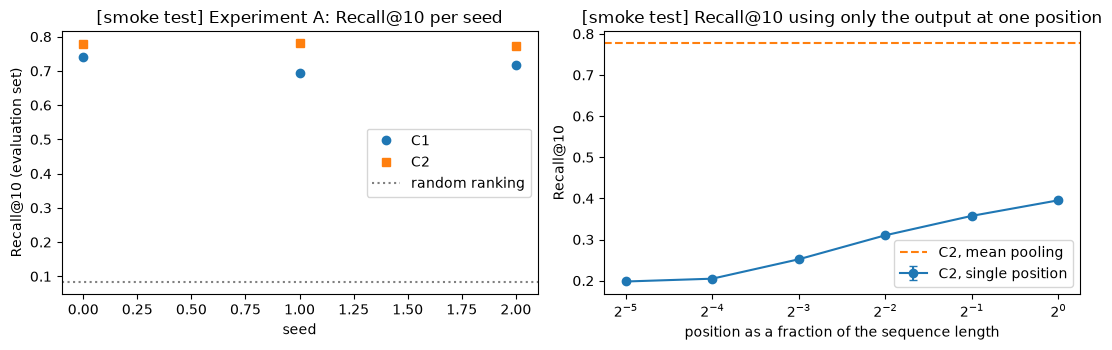

In [11]:
_seeds = list(range(SEEDS_A))
R_C1, R_C2_A = recall_of("C1", SEEDS_A), recall_of("C2", SEEDS_A)
A_PER_SEED = R_C1 - R_C2_A
_boot = bootstrap_recall([("C1", s) for s in _seeds] + [("C2", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_A].mean(axis=1) - _boot[:, SEEDS_A:].mean(axis=1)
DELTA_A = float(A_PER_SEED.mean())
SIGMA_A = combined_sigma(A_PER_SEED, _boot_contrast)

_p1_loss = {(c, s): learning_precondition(RUNS[(c, s)], strict=True) for c in ("C1", "C2") for s in _seeds}
_p1_floor = bool((R_C2_A >= RANDOM_RECALL["evaluation"] + P1_RECALL_MARGIN).all())
_p1_ratio_max = max(RUNS[k]["final_train_loss"] / RUNS[k]["initial_train_loss"] for k in _p1_loss)
precondition_status["P1(A)"] = all(_p1_loss.values()) and _p1_floor
precondition_status["P2(A)"] = bool(R_C2_A.mean() <= P2_RECALL_CEILING)
A_PRECONDITIONS = ["P0(A)", "P1(A)", "P2(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"])
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 A(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C1): {rounded(R_C1)}、R(C2): {rounded(R_C2_A)}")
print(f"  d_s = R(C1) - R(C2): {rounded(A_PER_SEED)}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(A)']}、P1 {precondition_status['P1(A)']}(損失の不成立 {[k for k, v in _p1_loss.items() if not v] or 'なし'}、"
    f"最後の区間 / 最初の区間の訓練損失の最大 {_p1_ratio_max:.3f} <= {P1_LOSS_DECREASE_RATIO}。R(C2) の最小 {R_C2_A.min():.4f} >= ランダム {RANDOM_RECALL['evaluation']:.4f} + {P1_RECALL_MARGIN} = "
    f"{RANDOM_RECALL['evaluation'] + P1_RECALL_MARGIN:.4f}: {_p1_floor})、P2 {precondition_status['P2(A)']}(R(C2) の平均 {R_C2_A.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {A_COMPUTED} -> {RUN_TAG}最終判定: {A_VERDICT}")

# 診断量(判定なし)
print("  診断量: 作用点に近い量。C2 のモデルで、位置 t の出力だけを埋め込みにしたときの Recall@10(学習を伴わない評価。query の位置 / passage の位置は系列の長さに対する割合から決める)")
_position_means = {}
for _fraction, _tq, _tp in zip(POSITION_FRACTIONS, POSITIONS_QUERY, POSITIONS_PASSAGE, strict=True):
    _values = np.array([RUNS[("C2", s)]["position_hits"][_fraction].mean() for s in range(NUM_SEEDS["C2"])])
    _position_means[_fraction] = (float(_values.mean()), float(_values.std(ddof=1)))
    print(f"    割合 {_fraction:.4f}(query の位置 {_tq}、passage の位置 {_tp}): {_values.mean():.4f}(シード間の標準偏差 {_values.std(ddof=1):.4f})")
print(f"    参照: C2 の平均プール {recall_of('C2', NUM_SEEDS['C2']).mean():.4f}、C1 の終端位置 {recall_of('C1', NUM_SEEDS['C1']).mean():.4f}")
for _c in ("C1", "C2"):
    _mrr = np.array([(1 / RUNS[(_c, s)]["rank"][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])])
    _ndcg = np.array([RUNS[(_c, s)]["ndcg_at_10"].mean() for s in range(NUM_SEEDS[_c])])
    _loss = np.array([RUNS[(_c, s)]["final_train_loss"] for s in range(NUM_SEEDS[_c])])
    print(
        f"  診断量: {_c} の MRR {_mrr.mean():.4f}・nDCG@10 {_ndcg.mean():.4f}・最後の区間の訓練損失 {_loss.mean():.3f}"
        f"・学習率 {LEARNING_RATE[_c]:.3g}(出どころ {LEARNING_RATE_SOURCE[_c]})・clipping の発動 {np.mean([RUNS[(_c, s)]['clip_rate'] for s in range(NUM_SEEDS[_c])]):.2f}"
    )

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C1", "o"), ("C2", "s")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].axhline(RANDOM_RECALL["evaluation"], color="gray", linestyle=":", label="random ranking")
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment A: Recall@10 per seed")
_axes[0].legend()
_x = list(_position_means)
_axes[1].errorbar(_x, [_position_means[f][0] for f in _x], yerr=[_position_means[f][1] for f in _x], marker="o", capsize=3, label="C2, single position")
_axes[1].axhline(recall_of("C2", NUM_SEEDS["C2"]).mean(), color="C1", linestyle="--", label="C2, mean pooling")
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("position as a fraction of the sequence length")
_axes[1].set_ylabel("Recall@10")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 using only the output at one position")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.8 実験 B: 平均プールでの注意マスク(双方向 と 因果)

[スモークテスト] 実験 B(シード [0, 1, 2]、T = 16)
  Recall@10 R(C3): [0.7918, 0.7892, 0.791]、R(C2): [0.7773, 0.7807, 0.773]
  d_s = R(C3) - R(C2): [0.0145, 0.0085, 0.0179]
  Delta_B = +0.0137、sigma_B = 0.0100(シード間 0.0027・ブートストラップ 0.0096、反復 1,000)、閾値 2 sigma_B = 0.0200
  前提条件: P0 True、P1 False(損失の不成立 [('C2', 1), ('C2', 2), ('C3', 1), ('C3', 2)]、R(C2) の最小 0.7730 >= 0.3831: True)、P2 True(R(C2) の平均 0.7770 <= 0.95)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ (1, 2, 4, 8, 16))
    C2: [0.8046, 0.8097, 0.8133, 0.8154, 0.8169]
    C3: [0.8303, 0.8333, 0.8364, 0.8421, 0.8431]
  診断量: C2 の最後の区間の訓練損失 2.290・学習率 0.0001(出どころ C2)・MRR 0.5691
  診断量: C3 の最後の区間の訓練損失 2.129・学習率 0.0001(出どころ C3)・MRR 0.5986


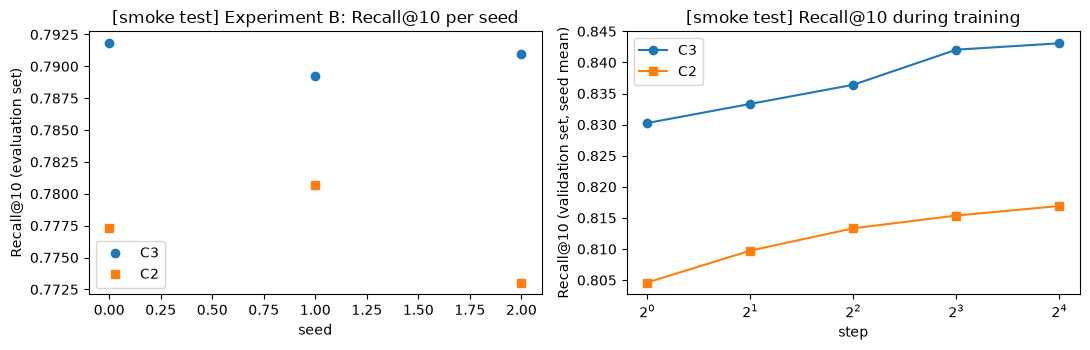

In [12]:
_seeds = list(range(SEEDS_B))
R_C2_B, R_C3 = recall_of("C2", SEEDS_B), recall_of("C3", SEEDS_B)
B_PER_SEED = R_C3 - R_C2_B
_boot = bootstrap_recall([("C3", s) for s in _seeds] + [("C2", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_B].mean(axis=1) - _boot[:, SEEDS_B:].mean(axis=1)
DELTA_B = float(B_PER_SEED.mean())
SIGMA_B = combined_sigma(B_PER_SEED, _boot_contrast)

_p1_loss = {(c, s): learning_precondition(RUNS[(c, s)], strict=True) for c in ("C2", "C3") for s in _seeds}
_p1_floor = bool((R_C2_B >= RANDOM_RECALL["evaluation"] + P1_RECALL_MARGIN).all())
precondition_status["P1(B)"] = all(_p1_loss.values()) and _p1_floor
precondition_status["P2(B)"] = bool(R_C2_B.mean() <= P2_RECALL_CEILING)
B_PRECONDITIONS = ["P0(B)", "P1(B)", "P2(B)"]
B_COMPUTED = judge(DELTA_B, SIGMA_B["sigma"])
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 B(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C3): {rounded(R_C3)}、R(C2): {rounded(R_C2_B)}")
print(f"  d_s = R(C3) - R(C2): {rounded(B_PER_SEED)}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B['sigma']:.4f}(シード間 {SIGMA_B['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_B['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(B)']}、P1 {precondition_status['P1(B)']}(損失の不成立 {[k for k, v in _p1_loss.items() if not v] or 'なし'}、"
    f"R(C2) の最小 {R_C2_B.min():.4f} >= {RANDOM_RECALL['evaluation'] + P1_RECALL_MARGIN:.4f}: {_p1_floor})、"
    f"P2 {precondition_status['P2(B)']}(R(C2) の平均 {R_C2_B.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {B_COMPUTED} -> {RUN_TAG}最終判定: {B_VERDICT}")

# 診断量(判定なし): 学習の初期に密な位置での検証用の集合の Recall@10(シード平均)
print(f"  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ {EVAL_STEPS})")
for _c in ("C2", "C3"):
    print(f"    {_c}: {rounded(np.mean([RUNS[(_c, s)]['eval_validation_recall'] for s in range(NUM_SEEDS[_c])], axis=0))}")
for _c in ("C2", "C3"):
    print(
        f"  診断量: {_c} の最後の区間の訓練損失 {np.mean([RUNS[(_c, s)]['final_train_loss'] for s in range(NUM_SEEDS[_c])]):.3f}・"
        f"学習率 {LEARNING_RATE[_c]:.3g}(出どころ {LEARNING_RATE_SOURCE[_c]})・MRR "
        f"{np.mean([(1 / RUNS[(_c, s)]['rank'][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])]):.4f}"
    )

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C3", "o"), ("C2", "s")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment B: Recall@10 per seed")
_axes[0].legend()
for _c, _marker in (("C3", "o"), ("C2", "s")):
    _curves = np.array([RUNS[(_c, s)]["eval_validation_recall"] for s in range(NUM_SEEDS[_c])])
    _axes[1].plot(EVAL_STEPS, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("Recall@10 (validation set, seed mean)")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.9 実験 C: 事前学習の効果(008 の重み と ランダム初期化)

[スモークテスト] 実験 C(シード [0, 1, 2]、T = 16)
  Recall@10 R(C2): [0.7773, 0.7807, 0.773]、R(C4): [0.2244, 0.1971, 0.2056]
  d_s = R(C2) - R(C4): [0.5529, 0.5836, 0.5674]
  Delta_C = +0.5680、sigma_C = 0.0185(シード間 0.0089・ブートストラップ 0.0163、反復 1,000)、閾値 2 sigma_C = 0.0370
  前提条件: P0 False、P1 False(損失の不成立 [('C2', 1), ('C2', 2)]、R(C2) の最小 0.7730 >= 0.3831: True)、P2 True(R(C4) の平均 0.2090 <= 0.95)
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 前提不成立
[スモークテスト] 実験 C′(008 が見ていない記事の query だけ: query 158 個、記事 16 本、シード [0, 1, 2]、T = 16)
  Recall@10 R(C2): [0.7025, 0.7152, 0.7152]、R(C4): [0.2342, 0.1709, 0.1899]
  d_s = R(C2) - R(C4): [0.4684, 0.5443, 0.5253]
  Delta_C' = +0.5127、sigma_C' = 0.0517(シード間 0.0228・ブートストラップ 0.0464、反復 1,000、記事 16 本を復元抽出)、閾値 2 sigma_C' = 0.1034
  前提条件(実験 C と共通): {"P0(C)": false, "P1(C)": false, "P2(C)": true}
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ (1, 2, 4, 8, 16))
    C2: [0.8046, 0.8097, 0.8133, 0.8154, 0.8169]
    C4: [0.2477, 0.2446, 0.2441, 0.2446, 0.24

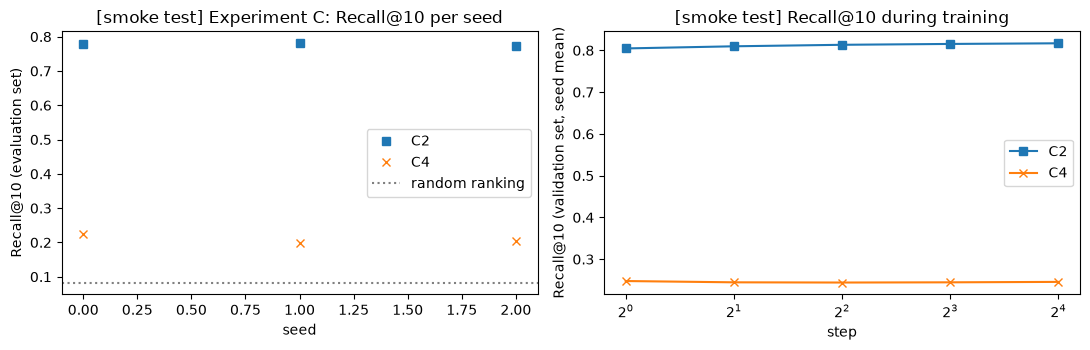

In [13]:
_seeds = list(range(SEEDS_C))
R_C2_C, R_C4 = recall_of("C2", SEEDS_C), recall_of("C4", SEEDS_C)
C_PER_SEED = R_C2_C - R_C4
_keys = [("C2", s) for s in _seeds] + [("C4", s) for s in _seeds]
_boot = bootstrap_recall(_keys)
_boot_contrast = _boot[:, :SEEDS_C].mean(axis=1) - _boot[:, SEEDS_C:].mean(axis=1)
DELTA_C = float(C_PER_SEED.mean())
SIGMA_C = combined_sigma(C_PER_SEED, _boot_contrast)

_p1_loss = {("C2", s): learning_precondition(RUNS[("C2", s)], strict=True) for s in _seeds} | {
    ("C4", s): learning_precondition(RUNS[("C4", s)], strict=False) for s in _seeds
}
_p1_floor = bool((R_C2_C >= RANDOM_RECALL["evaluation"] + P1_RECALL_MARGIN).all())
precondition_status["P1(C)"] = all(_p1_loss.values()) and _p1_floor
precondition_status["P2(C)"] = bool(R_C4.mean() <= P2_RECALL_CEILING)
C_PRECONDITIONS = ["P0(C)", "P1(C)", "P2(C)"]
C_COMPUTED = judge(DELTA_C, SIGMA_C["sigma"])
C_VERDICT = C_COMPUTED if all(precondition_status[k] for k in C_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 C(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C2): {rounded(R_C2_C)}、R(C4): {rounded(R_C4)}")
print(f"  d_s = R(C2) - R(C4): {rounded(C_PER_SEED)}")
print(
    f"  Delta_C = {DELTA_C:+.4f}、sigma_C = {SIGMA_C['sigma']:.4f}(シード間 {SIGMA_C['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_C['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_C = {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(C)']}、P1 {precondition_status['P1(C)']}(損失の不成立 {[k for k, v in _p1_loss.items() if not v] or 'なし'}、"
    f"R(C2) の最小 {R_C2_C.min():.4f} >= {RANDOM_RECALL['evaluation'] + P1_RECALL_MARGIN:.4f}: {_p1_floor})、"
    f"P2 {precondition_status['P2(C)']}(R(C4) の平均 {R_C4.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {C_COMPUTED} -> {RUN_TAG}最終判定: {C_VERDICT}")

# --- 実験 C′: 008 が見ていない記事の query だけでの対比量(判定つき。6.1 節) ---
_unseen_mask = ~EVALUATION_QUERY_SEEN_BY_REFERENCE
_unseen_articles = len(np.unique(EVALUATION_SET.query_articles[_unseen_mask]))
_hits_unseen = {c: np.array([RUNS[(c, s)]["hits"][EMBEDDING_DIMENSION][_unseen_mask].mean() for s in _seeds]) for c in ("C2", "C4")}
C_PRIME_PER_SEED = _hits_unseen["C2"] - _hits_unseen["C4"]
_boot_unseen = bootstrap_recall(_keys, query_mask=_unseen_mask)  # 008 が見ていない記事だけを復元抽出する
_boot_contrast_unseen = _boot_unseen[:, :SEEDS_C].mean(axis=1) - _boot_unseen[:, SEEDS_C:].mean(axis=1)
DELTA_C_PRIME = float(C_PRIME_PER_SEED.mean())
SIGMA_C_PRIME = combined_sigma(C_PRIME_PER_SEED, _boot_contrast_unseen)
C_PRIME_PRECONDITIONS = C_PRECONDITIONS  # 前提条件は実験 C と共通(P0・P1・P2 は全 query での値で定義する。6.1 節)
C_PRIME_COMPUTED = judge(DELTA_C_PRIME, SIGMA_C_PRIME["sigma"])
C_PRIME_VERDICT = C_PRIME_COMPUTED if all(precondition_status[k] for k in C_PRIME_PRECONDITIONS) else "前提不成立"
print(f"{RUN_TAG}実験 C′(008 が見ていない記事の query だけ: query {int(_unseen_mask.sum())} 個、記事 {_unseen_articles} 本、シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C2): {rounded(_hits_unseen['C2'])}、R(C4): {rounded(_hits_unseen['C4'])}")
print(f"  d_s = R(C2) - R(C4): {rounded(C_PRIME_PER_SEED)}")
print(
    f"  Delta_C' = {DELTA_C_PRIME:+.4f}、sigma_C' = {SIGMA_C_PRIME['sigma']:.4f}(シード間 {SIGMA_C_PRIME['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_C_PRIME['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,}、記事 {_unseen_articles} 本を復元抽出)、閾値 2 sigma_C' = {SIGMA_MULTIPLIER * SIGMA_C_PRIME['sigma']:.4f}"
)
print(f"  前提条件(実験 C と共通): {json.dumps({k: precondition_status[k] for k in C_PRIME_PRECONDITIONS})}")
print(f"  判定関数の結果 {C_PRIME_COMPUTED} -> {RUN_TAG}最終判定: {C_PRIME_VERDICT}")

# 診断量(判定なし)
print(f"  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ {EVAL_STEPS})")
for _c in ("C2", "C4"):
    print(f"    {_c}: {rounded(np.mean([RUNS[(_c, s)]['eval_validation_recall'] for s in range(NUM_SEEDS[_c])], axis=0))}")
print("  診断量: 008 が見た記事の query だけでの対比量(008 の事前学習で見た記事の記憶による有利さが混ざりうる部分。記事を単位とするブートストラップ)")
_seen_mask = EVALUATION_QUERY_SEEN_BY_REFERENCE
_hits_seen = {c: np.array([RUNS[(c, s)]["hits"][EMBEDDING_DIMENSION][_seen_mask].mean() for s in _seeds]) for c in ("C2", "C4")}
_per_seed_seen = _hits_seen["C2"] - _hits_seen["C4"]
_boot_seen = bootstrap_recall(_keys, query_mask=_seen_mask)
_sigma_seen = combined_sigma(_per_seed_seen, _boot_seen[:, :SEEDS_C].mean(axis=1) - _boot_seen[:, SEEDS_C:].mean(axis=1))
print(
    f"    008 が見た記事(query {int(_seen_mask.sum())} 個、記事 {len(np.unique(EVALUATION_SET.query_articles[_seen_mask]))} 本): R(C2) {_hits_seen['C2'].mean():.4f}・R(C4) {_hits_seen['C4'].mean():.4f}・"
    f"差 {_per_seed_seen.mean():+.4f}(標準偏差 {_sigma_seen['sigma']:.4f}、2 倍 {SIGMA_MULTIPLIER * _sigma_seen['sigma']:.4f})"
)
print("  診断量: 汎化の差(学習用の部分の索引の Recall@10 - 評価用の Recall@10。別の記事・別の索引の大きさなので、条件間での差の違いを読む)")
_gap = {}
for _c in ("C2", "C4"):
    _train = np.array([RUNS[(_c, s)]["train_probe_recall"] for s in _seeds])
    _gap[_c] = _train - recall_of(_c, SEEDS_C)
    print(f"    {_c}: 学習用の部分 {_train.mean():.4f}、差の平均 {_gap[_c].mean():+.4f}、各シード {rounded(_gap[_c])}")
print(f"    同じシードの C2 との差(C4 の差 - C2 の差)の平均 {(_gap['C4'] - _gap['C2']).mean():+.4f}、各シード {rounded(_gap['C4'] - _gap['C2'])}")
print(
    f"  診断量: 最後の区間の訓練損失 C2 {np.mean([RUNS[('C2', s)]['final_train_loss'] for s in _seeds]):.3f}・C4 {np.mean([RUNS[('C4', s)]['final_train_loss'] for s in _seeds]):.3f}、"
    f"学習率 C2 {LEARNING_RATE['C2']:.3g}・C4 {LEARNING_RATE['C4']:.3g}"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C2", "s"), ("C4", "x")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].axhline(RANDOM_RECALL["evaluation"], color="gray", linestyle=":", label="random ranking")
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment C: Recall@10 per seed")
_axes[0].legend()
for _c, _marker in (("C2", "s"), ("C4", "x")):
    _curves = np.array([RUNS[(_c, s)]["eval_validation_recall"] for s in range(NUM_SEEDS[_c])])
    _axes[1].plot(EVAL_STEPS, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("Recall@10 (validation set, seed mean)")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.10 実験 D: Matryoshka Representation Learning(先頭 16 次元)

[スモークテスト] 実験 D(シード [0, 1, 2]、T = 16)
  先頭 16 次元の Recall@10 R_16(C5): [0.6092, 0.6084, 0.5785]、R_16(C2): [0.5367, 0.552, 0.5452]
  d_s = R_16(C5) - R_16(C2): [0.0725, 0.0563, 0.0333]
  Delta_D = +0.0540、sigma_D = 0.0159(シード間 0.0114・ブートストラップ 0.0110、反復 1,000)、閾値 2 sigma_D = 0.0317
  前提条件: P0 True、P1 False(損失の不成立 [('C2', 1), ('C2', 2), ('C5', 2)]、R(C2) の最小 0.7730 >= 0.3831: True)、P2 True(R_16(C2) の平均 0.5447 <= 0.95)
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 前提不成立
  診断量: 入れ子の次元 m ごとの Recall@10(シード平均 ± シード間の標準偏差)と、同じシードの差 C5 - C2(標準偏差は判定と同じ構成)
    m =  16: C5 0.5987 ± 0.0175、C2 0.5447 ± 0.0077、差 +0.0540(標準偏差 0.0159、2 倍 0.0317)
    m =  32: C5 0.6923 ± 0.0092、C2 0.6729 ± 0.0013、差 +0.0193(標準偏差 0.0097、2 倍 0.0193)
    m =  64: C5 0.7352 ± 0.0044、C2 0.7327 ± 0.0055、差 +0.0026(標準偏差 0.0095、2 倍 0.0190)
    m = 128: C5 0.7585 ± 0.0043、C2 0.7642 ± 0.0075、差 -0.0057(標準偏差 0.0088、2 倍 0.0177)
    m = 256: C5 0.7742 ± 0.0018、C2 0.7770 ± 0.0038、差 -0.0028(標準偏差 0.0071、2 倍 0.0142)
  診断量: C5 の最後の区間の次元ごとの訓練損失 [2.682, 2.31, 

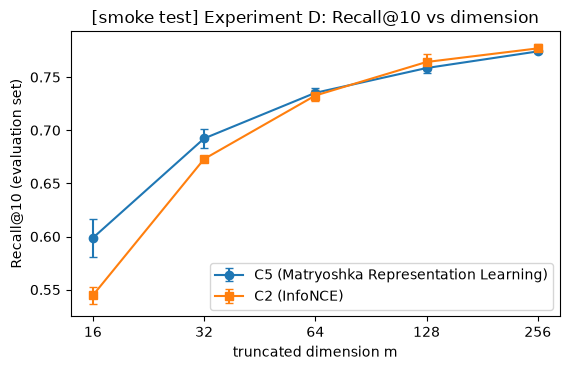

In [14]:
_seeds = list(range(SEEDS_D))
SMALLEST = MATRYOSHKA_DIMENSIONS[0]  # 16
R16_C2 = recall_of("C2", SEEDS_D, SMALLEST)
R16_C5 = recall_of("C5", SEEDS_D, SMALLEST)
D_PER_SEED = R16_C5 - R16_C2
_keys5 = [("C5", s) for s in _seeds]
_keys2 = [("C2", s) for s in _seeds]
_boot = paired_cluster_bootstrap_ratio_of_sums(
    np.concatenate([hits_matrix(_keys5, SMALLEST), hits_matrix(_keys2, SMALLEST)]), np.ones(EVALUATION_SET.num_queries),
    EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED,
)
_boot_contrast = _boot[:, :SEEDS_D].mean(axis=1) - _boot[:, SEEDS_D:].mean(axis=1)
DELTA_D = float(D_PER_SEED.mean())
SIGMA_D = combined_sigma(D_PER_SEED, _boot_contrast)

R256_C2 = recall_of("C2", SEEDS_D)
_p1_loss = {(c, s): learning_precondition(RUNS[(c, s)], strict=True) for c in ("C2", "C5") for s in _seeds}
_p1_floor = bool((R256_C2 >= RANDOM_RECALL["evaluation"] + P1_RECALL_MARGIN).all())
precondition_status["P1(D)"] = all(_p1_loss.values()) and _p1_floor
precondition_status["P2(D)"] = bool(R16_C2.mean() <= P2_RECALL_CEILING)
D_PRECONDITIONS = ["P0(D)", "P1(D)", "P2(D)"]
D_COMPUTED = judge(DELTA_D, SIGMA_D["sigma"])
D_VERDICT = D_COMPUTED if all(precondition_status[k] for k in D_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 D(シード {_seeds}、T = {NUM_STEPS})")
print(f"  先頭 {SMALLEST} 次元の Recall@10 R_{SMALLEST}(C5): {rounded(R16_C5)}、R_{SMALLEST}(C2): {rounded(R16_C2)}")
print(f"  d_s = R_{SMALLEST}(C5) - R_{SMALLEST}(C2): {rounded(D_PER_SEED)}")
print(
    f"  Delta_D = {DELTA_D:+.4f}、sigma_D = {SIGMA_D['sigma']:.4f}(シード間 {SIGMA_D['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_D['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_D = {SIGMA_MULTIPLIER * SIGMA_D['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(D)']}、P1 {precondition_status['P1(D)']}(損失の不成立 {[k for k, v in _p1_loss.items() if not v] or 'なし'}、"
    f"R(C2) の最小 {R256_C2.min():.4f} >= {RANDOM_RECALL['evaluation'] + P1_RECALL_MARGIN:.4f}: {_p1_floor})、"
    f"P2 {precondition_status['P2(D)']}(R_{SMALLEST}(C2) の平均 {R16_C2.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {D_COMPUTED} -> {RUN_TAG}最終判定: {D_VERDICT}")

# 診断量(判定なし): 全ての m で、両条件の Recall@10。「全次元では劣化しない」は別の検証事項で、判定に含めない
print("  診断量: 入れ子の次元 m ごとの Recall@10(シード平均 ± シード間の標準偏差)と、同じシードの差 C5 - C2(標準偏差は判定と同じ構成)")
_dimension_table = {}
for _m in MATRYOSHKA_DIMENSIONS:
    _a, _b = recall_of("C5", SEEDS_D, _m), recall_of("C2", SEEDS_D, _m)
    _boot_m = paired_cluster_bootstrap_ratio_of_sums(
        np.concatenate([hits_matrix(_keys5, _m), hits_matrix(_keys2, _m)]), np.ones(EVALUATION_SET.num_queries),
        EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED,
    )
    _sigma_m = combined_sigma(_a - _b, _boot_m[:, :SEEDS_D].mean(axis=1) - _boot_m[:, SEEDS_D:].mean(axis=1))
    _dimension_table[_m] = (float(_a.mean()), float(_a.std(ddof=1)), float(_b.mean()), float(_b.std(ddof=1)))
    print(
        f"    m = {_m:>3}: C5 {_a.mean():.4f} ± {_a.std(ddof=1):.4f}、C2 {_b.mean():.4f} ± {_b.std(ddof=1):.4f}、差 {(_a - _b).mean():+.4f}"
        f"(標準偏差 {_sigma_m['sigma']:.4f}、2 倍 {SIGMA_MULTIPLIER * _sigma_m['sigma']:.4f})"
    )
print(
    f"  診断量: C5 の最後の区間の次元ごとの訓練損失 {rounded(np.mean([RUNS[('C5', s)]['final_dimension_losses'] for s in _seeds], axis=0), 3)}"
    f"(m = {MATRYOSHKA_DIMENSIONS})、C5 の最後の区間の訓練損失(平均)の平均 {np.mean([RUNS[('C5', s)]['final_train_loss'] for s in _seeds]):.3f}、"
    f"clipping の発動 C5 {np.mean([RUNS[('C5', s)]['clip_rate'] for s in _seeds]):.2f}・C2 {np.mean([RUNS[('C2', s)]['clip_rate'] for s in _seeds]):.2f}"
)
print(f"  診断量: 索引のメモリ(FP32、評価用の passage {EVALUATION_SET.num_passages} 個): " + "、".join(f"m = {m}: {4 * EVALUATION_SET.num_passages * m / 1024:.0f} KiB" for m in MATRYOSHKA_DIMENSIONS))

_fig, _axis = plt.subplots(figsize=(5.8, 3.8))
for _label, _column, _marker in (("C5 (Matryoshka Representation Learning)", 0, "o"), ("C2 (InfoNCE)", 2, "s")):
    _axis.errorbar(
        [math.log2(m) for m in MATRYOSHKA_DIMENSIONS], [_dimension_table[m][_column] for m in MATRYOSHKA_DIMENSIONS],
        yerr=[_dimension_table[m][_column + 1] for m in MATRYOSHKA_DIMENSIONS], marker=_marker, capsize=3, label=_label,
    )
_axis.set_xticks([math.log2(m) for m in MATRYOSHKA_DIMENSIONS])
_axis.set_xticklabels([str(m) for m in MATRYOSHKA_DIMENSIONS])
_axis.set_xlabel("truncated dimension m")
_axis.set_ylabel("Recall@10 (evaluation set)")
_axis.set_title(f"{PLOT_TAG}Experiment D: Recall@10 vs dimension")
_axis.legend()
plt.tight_layout()
plt.show()

### 6.11 観察 E・F(判定基準を設けない)

**観察 E: BM25 との比較。** 評価用の同じ索引・同じ query で BM25 の Recall@10・MRR・nDCG@10 を測り、各条件(全次元)の値と並べる。優劣は判定しない。BM25 は学習を伴わず、シードを持たない。

**観察 F: 異方性と alignment・uniformity。** 対照学習の前(008 の重みのまま、平均プール・因果マスク)と後(C2 のシード 0)で、評価用の passage の埋め込みについて、
ランダムな 2 つの組のコサイン類似度の平均(異方性)、alignment(正例の組 = 各 query と、その記事の次の窓の passage)、uniformity、Recall@10 を測る。
定性的な観察であり、判定基準を設けない。

In [15]:
# --- 観察 E: BM25 ---
_t0_bm25 = time.time()
BM25_INDEX = BM25Index(EVALUATION_SET.passages, tokenizer.vocab_size)
BM25_RESULT = rank_candidates(
    torch.from_numpy(BM25_INDEX.score_batch(EVALUATION_SET.queries)), EVALUATION_SET.query_articles, EVALUATION_SET.passage_articles, EVALUATION_SET.query_sources
)
_bm25_boot = paired_cluster_bootstrap_ratio_of_sums(
    BM25_RESULT.hits(10).astype(np.float64), np.ones(EVALUATION_SET.num_queries), EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
)
print(
    f"{RUN_TAG}観察 E(評価用の索引 {EVALUATION_SET.num_passages} passage・query {EVALUATION_SET.num_queries} 個、ランダムな順位の Recall@10 の期待値 {RANDOM_RECALL['evaluation']:.4f}、"
    f"BM25 k1 = {BM25_INDEX.k1}・b = {BM25_INDEX.b}、{time.time() - _t0_bm25:.1f} 秒)"
)
print(
    f"  BM25: Recall@10 {BM25_RESULT.recall_at(10):.4f}(記事を単位とするブートストラップの標準偏差 {_bm25_boot.std(ddof=1):.4f})・MRR {BM25_RESULT.mean_reciprocal_rank():.4f}・"
    f"nDCG@10 {BM25_RESULT.mean_ndcg_at_10():.4f}"
)
OBSERVATION_E = {"BM25": (BM25_RESULT.recall_at(10), BM25_RESULT.mean_reciprocal_rank(), BM25_RESULT.mean_ndcg_at_10())}
for _c in RUN_ORDER:
    _recalls = recall_of(_c, NUM_SEEDS[_c])
    _mrr = np.array([(1 / RUNS[(_c, s)]["rank"][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])])
    _ndcg = np.array([RUNS[(_c, s)]["ndcg_at_10"].mean() for s in range(NUM_SEEDS[_c])])
    OBSERVATION_E[_c] = (float(_recalls.mean()), float(_mrr.mean()), float(_ndcg.mean()))
    print(
        f"  {_c}({NUM_SEEDS[_c]} シード): Recall@10 {_recalls.mean():.4f}(シード間の標準偏差 {_recalls.std(ddof=1):.4f})・MRR {_mrr.mean():.4f}・nDCG@10 {_ndcg.mean():.4f}"
    )
_unseen_mask = ~EVALUATION_QUERY_SEEN_BY_REFERENCE
print(
    f"  参考: 008 が見ていない記事の query だけでの Recall@10: BM25 {BM25_RESULT.hits(10)[_unseen_mask].mean():.4f}、"
    + "、".join(f"{c} {np.mean([RUNS[(c, s)]['hits'][EMBEDDING_DIMENSION][_unseen_mask].mean() for s in range(NUM_SEEDS[c])]):.4f}" for c in RUN_ORDER)
)

# --- 観察 F: 対照学習の前後 ---
_reference_model = build_model("C2", 0).to(device)  # 008 の重みのまま(平均プール・因果マスク)
_before = evaluate_set(_reference_model, "evaluation", keep_embeddings=True)
del _reference_model
empty_device_cache()


def positive_passage_index(retrieval_set) -> np.ndarray:
    # 各 query の正例の passage: 同じ記事の次の窓(最後の窓なら、同じ記事の最初の窓)。元の passage 自身は除く
    result = np.empty(retrieval_set.num_queries, dtype=np.int64)
    for i, (article, source) in enumerate(zip(retrieval_set.query_articles, retrieval_set.query_sources, strict=True)):
        members = np.nonzero(retrieval_set.passage_articles == article)[0]
        members = members[members != source]
        later = members[members > source]
        result[i] = later[0] if len(later) else members[0]
    return result


_positive = positive_passage_index(EVALUATION_SET)
assert (EVALUATION_SET.passage_articles[_positive] == EVALUATION_SET.query_articles).all() and not (_positive == EVALUATION_SET.query_sources).any()
GEOMETRY = {}
for _label, _embeddings in (
    ("008 の重みのまま", {"passages": _before["passage_embeddings"], "queries": _before["query_embeddings"], "recall": _before["by_dimension"][EMBEDDING_DIMENSION]}),
    ("対照学習の後(C2、シード 0)", {"passages": OBSERVATION_EMBEDDINGS["passages"], "queries": OBSERVATION_EMBEDDINGS["queries"], "recall": None}),
):
    _p, _q = _embeddings["passages"], _embeddings["queries"]
    GEOMETRY[_label] = {
        "mean_cosine": mean_pairwise_cosine(_p),
        "alignment": alignment(_q, _p[_positive]),
        "uniformity": uniformity(_p),
        "recall": _embeddings["recall"].recall_at(10) if _embeddings["recall"] is not None else float(RUNS[OBSERVATION_RUN]["hits"][EMBEDDING_DIMENSION].mean()),
        "mrr": _embeddings["recall"].mean_reciprocal_rank() if _embeddings["recall"] is not None else float((1 / RUNS[OBSERVATION_RUN]["rank"][EMBEDDING_DIMENSION]).mean()),
    }
print(f"{RUN_TAG}観察 F(評価用の passage {EVALUATION_SET.num_passages} 個の埋め込み。alignment は {EVALUATION_SET.num_queries} 組の正例)")
for _label, _g in GEOMETRY.items():
    print(
        f"  {_label}: ランダムな組のコサイン類似度の平均 {_g['mean_cosine']:.4f}・alignment {_g['alignment']:.4f}・uniformity {_g['uniformity']:.4f}・"
        f"Recall@10 {_g['recall']:.4f}・MRR {_g['mrr']:.4f}"
    )

[スモークテスト] 観察 E(評価用の索引 1172 passage・query 1172 個、ランダムな順位の Recall@10 の期待値 0.0831、BM25 k1 = 1.2・b = 0.75、0.0 秒)
  BM25: Recall@10 0.8473(記事を単位とするブートストラップの標準偏差 0.0139)・MRR 0.6825・nDCG@10 0.4398
  C2(3 シード): Recall@10 0.7770(シード間の標準偏差 0.0038)・MRR 0.5691・nDCG@10 0.3872
  C1(3 シード): Recall@10 0.7167(シード間の標準偏差 0.0226)・MRR 0.4693・nDCG@10 0.2910
  C3(3 シード): Recall@10 0.7907(シード間の標準偏差 0.0013)・MRR 0.5986・nDCG@10 0.4125
  C5(3 シード): Recall@10 0.7742(シード間の標準偏差 0.0018)・MRR 0.5647・nDCG@10 0.3878
  C4(3 シード): Recall@10 0.2090(シード間の標準偏差 0.0140)・MRR 0.1237・nDCG@10 0.0415
  参考: 008 が見ていない記事の query だけでの Recall@10: BM25 0.8544、C2 0.7110、C1 0.6245、C3 0.7278、C5 0.7046、C4 0.1983


[スモークテスト] 観察 F(評価用の passage 1172 個の埋め込み。alignment は 1172 組の正例)
  008 の重みのまま: ランダムな組のコサイン類似度の平均 0.3604・alignment 0.7051・uniformity -2.2569・Recall@10 0.7688・MRR 0.5632
  対照学習の後(C2、シード 0): ランダムな組のコサイン類似度の平均 0.4035・alignment 0.6480・uniformity -2.1297・Recall@10 0.7773・MRR 0.5700


### 6.12 不変条件のアサーションと`SMOKE_TEST`の配線

- 実効水準の照合: 実際に学習した条件・シード・ステップ数・途中の評価のステップが、5.2 節で印字した水準と 6.4 節で選ばれた計画に一致する。
- 同じシードの条件どうしで、学習の組(ハッシュ)が一致する。異なるシードでは異なる。
- 全条件で、学習ステップ数・バッチサイズ・query と passage の長さ・評価用の索引と query が同じである。
- 学習率が、較正した値または規則で決めた値に一致する。
- 記録した順位から再計算した Recall@10 が、記録した hits の平均と一致する。
- 実験 C′ の query の部分集合(008 が見ていない記事の query)が、評価用の索引と 008 の事前学習の範囲から宣言どおりに作られている。

In [16]:
# --- 実効水準の照合(SMOKE_TEST の配線) ---
assert CURRENT_LEVEL_NAME == ("smoke" if SMOKE_TEST else "prod")
assert STEP_CANDIDATES == LEVELS[CURRENT_LEVEL_NAME]["STEP_CANDIDATES"] and NUM_STEPS in STEP_CANDIDATES
assert BOOTSTRAP_RESAMPLES == LEVELS[CURRENT_LEVEL_NAME]["BOOTSTRAP_RESAMPLES"]
assert NUM_SEEDS == STAGES[CURRENT_LEVEL_NAME][STAGE]["seeds"] and SELECTED_PLAN == PLANS[SELECTED_PLAN["plan"]]
assert set(RUNS) == {(c, s) for c in CONDITIONS for s in range(NUM_SEEDS[c])}, "学習した条件・シードが選ばれた計画と一致しない"
assert all(r["num_steps"] == NUM_STEPS and len(r["train_loss"]) == NUM_STEPS for r in RUNS.values())
assert all(r["eval_step"] == (list(EVAL_STEPS) if CONDITIONS[r["condition"]]["track"] else []) for r in RUNS.values())
assert all(r["learning_rate"] == LEARNING_RATE[r["condition"]] for r in RUNS.values())
assert all(LEARNING_RATE[c] == CALIBRATION[LEARNING_RATE_SOURCE[c]]["chosen"] for c in CONDITIONS)
assert all(len(r["eval_validation_recall"]) == len(r["eval_step"]) for r in RUNS.values())
# --- 対応のある比較: 同じシードの条件どうしで学習の組が一致する / 異なるシードでは異なる ---
for _s in range(min(NUM_SEEDS.values())):
    assert len({RUNS[(c, _s)]["schedule_hash"] for c in CONDITIONS}) == 1, f"シード {_s} で学習の組が条件間で一致しない"
assert len({RUNS[("C2", s)]["schedule_hash"] for s in range(NUM_SEEDS["C2"])}) == NUM_SEEDS["C2"], "異なるシードで学習の組が同じ"
# --- キャッシュの導入前後の一致: 使い回している学習の組(SCHEDULES)が、毎回作り直した場合と完全に一致する ---
for (_seed_index, _steps), _cached in SCHEDULES.items():
    _fresh = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, _steps, BATCH_SIZE, seed=PAIR_SEED_BASE + _seed_index)
    assert set(_cached) == set(_fresh) and all(np.array_equal(_cached[k], _fresh[k]) for k in _fresh), (_seed_index, _steps)
    _digest = hashlib.sha256()
    for _key in ("article", "query_start", "passage_start"):
        _digest.update(np.ascontiguousarray(_fresh[_key], dtype=np.int64).tobytes())
    for _record in RUNS.values():
        if _record["seed"] == _seed_index and _record["num_steps"] == _steps:
            assert _record["schedule_hash"] == _digest.hexdigest(), "学習に使われた組が、作り直した組と一致しない"
print(f"学習の組のキャッシュ({len(SCHEDULES)} 通り)が、作り直した場合と完全に一致(配列の完全一致と、学習の記録のハッシュの一致): OK")
# --- 全条件で評価の分母が同じ ---
assert all(
    r["hits"][m].shape == (EVALUATION_SET.num_queries,) and r["rank"][m].shape == (EVALUATION_SET.num_queries,) for r in RUNS.values() for m in MATRYOSHKA_DIMENSIONS
)
assert all(set(r["hits"]) == set(MATRYOSHKA_DIMENSIONS) for r in RUNS.values())
_rebuilt = make_sets()
assert [s.digest() for s in RETRIEVAL_SETS.values()] == [s.digest() for s in _rebuilt], "評価用の索引と query が実行の途中で変わった"
del _rebuilt
# --- 記録した順位から再計算した値の整合 ---
for _record in RUNS.values():
    for _m in MATRYOSHKA_DIMENSIONS:
        assert np.array_equal(_record["rank"][_m] <= 10, _record["hits"][_m])
        assert _record["rank"][_m].min() >= 1 and _record["rank"][_m].max() <= EVALUATION_SET.num_passages - 1
# --- 条件の定義が実際の学習で使われた ---
assert all(("final_dimension_losses" in r) == (CONDITIONS[r["condition"]]["loss"] == "matryoshka") for r in RUNS.values())
assert all(("position_hits" in r) == (r["condition"] == "C2") for r in RUNS.values())
assert UPLOAD_RUN in SAVED_STATES and set(SAVED_STATES) == {UPLOAD_RUN}
assert OBSERVATION_RUN in RUNS
# --- 実験 C′: 008 が見ていない記事の query の部分集合が、宣言どおりに作られている ---
_unseen_query_mask = ~EVALUATION_QUERY_SEEN_BY_REFERENCE
assert 0 < int(_unseen_query_mask.sum()) < EVALUATION_SET.num_queries
assert set(np.unique(EVALUATION_SET.query_articles[_unseen_query_mask]).tolist()) == set(UNSEEN_EVALUATION_ARTICLES), "実験 C′ の query の記事が、008 が見ていない評価用の記事と一致しない"
assert not (set(np.unique(EVALUATION_SET.query_articles[~_unseen_query_mask]).tolist()) & set(UNSEEN_ARTICLES)), "008 が見た記事の query に、008 が見ていない記事が混ざっている"
assert len(set(C_PRIME_PRECONDITIONS) - set(precondition_status)) == 0 and C_PRIME_PRECONDITIONS == C_PRECONDITIONS
assert all(r["finite"] for r in RUNS.values()), "有限でない損失の学習がある"
print(
    f"{RUN_TAG}実効水準: T = {NUM_STEPS}、計画 {SELECTED_PLAN['plan']}(段階 {STAGE}、較正の方式 {CALIBRATION_MODE!r})、シード数 {json.dumps(NUM_SEEDS)}、学習 {len(RUNS)} 回、"
    f"バッチ {BATCH_SIZE}、query {QUERY_LENGTH}・passage {PASSAGE_LENGTH}、評価用の query {EVALUATION_SET.num_queries} 個、ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回: 照合 OK"
)
print(f"同じシードの条件どうしで学習の組が一致(シード {min(NUM_SEEDS.values())} 個で確認)、異なるシードでは異なる: OK")

学習の組のキャッシュ(4 通り)が、作り直した場合と完全に一致(配列の完全一致と、学習の記録のハッシュの一致): OK
[スモークテスト] 実効水準: T = 16、計画 0(段階 0、較正の方式 'all')、シード数 {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 3}、学習 15 回、バッチ 64、query 32・passage 128、評価用の query 1172 個、ブートストラップ 1,000 回: 照合 OK
同じシードの条件どうしで学習の組が一致(シード 3 個で確認)、異なるシードでは異なる: OK


### 6.13 判定結果の一覧

In [17]:
print(f"{RUN_TAG}判定結果(計画 {SELECTED_PLAN['plan']}、T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})")
VERDICTS = {
    "A": (DELTA_A, SIGMA_A["sigma"], A_COMPUTED, A_VERDICT, A_PRECONDITIONS),
    "B": (DELTA_B, SIGMA_B["sigma"], B_COMPUTED, B_VERDICT, B_PRECONDITIONS),
    "C": (DELTA_C, SIGMA_C["sigma"], C_COMPUTED, C_VERDICT, C_PRECONDITIONS),
    "C′": (DELTA_C_PRIME, SIGMA_C_PRIME["sigma"], C_PRIME_COMPUTED, C_PRIME_VERDICT, C_PRIME_PRECONDITIONS),
    "D": (DELTA_D, SIGMA_D["sigma"], D_COMPUTED, D_VERDICT, D_PRECONDITIONS),
}
for _experiment, (_delta, _sigma, _computed, _verdict, _preconditions) in VERDICTS.items():
    print(
        f"  実験 {_experiment}: 対比量 {_delta:+.4f}、標準偏差 {_sigma:.4f}、閾値 {SIGMA_MULTIPLIER * _sigma:.4f}、判定関数の結果 {_computed}、"
        f"前提条件 {json.dumps({k: precondition_status[k] for k in _preconditions})} -> {RUN_TAG}最終判定: {_verdict}"
    )
TOTAL_SECONDS = time.time() - NOTEBOOK_START_TIME
print(f"全体の経過時間 {TOTAL_SECONDS / 60:.1f} 分(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分、計画の見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分 + 選択時の経過 {ELAPSED_AT_SELECTION / 60:.1f} 分)")

[スモークテスト] 判定結果(計画 0、T = 16、較正の方式 'all'、段階 0)
  実験 A: 対比量 -0.0603、標準偏差 0.0193、閾値 0.0386、判定関数の結果 反証、前提条件 {"P0(A)": false, "P1(A)": false, "P2(A)": true} -> [スモークテスト] 最終判定: 前提不成立
  実験 B: 対比量 +0.0137、標準偏差 0.0100、閾値 0.0200、判定関数の結果 判定不能、前提条件 {"P0(B)": true, "P1(B)": false, "P2(B)": true} -> [スモークテスト] 最終判定: 前提不成立
  実験 C: 対比量 +0.5680、標準偏差 0.0185、閾値 0.0370、判定関数の結果 支持、前提条件 {"P0(C)": false, "P1(C)": false, "P2(C)": true} -> [スモークテスト] 最終判定: 前提不成立
  実験 C′: 対比量 +0.5127、標準偏差 0.0517、閾値 0.1034、判定関数の結果 支持、前提条件 {"P0(C)": false, "P1(C)": false, "P2(C)": true} -> [スモークテスト] 最終判定: 前提不成立
  実験 D: 対比量 +0.0540、標準偏差 0.0159、閾値 0.0317、判定関数の結果 支持、前提条件 {"P0(D)": true, "P1(D)": false, "P2(D)": true} -> [スモークテスト] 最終判定: 前提不成立
全体の経過時間 6.4 分(予算 120 分、計画の見積もり 8.6 分 + 選択時の経過 1.8 分)


### 6.14 Hugging Face Hub へのアップロード(C5 のシード 0)

後続のトピック(025)の入力にするため、**条件 C5(Matryoshka Representation Learning)のシード 0** の学習後の重みを`kojikojiprg/ai-theories-text-embedding-en`(新規、public)にアップロードする。
アップロードするモデルは結果を見て選ばない(条件とシードを事前に固定している)。

- **アップロードのセルは`UPLOAD_ARTIFACTS`で守る。既定は`False`。** `SMOKE_TEST`とは独立のフラグで、本番(`SMOKE_TEST = False`)でも、アップロードは`UPLOAD_ARTIFACTS`を別途`True`にしたときだけ行う。
- Colab Secrets の`HF_TOKEN`が取得できない場合は、例外で停止せず、アップロードをスキップしてその旨を印字する。取得した値は印字・記録・加工しない。
- アップロード後、`list_repo_files()`でリポジトリに意図したファイルが実際に存在することを確かめる。`upload_file`が例外を送出しなかったことだけを根拠にしない。
- **このセルの前半(ファイルの書き出し・読み込み直し・評価・モデルカードの組み立て)は、`UPLOAD_ARTIFACTS`によらず毎回実行する**(アップロードしなくてもモデルカードの下書きを確認できるように)。
  モデルカードの指標は、書き出した重みを新しいモデルに読み込み直して評価した値とする(学習中の途中の評価値は使わない)。
- トークナイザは同梱しない。モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照する。

In [18]:
_t0_upload = time.time()
MODEL_CARD_TEMPLATE = """---
language: en
license: mit
tags:
- ai-theories
- text-embedding
- retrieval
- matryoshka-representation-learning
- scratch-implementation
---

# ai-theories テキスト埋め込みモデル(英語、Matryoshka Representation Learning)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を encoder として、英語 Wikipedia の同じ記事から切り出した重ならない 2 つの区間を正例の組にする
教師なしの対照学習(in-batch negatives の InfoNCE)と Matryoshka Representation Learning(入れ子の次元 {matryoshka_dimensions})で、全パラメータを更新したもの。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [024. テキスト埋め込みと retriever](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/024_text_embedding_and_retriever.ipynb)の
  条件 C5(Matryoshka Representation Learning)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した条件とシードである。
- 学習: {num_steps} ステップ、バッチ {batch_size} 組、query {query_length} トークン・passage {passage_length} トークン、温度 {temperature}、学習率 {learning_rate:.3g}、
  AdamW(重み減衰 {weight_decay})、warmup + cosine、gradient clipping {clip}。学習データは `kojikojiprg/ai-theories-corpus-en-pretraining` の学習用の記事のみ。

## 使うために必要な他のアーティファクト

- **トークナイザは同梱していない。** `kojikojiprg/ai-theories-tokenizer-en` を使用してください(語彙サイズ 8192、特殊トークンなし)。
- 本体の構成は `config.json`(008 の `config.json` と同じ構成に、埋め込みの設定を加えたもの)を参照。

## 埋め込みの作り方(プーリング・注意マスク・切り詰め)

- 注意マスク: **因果マスク**(008 と同じ)。
- プーリング: **平均プール**(最終正規化層の後の隠れ状態を、全位置で平均する)。射影層はない。
- 埋め込み: プーリングしたベクトルを L2 正規化する(次元 256)。類似度は内積(= コサイン類似度)。
- 切り詰め: 先頭 m 次元を取り出して **L2 正規化し直す**(m は {matryoshka_dimensions} のいずれか)。
- query は {query_length} トークン、passage は {passage_length} トークンの固定長で学習した(パディングは使わない)。

```python
import json
import torch
from huggingface_hub import hf_hub_download
from src.models.gpt import GPTLanguageModel
from src.models.text_embedding import TextEmbeddingModel, truncate_and_normalize

config = json.load(open(hf_hub_download("{repo_id}", "config.json")))
# GPTLanguageModel の構築は 008(kojikojiprg/ai-theories-small-gpt-en)の config.json と同じ(024 のノートブックの build_gpt() を参照)
backbone = build_gpt(config)
backbone.load_state_dict(torch.load(hf_hub_download("{repo_id}", "model_state.pt"), map_location="cpu"))
model = TextEmbeddingModel(backbone, pooling="mean", attention="causal").eval()
with torch.no_grad():
    embedding = model(token_ids)                  # 次元 256
    embedding_16 = model(token_ids, dimension=16)  # 先頭 16 次元を切り詰めて再正規化
```

## 評価(アップロードした重みそのものを読み込み直して測った値)

評価用の索引と query(`src/data/retrieval.py` の `build_retrieval_set()`)で、全件の内積による厳密な探索。query を含む passage は候補から除く。

| 次元 m | Recall@10 | MRR | nDCG@10 |
|---|---|---|---|
{evaluation_rows}

- ランダムな順位の Recall@10 の期待値: {random_recall:.4f}、BM25 の Recall@10: {bm25_recall:.4f}、評価用の query {num_queries} 個、索引 {num_passages} passage。
- 上の値は {smoke_note}

## 評価用の passage の集合の再構成(025 など後続のトピック向け)

評価用の索引と query は、次の手順で決定的に再構成できる(`src/data/retrieval.py`)。

1. コーパス `kojikojiprg/ai-theories-corpus-en-pretraining`(356 記事)と、記事の境界 `metadata.json` の `article_offsets` を取得する。
2. トークナイザ `kojikojiprg/ai-theories-tokenizer-en` で、記事ごとに別々に符号化する(`encode_articles()`)。
3. `split_articles(記事ごとのトークン数, {min_tokens}, 008 が見ていない記事, {num_validation}, {num_evaluation}, {split_seed})` で記事を分割し、評価用の記事を得る。
   「008 が見ていない記事」は、コーパスの末尾 5% の文字位置以降に始まる記事(`find_articles_starting_at_or_after()`)。
4. `build_retrieval_set(記事ごとのトークン, 評価用の記事, {passage_length}, {query_length}, {max_passages}, {max_queries}, {evaluation_seed})` で索引と query を得る。
   ダイジェスト(`RetrievalSet.digest()`)は `{evaluation_digest}`、分割のダイジェスト(`ArticleSplit.digest()`)は `{split_digest}`。

## 注意

- 学習データは 356 記事({total_tokens} トークン)の英語 Wikipedia に限られ、汎用の埋め込みモデルとして使えるものではない。
- 評価用の集合は、ノートブックの実行時点のコーパス(`article_offsets` を含む `metadata.json`)に依存する。
"""


def build_card_and_files(directory: Path) -> dict:
    # 学習後の重みをファイルに書き出し、新しいモデルに読み込み直して評価した値でモデルカードを組み立てる
    state = SAVED_STATES[UPLOAD_RUN]
    torch.save(state, directory / "model_state.pt")
    config = dict(REFERENCE_CONFIG) | {
        "embedding_dimension": EMBEDDING_DIMENSION,
        "pooling": "mean",
        "attention": "causal",
        "matryoshka_dimensions": list(MATRYOSHKA_DIMENSIONS),
        "temperature": TEMPERATURE,
        "query_length": QUERY_LENGTH,
        "passage_length": PASSAGE_LENGTH,
        "tokenizer_repo": TOKENIZER_REPO_ID,
        "base_model_repo": REFERENCE_MODEL_REPO_ID,
        "source_notebook": "theories/07_retrieval/024_text_embedding_and_retriever.ipynb",
    }
    (directory / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
    reloaded = TextEmbeddingModel(build_gpt(REFERENCE_CONFIG), pooling="mean", attention="causal")
    reloaded.backbone.load_state_dict(torch.load(directory / "model_state.pt", map_location="cpu"))
    assert all(torch.equal(a, b) for a, b in zip(reloaded.backbone.state_dict().values(), state.values(), strict=True)), "書き出した重みが一致しない"
    reloaded = reloaded.to(device)
    evaluated = evaluate_set(reloaded, "evaluation", MATRYOSHKA_DIMENSIONS)["by_dimension"]
    del reloaded
    empty_device_cache()
    # 学習直後の値(記録した順位)と、読み込み直した重みでの値が一致する(同じ関数・同じデバイス、符号化のバッチの大きさは結果に影響しない)
    for m, result in evaluated.items():
        assert abs(result.recall_at(10) - float(RUNS[UPLOAD_RUN]["hits"][m].mean())) <= 2 / EVALUATION_SET.num_queries, (m, result.recall_at(10))
    rows = "\n".join(
        f"| {m} | {r.recall_at(10):.4f} | {r.mean_reciprocal_rank():.4f} | {r.mean_ndcg_at_10():.4f} |" for m, r in evaluated.items()
    )
    card = MODEL_CARD_TEMPLATE.format(
        matryoshka_dimensions=", ".join(str(m) for m in MATRYOSHKA_DIMENSIONS),
        num_steps=NUM_STEPS, batch_size=BATCH_SIZE, query_length=QUERY_LENGTH, passage_length=PASSAGE_LENGTH,
        temperature=TEMPERATURE, learning_rate=LEARNING_RATE["C5"], weight_decay=WEIGHT_DECAY, clip=GRADIENT_CLIP_THRESHOLD,
        repo_id=UPLOAD_REPO_ID, evaluation_rows=rows, random_recall=RANDOM_RECALL["evaluation"], bm25_recall=BM25_RESULT.recall_at(10),
        num_queries=EVALUATION_SET.num_queries, num_passages=EVALUATION_SET.num_passages,
        smoke_note="スモークテストの値であり、意味を持たない。" if SMOKE_TEST else "本番の実行の値である。",
        min_tokens=MIN_TOKENS_FOR_RETRIEVAL, num_validation=NUM_VALIDATION_ARTICLES, num_evaluation=NUM_EVALUATION_ARTICLES, split_seed=SPLIT_SEED,
        max_passages=MAX_PASSAGES_PER_ARTICLE, max_queries=MAX_QUERIES_PER_ARTICLE, evaluation_seed=EVALUATION_SET_SEED,
        evaluation_digest=EVALUATION_SET.digest(), split_digest=SPLIT.digest(), total_tokens=f"約 {TOTAL_TOKENS / 1e6:.2f} 百万",
    )
    (directory / "README.md").write_text(card, encoding="utf-8")
    return {"evaluated": evaluated, "card": card, "files": sorted(p.name for p in directory.iterdir())}


with tempfile.TemporaryDirectory() as _temporary_directory:
    _built = build_card_and_files(Path(_temporary_directory))
    UPLOAD_FILES = _built["files"]
    assert UPLOAD_FILES == ["README.md", "config.json", "model_state.pt"], "トークナイザなど、同梱しないファイルが含まれている"
    print(f"{RUN_TAG}モデルカードの下書きと書き出したファイル {UPLOAD_FILES} を作成し、重みを読み込み直して評価した(Recall@10 {', '.join(f'm={m}: {r.recall_at(10):.4f}' for m, r in _built['evaluated'].items())})")
    print("--- モデルカードの先頭 ---")
    print("\n".join(_built["card"].splitlines()[:24]))

    if not UPLOAD_ARTIFACTS:
        print("UPLOAD_ARTIFACTS = False のため、アップロードは行わない(モデルカードの下書きの確認のみ)")
    else:
        try:
            from google.colab import userdata  # noqa: E402

            _token = userdata.get("HF_TOKEN")
        except Exception:  # noqa: BLE001  # Colab 以外・Secrets 未設定・取得失敗のいずれでも、停止せずスキップする
            _token = None
        if not _token:
            print("Colab Secrets から HF_TOKEN を取得できないため、アップロードをスキップする")
        else:
            from huggingface_hub import HfApi

            _api = HfApi(token=_token)
            _api.create_repo(UPLOAD_REPO_ID, repo_type="model", exist_ok=True, private=False)
            for _name in UPLOAD_FILES:
                _api.upload_file(path_or_fileobj=str(Path(_temporary_directory) / _name), path_in_repo=_name, repo_id=UPLOAD_REPO_ID, repo_type="model")
            _remote = sorted(_api.list_repo_files(UPLOAD_REPO_ID, repo_type="model"))
            _missing = [n for n in UPLOAD_FILES if n not in _remote]
            assert not _missing, f"アップロードしたはずのファイルがリポジトリにない: {_missing}"
            print(f"アップロード完了: {UPLOAD_REPO_ID} のファイル {_remote}(意図したファイルがすべて存在することを list_repo_files() で確認)")
print(f"アップロードの準備 {time.time() - _t0_upload:.1f} 秒")

[スモークテスト] モデルカードの下書きと書き出したファイル ['README.md', 'config.json', 'model_state.pt'] を作成し、重みを読み込み直して評価した(Recall@10 m=16: 0.6092, m=32: 0.6988, m=64: 0.7389, m=128: 0.7585, m=256: 0.7756)
--- モデルカードの先頭 ---
---
language: en
license: mit
tags:
- ai-theories
- text-embedding
- retrieval
- matryoshka-representation-learning
- scratch-implementation
---

# ai-theories テキスト埋め込みモデル(英語、Matryoshka Representation Learning)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を encoder として、英語 Wikipedia の同じ記事から切り出した重ならない 2 つの区間を正例の組にする
教師なしの対照学習(in-batch negatives の InfoNCE)と Matryoshka Representation Learning(入れ子の次元 16, 32, 64, 128, 256)で、全パラメータを更新したもの。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [024. テキスト埋め込みと retriever](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/024_text_embedding_and_retriever.ipynb)の
  条件 C5(Matryoshka Representation Learning)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した

## 7. 結果・考察 / Results and Discussion

**この節の本文は、本番実行(Google Colab T4、`SMOKE_TEST = False`)の後に、実際のセル出力と突き合わせて書く。** 現在のセル出力はスモークテスト(ステップ数を極端に縮小したもの)であり、数値にも判定にも意味はない。以下は、各節に何を書くかの一覧である。

判定(7.3〜7.6 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.10 節に分けて記し、検証済みの結論としては扱わない。

### 7.1 実行の概要

- 実行環境(5.1 節の印字を出典とする): GPU、Python・torch・CUDA・cuDNN の版、コミット、実行日時、精度。
- 終端トークンの有無(5.3 節の確認の結果)と、それが終端位置のプーリング(C1)の定義に与える意味。
- 準備と計測の時間、定常状態の 1 ステップの時間(条件の種類ごと)、べき指数とべき乗則の外挿と比例の値の差、バッチサイズへの依存(固定費が支配的か)。
- 選ばれた実行計画($T$・較正の方式・段階)と、見積もりと実際の時間の対応。学習のエポック数。
- 学習率の較正の結果(格子点ごとの検証用の集合の Recall@10・最後の区間の訓練損失、拡張の有無、選んだ学習率)。

### 7.2 前提条件

- P0〜P2 の成否を実験(A・B・C・C′・D。C′ の前提条件は C と共通)ごとに表にする。不成立があれば、その実験は「前提不成立」として記録し、判定関数の参考値を結論として書かない。
- 6.2 節のパイロットの見込み(C2 の Recall@10、シード間の標準偏差、検出できる最小の効果量)と、本番の値の対応。

### 7.3 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

- 最終判定、$\Delta_A$・$\sigma_A$(シード間とブートストラップの内訳)・閾値。検出力の事前確認(6.1 節)の見込みと、実際の $\sigma_A$ の対応。
- 診断量: 位置ごとの Recall@10(作用点に近い量。終端位置だけが入力全体を見ているという機構が、位置への依存として現れているか)、C1・C2 の MRR・nDCG@10、
  最後の区間の訓練損失、学習率、clipping の発動。
- 学習率の較正の方式(`"all"`か`"representative"`)による偏りの向き(6.1 節の宣言)を、選ばれた方式に即して述べる。

### 7.4 実験 B: 平均プールでの注意マスク(双方向 と 因果)

- 最終判定、$\Delta_B$・$\sigma_B$・閾値。
- 診断量: 学習の初期に密な位置での検証用の集合の Recall@10 の推移(C2・C3。双方向の注意への適応の速さ)、MRR、最後の区間の訓練損失。
- 選ばれた $T$ が小さい場合は、適応が間に合っていない状態での比較であること(6.1 節の解釈の注意)を述べる。

### 7.5 実験 C・C′: 事前学習の効果(008 の重み と ランダム初期化)

- 実験 C(全 query)と実験 C′(008 が見ていない記事の query のみ)の最終判定、対比量・標準偏差・閾値。C と C′ の判定の組み合わせの読み方は 6.1 節の宣言に従う。
- 診断量: 学習の初期に密な位置での検証用の集合の Recall@10 の推移(差がいつ現れ、いつ縮むか)、008 が見た記事と見ていない記事の query それぞれでの対比量、汎化の差、C4 の学習率と最後の区間の訓練損失。
- 6.2 節に記録した、パイロットで C4 の Recall@10 の絶対値を見た経緯を再掲し、判定基準・条件はそれを見て変えていないことを述べる。

### 7.6 実験 D: Matryoshka Representation Learning(先頭 16 次元)

- 最終判定、$\Delta_D$・$\sigma_D$・閾値。C5 のシード数が 3 の段階が選ばれた場合は、共通する 3 シードでの計算であること。
- 診断量: 入れ子の全ての次元 $m$ での両条件の Recall@10(シード平均 ± シード間の標準偏差)と同じシードの差。$m = 256$ の差と $m = 16$ の差を並べて読み、全次元でも差があるかを述べる
  (判定に含めない。6.1 節の宣言)。C5 の次元ごとの訓練損失、索引のメモリ。

### 7.7 観察 E・F(判定なし)

- 観察 E: BM25 と各条件(全次元)の Recall@10・MRR・nDCG@10 の並置。008 が見ていない記事の query だけでの値。優劣は判定せず、評価の構成(同じ記事の別の区間を当てる課題、語の一致が効きやすい)に即して述べる。
- 観察 F: 異方性・alignment・uniformity・Recall@10 の対照学習の前後の値。1 本の学習(C2 のシード 0)の観察であり、結論として書かない。

### 7.8 実行時間と見積もりの対応

- 見積もりと実際の時間(較正・本番・BM25)、選ばれた計画の妥当性。

### 7.9 アップロードしたモデルの評価

- 6.14 節で読み込み直した重みの Recall@10 などの値(モデルカードの指標の出典)。`UPLOAD_ARTIFACTS`の値と、アップロードの有無(アップロードを行った場合は`list_repo_files()`の確認結果)。

### 7.10 事後的な解釈(検証済みの結論ではない)

最終判定が支持以外(反証・判定不能・前提不成立)になった実験について、「なぜそうなったか」を次の 4 項目で書く。前提不成立の実験では、「なぜ前提が崩れたか」と「判定関数の参考値がなぜその向きになったか」を別々の問いとして扱う。

| 項目 | 書くこと |
|---|---|
| 原因の候補 | 設計(条件・水準・較正の格子・学習量など)と、実際に起きた現象の両面から挙げる |
| 根拠 | セル出力の診断量のうち、その候補を支持または否定するもの。根拠となる数値がない候補は、その旨を明記する |
| 確かめる方法 | その候補が正しいかを検証するには、どういう追加の実験が要るか(実行はしない) |
| 教訓 | 次のトピックの設計に持ち越せる一般的な事項 |

- 実験 A・B・C・C′・D(該当する場合)。支持になった実験についても、対比量が閾値を超えうる状態の列挙(6.1 節)のうち、どの状態が実際に起きていたかを診断量から読む(実験 D の(iii)など)。
- 共通: 結論の一般化の制約(356 記事の小さなコーパス、008 の 1 つのチェックポイント、同じ記事の別の区間を当てる課題の構成、学習量とエポック数、1 台の GPU 上の計測であること)。

### 本番実行の後に更新が必要な箇所

1. 5.1 節のセットアップセルの`SMOKE_TEST`を`False`にして実行した出力に、全セルの出力を置き換える(Colab で実行)。
2. 1.2 節「本番実行の結果の要約」を記入する。
3. 7.1〜7.10 節の本文を、本番のセル出力と突き合わせて書く(7.10 節は、支持以外の判定になった実験について 4 項目を書く)。
4. 6.2 節に、本番の $\sigma$ と見込みの対応、本番の $T$ での C2 の Recall@10 とパイロットの値の対応を追記してよい(パイロットの記録そのものは変更しない)。
5. `theories/README.md`の 024 の行に、結果の要約を追記する。
6. アップロード(6.14 節)を行う場合は、こうじさんが`UPLOAD_ARTIFACTS = True`にして Colab で実行する。アップロード後、モデルカードの指標がアップロードした重みそのものを評価した値であることを確認する。
7. 本番のセットアップセルに印字されたコミットが、第 1 段階の完了のコミットかその子孫であることを確かめる。